In [6]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm
from PIL import Image
import random
import time

# Neuroimaging I/O and visualization
import nibabel as nib  # For loading .nii MRI files
from nilearn import plotting, datasets, image, masking  # For ROI overlays, atlas loading, and masking

# Machine learning tools
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Texture feature extraction
!pip install mahotas==1.4.13 pyfeats==1.0.1 shap==0.44.0 --no-deps
import mahotas
from pyfeats import glcm_features, lbp_features
from skimage.feature import graycomatrix, graycoprops

# Deep learning models and utilities
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.models import ResNet18_Weights

# Explainability
import shap

# Misc
import joblib
from scipy.ndimage import zoom
import argparse


!pip install pyradiomics
!pip install torchio
import torchio as tio


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 11.1 MB/s eta 0:00:00 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.6/533.6 kB 32.0 MB/s eta 0:00:00
  Created wheel for pyfeats: filename=pyfeats-1.0.1-py3-none-any.whl size=49761 sha256=6b2add562d3920876d239b3a27cd01fd16be016b13b0f6d4c1a8408bcda86f3d
  Stored in directory: /root/.cache/pip/wheels/ef/98/bd/8b2cff4bf5fd478abc33bbabbc03393b3214e93c2965af5ebe
Successfully built pyfeats
  Attempting uninstall: shap
    Found existing installation: shap 0.44.1
    Uninstalling shap-0.44.1:
      Successfully uninstalled shap-0.44.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 50.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1

In [8]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:00a 0:00:01


In [1]:
import zipfile
import os

def zip_folder(source_folder, zip_name=None):
    """
    Zip the contents of a folder with preserved structure.
    
    Parameters:
    - source_folder (str): Absolute path to the folder to zip.
    - zip_name (str): Optional name for the zip file (without .zip). Defaults to folder name.
    """
    if not os.path.exists(source_folder):
        raise ValueError(f"❌ Source folder does not exist: {source_folder}")

    # Use folder name if zip_name not provided
    folder_name = os.path.basename(source_folder.rstrip("/"))
    zip_name = zip_name or folder_name
    zip_path = f"/kaggle/working/{zip_name}.zip"

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(source_folder):
            for file in files:
                abs_path = os.path.join(root, file)
                rel_path = os.path.relpath(abs_path, source_folder)
                zipf.write(abs_path, arcname=os.path.join(folder_name, rel_path))

    print(f"✅ Zipped {folder_name} → {zip_path}")


In [6]:
zip_folder("/kaggle/working/phase4d")

✅ Zipped phase4d → /kaggle/working/phase4d.zip


In [6]:
import shutil
import os

def delete_folder(path):
    """
    Delete a folder and all its contents.
    
    Parameters:
    - path (str): Absolute path to the folder to delete.
    """
    if os.path.exists(path):
        try:
            shutil.rmtree(path)
            print(f"🧹 Deleted folder → {path}")
        except Exception as e:
            print(f"❌ Failed to delete {path}: {e}")
    else:
        print(f"📂 No folder found at {path}")


In [7]:
#delete_folder("/kaggle/working/phase4c")

🧹 Deleted folder → /kaggle/working/phase4c


In [1]:
import shutil
import os

working_dir = "/kaggle/working"

# Loop through all items in the directory and remove them
for item in os.listdir(working_dir):
    item_path = os.path.join(working_dir, item)
    try:
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.remove(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
    except Exception as e:
        print(f"❌ Failed to delete {item_path}: {e}")

print("✅ All contents in /kaggle/working/ have been cleared.")


✅ All contents in /kaggle/working/ have been cleared.


# PHASE 1: ADHD-200 DATA ORGANIZATION

In [3]:
# PHASE 1
# ============================================================
# GLOBAL CONFIG
# ============================================================
base_path = "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed"
random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)
print(f"⚙️ Random seed set to {random_seed}")

# ADHD-200 standard site code mapping
SITE_CODE_MAPPING = {
    1: 'Peking_1',
    2: 'Peking_2',
    3: 'KKI',
    4: 'NeuroIMAGE',
    5: 'NYU',
    6: 'OHSU',
    7: 'Pittsburgh',
    8: 'WashU'
}
SITE_NAME_TO_CODE = {v: k for k, v in SITE_CODE_MAPPING.items()}


⚙️ Random seed set to 42


In [4]:
# ============================================================
# STEP 1: LOAD ANATOMICAL FILE STRUCTURE
# ============================================================
def scan_adhd_anatomical_dataset(base_path):
    dataset_index = []
    for site in os.listdir(base_path):
        site_path = os.path.join(base_path, site)
        if not os.path.isdir(site_path):
            continue
        for subject in os.listdir(site_path):
            subject_path = os.path.join(site_path, subject)
            if not os.path.isdir(subject_path):
                continue
            files = os.listdir(subject_path)
            anat_files = [f for f in files if 't1' in f.lower()]
            dataset_index.append({
                'site': site,
                'subject': subject,
                'anat_files': anat_files,
                'path': subject_path
            })
    return dataset_index

In [5]:
# ============================================================
# STEP 2: LOAD PHENOTYPIC DATA
# ============================================================
def load_phenotypic_data(base_path):
    phenotypic_dfs = []
    for file in os.listdir(base_path):
        if file.endswith("_phenotypic.csv"):
            df = pd.read_csv(os.path.join(base_path, file))
            df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
            df['source_file'] = file
            phenotypic_dfs.append(df)

    phenotypic_df = pd.concat(phenotypic_dfs, ignore_index=True)
    phenotypic_df = phenotypic_df.loc[:, ~phenotypic_df.columns.duplicated()]

    if 'site' in phenotypic_df.columns:
        phenotypic_df['site_name'] = phenotypic_df['site'].map(SITE_CODE_MAPPING)

    print(f"Phenotypic data loaded: {phenotypic_df.shape}")
    print(f"Columns: {phenotypic_df.columns.tolist()}")

    if 'site_name' in phenotypic_df.columns:
        print(f"\nSite distribution:")
        print(phenotypic_df['site_name'].value_counts())

    initial_count = len(phenotypic_df)
    phenotypic_df = phenotypic_df.dropna(subset=['scandir_id', 'dx'])
    print(f"Dropped {initial_count - len(phenotypic_df)} rows missing scandir_id/dx")

    duplicates = phenotypic_df.duplicated(subset=['site_name', 'scandir_id'], keep='first')
    if duplicates.any():
        print(f"Removed {duplicates.sum()} duplicate entries")
        phenotypic_df = phenotypic_df[~duplicates]

    return phenotypic_df

In [6]:
# ============================================================
# STEP 3: MATCH SUBJECTS TO LABELS
# ============================================================
def build_subject_index(dataset_index, phenotypic_df):
    index = []
    matched_count = 0
    unmatched_by_site = {}

    for entry in dataset_index:
        subject_id_str = entry['subject'].replace("sub-", "")
        try:
            subject_id = int(subject_id_str)
        except ValueError:
            continue

        site = entry['site']
        mask = (phenotypic_df['site_name'] == site) & (phenotypic_df['scandir_id'] == subject_id)
        match = phenotypic_df[mask]

        if not match.empty:
            matched_count += 1
            label = int(match.iloc[0]['dx'])
            entry['label'] = int(label)
            for field in ['age', 'gender', 'handedness', 'full4_iq']:
                if field in match.columns:
                    entry[field] = match.iloc[0][field]
            index.append(entry)
        else:
            unmatched_by_site[site] = unmatched_by_site.get(site, 0) + 1

    print(f"\nMatching results:\n  Total matched: {matched_count}\n  Total unmatched: {len(dataset_index) - matched_count}")
    if unmatched_by_site:
        print(f"\nUnmatched by site:")
        for site, count in sorted(unmatched_by_site.items()):
            print(f"  {site}: {count} subjects")

    df = pd.DataFrame(index)
    assert df['label'].isin([0, 1, 2, 3]).all(), f"Unexpected label values found: {unique_labels}"
    return df

In [26]:
# ============================================================
# PHASE 1 EXECUTION
# ============================================================
# Create directory if it doesn't exist
os.makedirs("phase1", exist_ok=True)
print("=" * 70)
print("PHASE 1: ADHD-200 DATA ORGANIZATION")
print("=" * 70)

dataset_index = scan_adhd_anatomical_dataset(base_path)
print(f"Found {len(dataset_index)} subjects with anatomical data")

from collections import Counter
site_counts = Counter([entry['site'] for entry in dataset_index])
print(f"\nAnatomical data by site:")
for site, count in sorted(site_counts.items()):
    print(f"  {site}: {count} subjects")

phenotypic_df = load_phenotypic_data(base_path)
subject_index_df = build_subject_index(dataset_index, phenotypic_df)

print(f"\nTotal subjects matched: {len(subject_index_df)}")
label_counts = subject_index_df['label'].value_counts().sort_index()
print(f"\nLabel distribution:")
for label, count in label_counts.items():
    label_name = "Control" if label == 0 else f"ADHD-{int(label)}"
    print(f"  {label_name}: {count}")

subject_index_df.to_csv("phase1/subject_index.csv", index=False)
print("\n✓ phase1/subject_index.csv saved successfully")
zip_folder("/kaggle/working/phase1")

PHASE 1: ADHD-200 DATA ORGANIZATION
Found 896 subjects with anatomical data

Anatomical data by site:
  KKI: 82 subjects
  NYU: 252 subjects
  NeuroIMAGE: 73 subjects
  OHSU: 101 subjects
  Peking_1: 135 subjects
  Peking_2: 67 subjects
  Peking_3: 40 subjects
  Pittsburgh: 86 subjects
  WashU: 60 subjects
Phenotypic data loaded: (691, 26)
Columns: ['scandir_id', 'site', 'gender', 'age', 'handedness', 'dx', 'secondary_dx', 'adhd_measure', 'adhd_index', 'inattentive', 'hyper/impulsive', 'iq_measure', 'verbal_iq', 'performance_iq', 'full2_iq', 'full4_iq', 'med_status', 'qc_rest_1', 'qc_rest_2', 'qc_rest_3', 'qc_rest_4', 'qc_anatomical_1', 'qc_anatomical_2', 'source_file', 'id', 'site_name']

Site distribution:
site_name
NYU           222
Peking_1      136
OHSU          113
Pittsburgh     89
KKI            83
NeuroIMAGE     48
Name: count, dtype: int64
Dropped 51 rows missing scandir_id/dx

Matching results:
  Total matched: 605
  Total unmatched: 291

Unmatched by site:
  NYU: 41 subject

# PHASE 2: VISUALIZATION AND SPLITS

In [27]:
# ============================================================
# PHASE 2: VISUALIZATION AND SPLITS
# ============================================================
def summarize_subject_index(index_path="phase1/subject_index.csv"):
    df = pd.read_csv(index_path)
    print("📊 Dataset Summary")
    print("=" * 60)
    print(f"Total subjects: {len(df)}")
    print("\nLabel distribution:")
    print(df['label'].value_counts().sort_index())
    print("\nSite distribution:")
    print(df['site'].value_counts())
    return df

In [28]:
def enrich_with_phenotypic_data(subject_df, base_path):
    phenotypic_df = load_phenotypic_data(base_path)

    # Remove duplicate columns
    phenotypic_df = phenotypic_df.loc[:, ~phenotypic_df.columns.duplicated()]

    # Drop existing 'site' column to avoid conflict
    if 'site' in phenotypic_df.columns:
        phenotypic_df = phenotypic_df.drop(columns=['site'])

    # Rename for merge compatibility
    phenotypic_df = phenotypic_df.rename(columns={'scandir_id': 'subject_id', 'site_name': 'site'})

    # Drop duplicate rows based on subject_id + site
    phenotypic_df = phenotypic_df.drop_duplicates(subset=['subject_id', 'site'], keep='first')

    # Prepare subject_df for merge
    subject_df = subject_df.copy()
    subject_df['subject_id'] = subject_df['subject'].str.replace("sub-", "").astype(int)

    # Merge
    enriched_df = pd.merge(subject_df, phenotypic_df, on=['subject_id', 'site'], how='left')

    print(f"✅ Enriched dataset with phenotypic metadata → shape: {enriched_df.shape}")
    return enriched_df


In [29]:
def print_split_summary(train_df, val_df, test_df, label_column='label'):
    SAVE_DIR = "/kaggle/working/phase2"
    os.makedirs(SAVE_DIR, exist_ok=True)

    print("\n📦 Dataset Splits Summary")
    print("=" * 40)

    train_dist = train_df[label_column].value_counts().sort_index()
    val_dist = val_df[label_column].value_counts().sort_index()
    test_dist = test_df[label_column].value_counts().sort_index()

    print(f"Train set: {len(train_df)} samples")
    print(train_dist)
    print(f"\nValidation set: {len(val_df)} samples")
    print(val_dist)
    print(f"\nTest set: {len(test_df)} samples")
    print(test_dist)

    # Save distributions
    train_dist.to_csv(os.path.join(SAVE_DIR, "train_label_distribution.csv"))
    val_dist.to_csv(os.path.join(SAVE_DIR, "val_label_distribution.csv"))
    test_dist.to_csv(os.path.join(SAVE_DIR, "test_label_distribution.csv"))



In [30]:
def visualize_brain_scan(subject_row, scan_type='normalized_resampled_128', save_path='/kaggle/working/phase2/'):
    os.makedirs("phase2", exist_ok=True)
    SAVE_DIR = "/kaggle/working/phase2"
    anat_files = eval(subject_row['anat_files'])
    matching_files = [f for f in anat_files if scan_type in f]
    if not matching_files:
        raise ValueError(f"No scan found matching type: {scan_type}")
    nii_path = f"{subject_row['path']}/{matching_files[0]}"
    try:
        img = nib.load(nii_path)
        data = img.get_fdata()
    except Exception as e:
        print(f"❌ Failed to load NIfTI for {subject_row['subject']} ({nii_path}): {e}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    mid = [s // 2 for s in data.shape]
    axes[0].imshow(data[:, :, mid[2]], cmap='gray'); axes[0].set_title('Axial'); axes[0].axis('off')
    axes[1].imshow(data[:, mid[1], :], cmap='gray'); axes[1].set_title('Coronal'); axes[1].axis('off')
    axes[2].imshow(data[mid[0], :, :], cmap='gray'); axes[2].set_title('Sagittal'); axes[2].axis('off')

    plt.suptitle(f'Subject {subject_row["subject"]} | Label: {subject_row["label"]}')
    plt.tight_layout()
    #plt.savefig(save_path + "brain_visualization.png", dpi=150, bbox_inches='tight')
    plt.savefig(os.path.join(SAVE_DIR, f"brain_visualization_{subject_row['subject']}.png"), dpi=150, bbox_inches='tight')

    plt.show()
    print(f"✓ Visualization saved to {save_path}")

In [31]:
def create_splits(df, label_column='label', binary=False, seed=42):
    SAVE_DIR = "/kaggle/working/phase2"
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"⚙️ Creating stratified splits (seed={seed})")

    if binary:
        df['binary_label'] = (df[label_column] > 0).astype(int)
        label_column = 'binary_label'

    train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df[label_column], random_state=seed)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df[label_column], random_state=seed)

    #train_df_balanced = balance_dataset_by_label(train_df, label_column=label_column)
    train_df_balanced = balance_dataset_by_label(train_df, label_column=label_column, reference_df=df)

    train_df_balanced.to_csv(f"{SAVE_DIR}/train_subjects.csv", index=False)
    val_df.to_csv(f"{SAVE_DIR}/val_subjects.csv", index=False)
    test_df.to_csv(f"{SAVE_DIR}/test_subjects.csv", index=False)

    print("✅ train/val/test splits saved")
    return train_df_balanced, val_df, test_df

In [32]:
def load_brain_scan(subject_row, scan_type='normalized_resampled_128'):
    anat_files = eval(subject_row['anat_files'])
    matching_files = [f for f in anat_files if scan_type in f]
    if not matching_files:
        matching_files = [f for f in anat_files if 'T1_biascorr_brain.nii' in f and 'resampled' not in f and 'normalized' not in f]
    if not matching_files:
        raise ValueError(f"No scan found matching type: {scan_type}")
    nii_path = f"{subject_row['path']}/{matching_files[0]}"
    img = nib.load(nii_path)
    return img  # ✅ Return NiBabel image object


In [33]:
def show_dataset_statistics(df):
    SAVE_DIR = "/kaggle/working/phase2"
    os.makedirs(SAVE_DIR, exist_ok=True)

    if 'age' in df.columns:
        print("\n📊 Age Statistics:")
        age_stats = df.groupby('label')['age'].describe()
        print(age_stats)
        age_stats.to_csv(os.path.join(SAVE_DIR, "age_statistics.csv"))
    else:
        print("\n📊 Age Statistics: [skipped — column not found]")

    if 'gender' in df.columns:
        print("\n📊 Gender Distribution (1=Male, 0=Female):")
        gender_dist = pd.crosstab(df['label'], df['gender'])
        print(gender_dist)
        gender_dist.to_csv(os.path.join(SAVE_DIR, "gender_distribution.csv"))
    else:
        print("\n📊 Gender Distribution: [skipped — column not found]")

    if 'iq' in df.columns:
        df['iq'] = df['iq'].replace(-999, np.nan)
        print("\n📊 IQ Statistics:")
        iq_stats = df.groupby('label')['iq'].describe()
        print(iq_stats)
        iq_stats.to_csv(os.path.join(SAVE_DIR, "iq_statistics.csv"))
    else:
        print("\n📊 IQ Statistics: [skipped — column not found]")


In [34]:
def generate_augmented_subject_ids(df, subject_column='subject', prefix='_aug'):
    id_counts = {}
    new_ids = []
    aug_flags = []
    aug_sources = []

    for idx, row in df.iterrows():
        original_id = str(row[subject_column])
        count = id_counts.get(original_id, 0)
        new_id = f"{original_id}{prefix}{count}"
        new_ids.append(new_id)
        aug_flags.append(True)
        aug_sources.append(original_id)
        id_counts[original_id] = count + 1

    df[subject_column] = new_ids
    df['is_augmented'] = aug_flags
    df['aug_source_id'] = aug_sources
    return df

In [35]:
def balance_dataset_by_label(df, label_column='label', subject_column='subject', target_count=None, random_state=42, reference_df=None):
    from collections import Counter

    label_counts = Counter(df[label_column])
    if target_count is None:
        target_count = max(label_counts.values())

    print("\n📊 Original Label Distribution:")
    for label, count in sorted(label_counts.items()):
        print(f"  {label}: {count}")
    print(f"\n🎯 Target count per label: {target_count}")

    balanced_df = pd.DataFrame()
    reference_df = reference_df if reference_df is not None else df
    all_columns = reference_df.columns.tolist()

    for label in sorted(label_counts.keys()):
        class_df = df[df[label_column] == label].copy()
        class_df['is_augmented'] = False
        class_df['aug_source_id'] = None

        if len(class_df) < target_count:
            n_to_add = target_count - len(class_df)
            augmented = class_df.sample(n_to_add, replace=True, random_state=random_state).copy()
            augmented = generate_augmented_subject_ids(augmented, subject_column=subject_column)

            # Ensure all columns exist
            for col in all_columns:
                if col not in augmented.columns:
                    augmented[col] = np.nan

            # Fill all values from reference_df
            for idx, row in augmented.iterrows():
                source_id = row['aug_source_id']
                source_row = reference_df[reference_df[subject_column] == source_id]
                if not source_row.empty:
                    for col in all_columns:
                        if col in source_row.columns:
                            augmented.loc[idx, col] = source_row.iloc[0][col]

            class_df = pd.concat([class_df, augmented])

        balanced_df = pd.concat([balanced_df, class_df])

    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    balanced_counts = Counter(balanced_df[label_column])
    print("\n✅ Balanced Label Distribution:")
    for label, count in sorted(balanced_counts.items()):
        print(f"  {label}: {count}")

    return balanced_df


In [36]:
def summarize_subject_index(index_path="phase1/subject_index.csv"):
    df = pd.read_csv(index_path)
    SAVE_DIR = "/kaggle/working/phase2"
    os.makedirs(SAVE_DIR, exist_ok=True)

    print("📊 Dataset Summary")
    print("=" * 60)
    print(f"Total subjects: {len(df)}")

    label_dist = df['label'].value_counts().sort_index()
    site_dist = df['site'].value_counts()

    print("\nLabel distribution:")
    print(label_dist)
    print("\nSite distribution:")
    print(site_dist)

    # Save distributions
    label_dist.to_csv(os.path.join(SAVE_DIR, "label_distribution.csv"))
    site_dist.to_csv(os.path.join(SAVE_DIR, "site_distribution.csv"))

    return df


In [38]:
def overlay_roi_on_scan(scan_data, atlas='aal', subject_id='unknown'):
    SAVE_DIR = "/kaggle/working/phase2"
    print(f"🧠 Overlaying ROI atlas: {atlas}")

    # Load atlas
    if atlas == 'aal':
        atlas_data = datasets.fetch_atlas_aal(data_dir='./atlases')
    else:
        atlas_data = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm', data_dir='./atlases')
    atlas_img = image.load_img(atlas_data['maps'])

    # Create plot
    display = plotting.plot_roi(atlas_img, bg_img=scan_data, title=f"{atlas.upper()} ROI Overlay")

    # Save using matplotlib
    fig = plt.gcf()
    output_path = os.path.join(SAVE_DIR, f"roi_overlay_{subject_id}.png")
    fig.savefig(output_path, dpi=150)
    
    # ✅ Show the plot explicitly
    plt.show()
    plt.close(fig)

    print(f"✓ ROI overlay saved to {output_path}")


In [39]:
def verify_and_update_subject_ids(csv_path="/kaggle/working/phase2/train_subjects.csv", save_dir="/kaggle/working/phase2"):
    """
    Verify subject ID uniqueness and regenerate augmented IDs if needed.
    Saves updated CSV and duplicate summary.
    """
    os.makedirs(save_dir, exist_ok=True)
    df = pd.read_csv(csv_path)

    print("🔍 Total rows:", len(df))
    print("🔍 Unique subject IDs:", df['subject'].nunique())

    # Show duplicate subject counts
    duplicates = df['subject'].value_counts()
    repeated = duplicates[duplicates > 1]
    print("\n🔁 Top repeated subjects:")
    print(repeated.head())

    # Save duplicate summary
    repeated.to_csv(os.path.join(save_dir, "duplicate_subjects.csv"))

    # Regenerate unique subject IDs for augmented rows
    if 'is_augmented' in df.columns and 'aug_source_id' in df.columns:
        id_counts = {}
        new_ids = []

        for idx, row in df.iterrows():
            subj = str(row['aug_source_id']) if row['is_augmented'] else str(row['subject'])
            count = id_counts.get(subj, 0)
            new_id = f"{subj}_aug{count}" if row['is_augmented'] else subj
            new_ids.append(new_id)
            id_counts[subj] = count + 1

        df['subject'] = new_ids
        df.to_csv(csv_path, index=False)
        print("✅ Subject IDs updated and saved.")

    # Final check
    final_unique = df['subject'].nunique()
    print(f"✅ Final unique subject count: {final_unique}")

    # Save final subject list
    df[['subject']].drop_duplicates().to_csv(os.path.join(save_dir, "unique_subject_ids.csv"), index=False)

    return df


📊 Dataset Summary
Total subjects: 605

Label distribution:
label
0    378
1    140
2     12
3     75
Name: count, dtype: int64

Site distribution:
site
NYU           211
OHSU          101
Peking_1       85
KKI            82
Pittsburgh     78
NeuroIMAGE     48
Name: count, dtype: int64
Phenotypic data loaded: (691, 26)
Columns: ['scandir_id', 'site', 'gender', 'age', 'handedness', 'dx', 'secondary_dx', 'adhd_measure', 'adhd_index', 'inattentive', 'hyper/impulsive', 'iq_measure', 'verbal_iq', 'performance_iq', 'full2_iq', 'full4_iq', 'med_status', 'qc_rest_1', 'qc_rest_2', 'qc_rest_3', 'qc_rest_4', 'qc_anatomical_1', 'qc_anatomical_2', 'source_file', 'id', 'site_name']

Site distribution:
site_name
NYU           222
Peking_1      136
OHSU          113
Pittsburgh     89
KKI            83
NeuroIMAGE     48
Name: count, dtype: int64
Dropped 51 rows missing scandir_id/dx
✅ Enriched dataset with phenotypic metadata → shape: (605, 33)


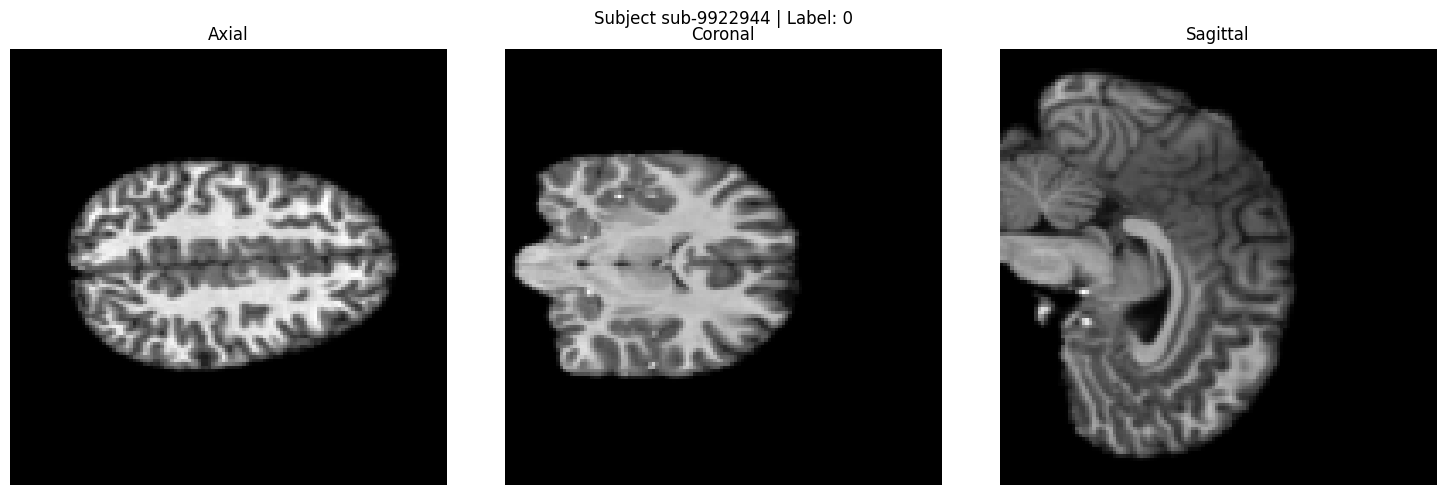

✓ Visualization saved to /kaggle/working/phase2/
🧠 Overlaying ROI atlas: aal


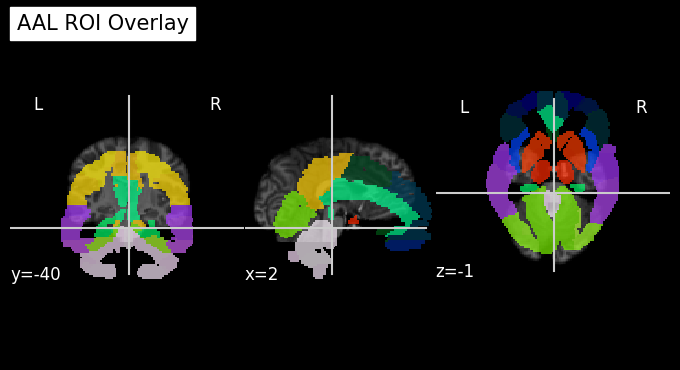

✓ ROI overlay saved to /kaggle/working/phase2/roi_overlay_unknown.png

🧠 Label 0 — Subject sub-9922944


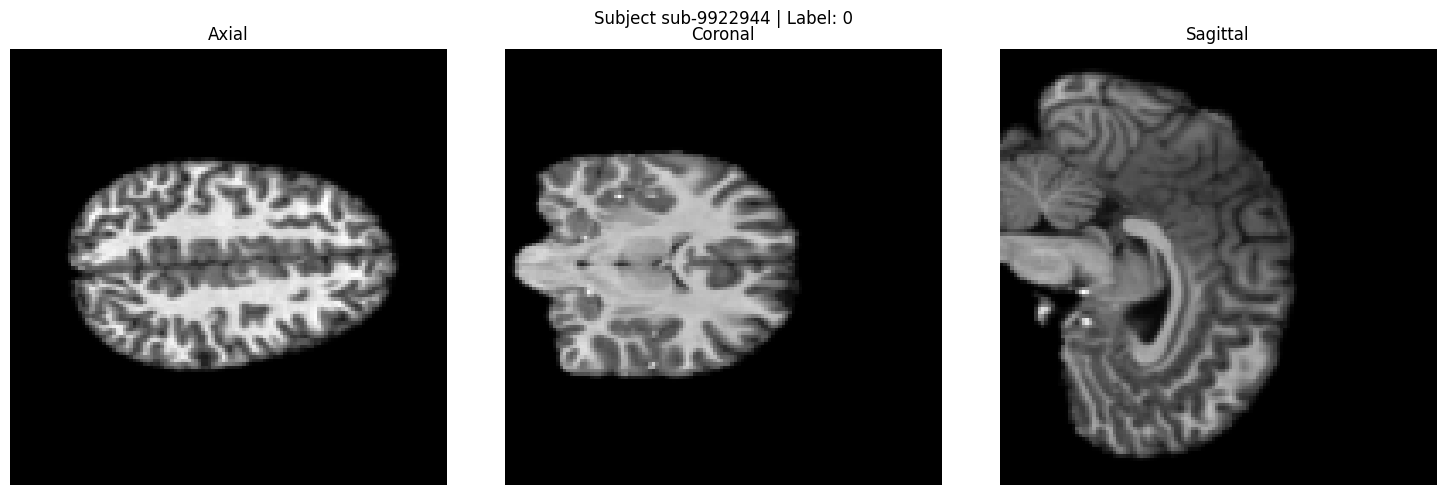

✓ Visualization saved to /kaggle/working/phase2/
🧠 Overlaying ROI atlas: aal


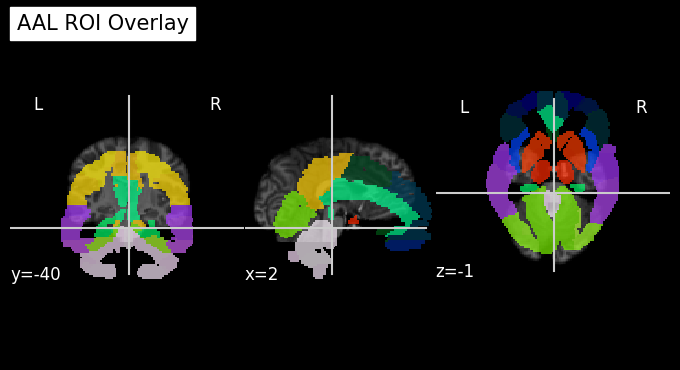

✓ ROI overlay saved to /kaggle/working/phase2/roi_overlay_sub-9922944.png

🧠 Label 1 — Subject sub-1623716


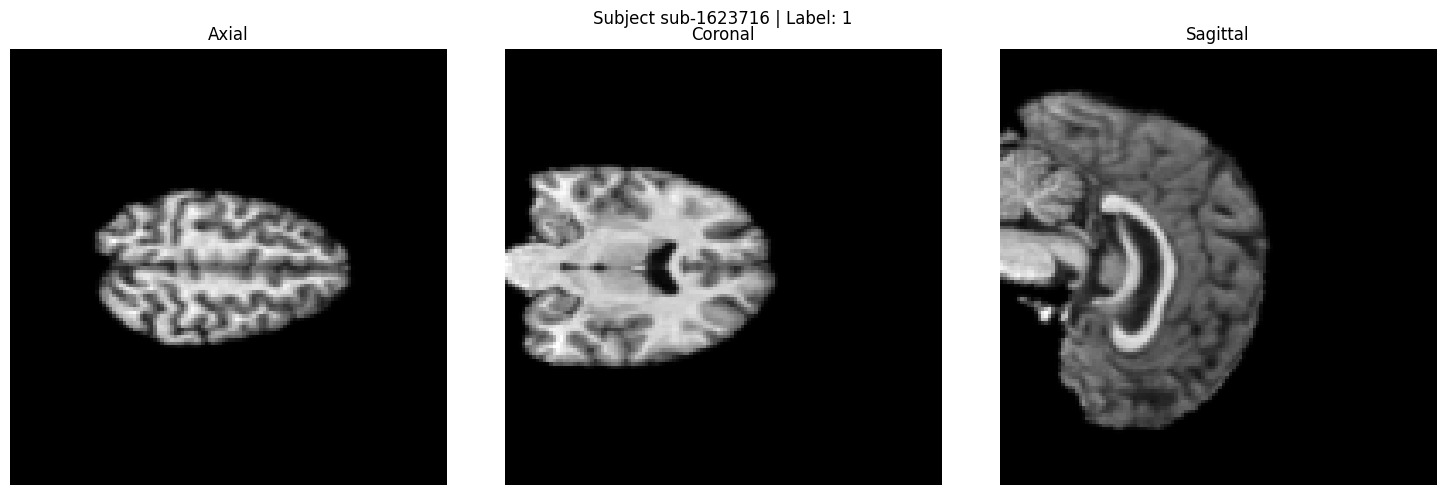

✓ Visualization saved to /kaggle/working/phase2/
🧠 Overlaying ROI atlas: aal


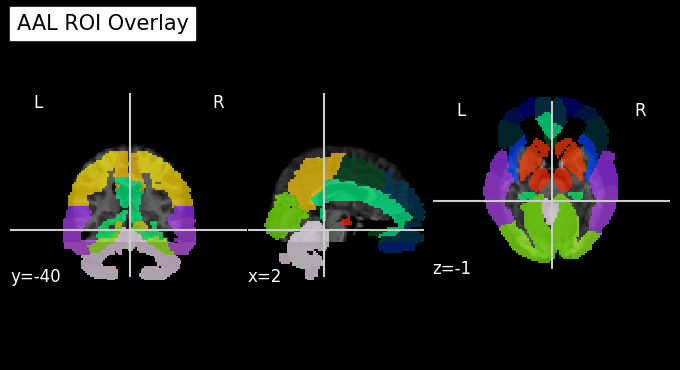

✓ ROI overlay saved to /kaggle/working/phase2/roi_overlay_sub-1623716.png

🧠 Label 2 — Subject sub-3310328


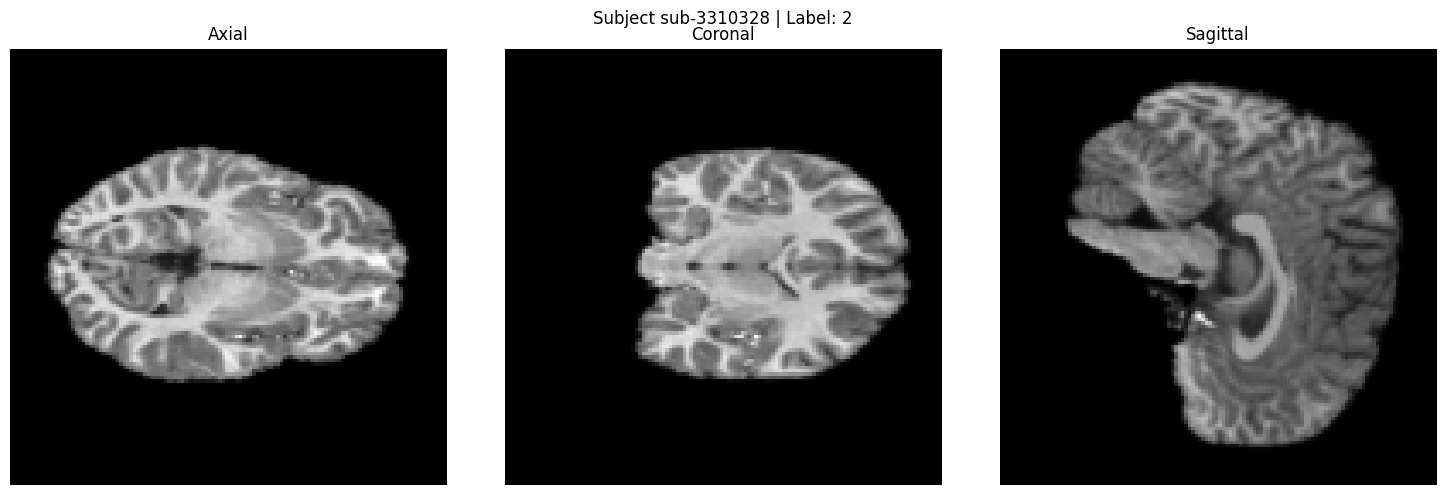

✓ Visualization saved to /kaggle/working/phase2/
🧠 Overlaying ROI atlas: aal


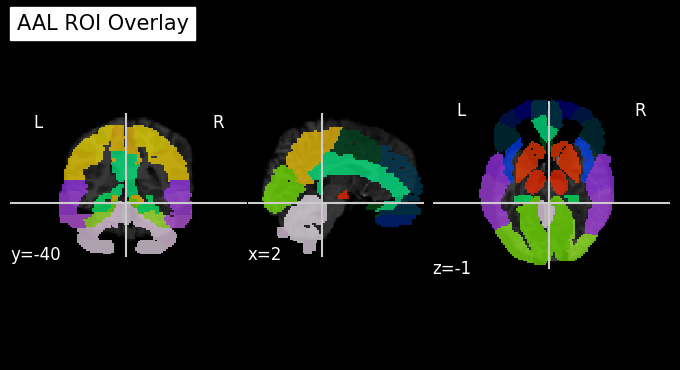

✓ ROI overlay saved to /kaggle/working/phase2/roi_overlay_sub-3310328.png

🧠 Label 3 — Subject sub-1019436


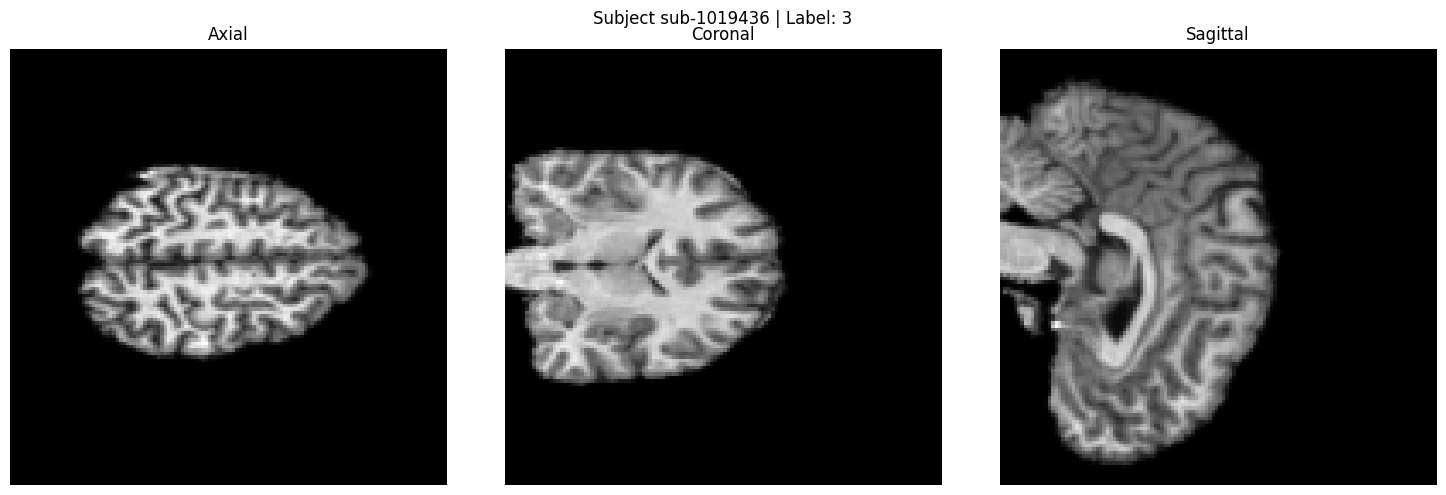

✓ Visualization saved to /kaggle/working/phase2/
🧠 Overlaying ROI atlas: aal


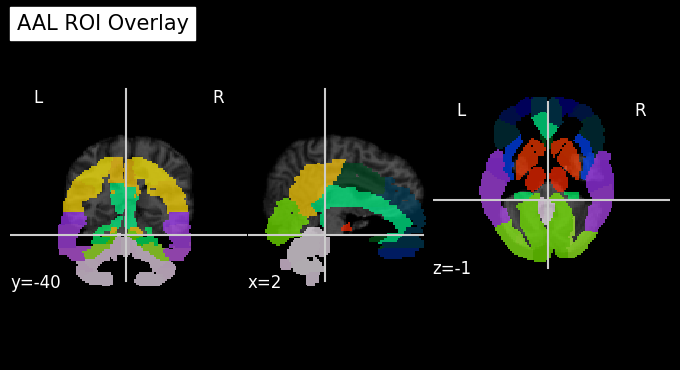

✓ ROI overlay saved to /kaggle/working/phase2/roi_overlay_sub-1019436.png
⚙️ Creating stratified splits (seed=42)

📊 Original Label Distribution:
  0: 264
  1: 98
  2: 8
  3: 53

🎯 Target count per label: 264

✅ Balanced Label Distribution:
  0: 264
  1: 264
  2: 264
  3: 264
✅ train/val/test splits saved
🔍 Total rows: 1056
🔍 Unique subject IDs: 423

🔁 Top repeated subjects:
subject
sub-3286474    42
sub-2876903    40
sub-8387093    32
sub-10005      32
sub-2074737    30
Name: count, dtype: int64
✅ Subject IDs updated and saved.
✅ Final unique subject count: 1056

📦 Dataset Splits Summary
Train set: 1056 samples
label
0    264
1    264
2    264
3    264
Name: count, dtype: int64

Validation set: 91 samples
label
0    57
1    21
2     2
3    11
Name: count, dtype: int64

Test set: 91 samples
label
0    57
1    21
2     2
3    11
Name: count, dtype: int64

📊 Age Statistics: [skipped — column not found]

📊 Gender Distribution: [skipped — column not found]

📊 IQ Statistics: [skipped — colu

In [40]:
# ============================================================
# PHASE 2 EXECUTION
# ============================================================

df = summarize_subject_index()

# ✅ FIXED: assign enriched result back to df
df = enrich_with_phenotypic_data(df, base_path)

# ✅ Drop age if it's causing issues
if 'age' in df.columns:
    df = df.drop(columns=['age'])

# ✅ Visualize one subject and overlay ROI
visualize_brain_scan(df.iloc[0])
sample_scan = load_brain_scan(df.iloc[0])
overlay_roi_on_scan(sample_scan, atlas='aal')

# 🔍 Visualize one sample scan per label with ROI overlay
for label in sorted(df['label'].unique()):
    sample = df[df['label'] == label].iloc[0]
    print(f"\n🧠 Label {label} — Subject {sample['subject']}")
    visualize_brain_scan(sample)
    scan_img = load_brain_scan(sample)
    overlay_roi_on_scan(scan_img, atlas='aal', subject_id=sample['subject'])  # ✅ Pass subject_id here

# ✅ Create splits and balance training set
train_df, val_df, test_df = create_splits(df)

# ✅ Ensure subject IDs are unique and updated for fusion
verify_and_update_subject_ids("/kaggle/working/phase2/train_subjects.csv")

print_split_summary(train_df, val_df, test_df)

# 📊 Show dataset statistics
show_dataset_statistics(train_df)

# zipping phase2
zip_folder("/kaggle/working/phase2")

In [148]:
print("🧾 All columns in phenotypic_df:")
print(phenotypic_df.columns.tolist())


🧾 All columns in phenotypic_df:
['scandir_id', 'site', 'gender', 'age', 'handedness', 'dx', 'secondary_dx', 'adhd_measure', 'adhd_index', 'inattentive', 'hyper/impulsive', 'iq_measure', 'verbal_iq', 'performance_iq', 'full2_iq', 'full4_iq', 'med_status', 'qc_rest_1', 'qc_rest_2', 'qc_rest_3', 'qc_rest_4', 'qc_anatomical_1', 'qc_anatomical_2', 'source_file', 'id', 'site_name']


In [22]:
import pandas as pd
# Load the CSV 
df = pd.read_csv("/kaggle/working/phase2/train_subjects.csv")
# Count unique subjects 
num_unique_subjects = df['subject'].astype(str).nunique() 
print(f"✅ Number of unique subjects: {num_unique_subjects}")

✅ Number of unique subjects: 1056


🧠 Short Answer:
Yes, if your augmented copies reuse the same subject_id, they will be mistakenly considered completed and skipped by resume logic.

🔍 Why This Happens
Your resume logic filters subjects using:

python
df["subject_id"] = df["subject"].astype(str).str.replace("sub-", "")
df = df[~df["subject_id"].isin(completed)]
So if your augmented data includes multiple rows with the same subject_id (e.g., "00123"), only the first processed copy will be marked as completed. All others will be skipped — even if they’re distinct due to augmentation.

✅ How to Fix It
You need to ensure that each augmented copy has a unique subject ID. Here are two options:

Option 1: Append an augmentation suffix
python
subject_id = str(row['subject']).replace("sub-", "")
aug_suffix = row.get("augmentation_id", "")  # e.g., "_flip", "_noise", "_v2"
subject_id = f"{subject_id}{aug_suffix}"
This way:

"00123_flip" and "00123_noise" are treated as distinct

Resume logic works correctly

You avoid skipping valid augmented samples

Option 2: Use a unique hash or index
If you don’t have a suffix column, generate a unique ID per row:

python
subject_id = f"{row['subject']}_{row.name}"
🧪 How to Confirm
After updating your subject ID logic:

Rerun a chunk with augmented data

Check that all rows are processed

Verify that completed_subjects.txt contains unique IDs for each augmented copy

# Temperary, Please Delete

In [ ]:
checkpoints_dir = "/kaggle/working/checkpoints"
progress_file = os.path.join(checkpoints_dir, "completed_subjects.txt")

if os.path.exists(progress_file):
    print("🧹 Removing old progress file and clearing checkpoints directory for a fresh run")
    shutil.rmtree(checkpoints_dir)  # Deletes the entire directory and its contents

In [ ]:
import shutil
checkpoints_dir = "/kaggle/working/checkpoints"

# Remove the entire directory if it exists
if os.path.exists(checkpoints_dir):
    print("🧹 Removing entire checkpoints directory for a fresh run")
    shutil.rmtree(checkpoints_dir)

# Recreate the empty directory
os.makedirs(checkpoints_dir, exist_ok=True)

In [ ]:
!ls -R /kaggle/working

# PHASE 3A: Extract histogram, texture, deep features

In [50]:
"""===========================================================
🧠 PHASE 3: FEATURE EXTRACTION (MRI)
==========================================================="""
# ============================================================
# CONFIGURATION
# ============================================================

PHASE3A_DIR = "/kaggle/working/phase3A"


CHECKPOINT_DIR = "/kaggle/working/checkpoints"
INPUT_CHECKPOINT_DIR = "/kaggle/input/phase3-checkpoints"   # used if you reattach saved dataset
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

RESUME = True      # ✅ Enable resume mode
SAVE_INTERVAL = 10  # Save progress after every 10 subjects
SCAN_TYPE = "normalized_resampled_128"  # Use this scan version

In [51]:
# ============================================================
# UTILS
# ============================================================

def load_completed_subjects():
    """Load list of already processed subjects (for resume)."""
    completed = set()

    # Load from Kaggle input dataset if exists
    input_log = os.path.join(INPUT_CHECKPOINT_DIR, "completed_subjects.txt")
    if os.path.exists(input_log):
        with open(input_log) as f:
            completed.update(f.read().splitlines())

    # Load from local working dir if exists
    local_log = os.path.join(CHECKPOINT_DIR, "completed_subjects.txt")
    if os.path.exists(local_log):
        with open(local_log) as f:
            completed.update(f.read().splitlines())

    print(f"🔄 Resuming from {len(completed)} completed subjects.")
    return completed

In [52]:
def save_completed_subject(subject_id):
    """Append subject to completed log (both local and checkpoint)."""
    with open(os.path.join(CHECKPOINT_DIR, "completed_subjects.txt"), "a") as f:
        f.write(f"{subject_id}\n")

In [53]:
def save_checkpoint(features, feature_name, counter, split='train', base_dir='/kaggle/working/checkpoints'):
    save_dir = os.path.join(base_dir, split)
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_path = os.path.join(save_dir, f"{feature_name}_partial_{counter}.pkl")
    joblib.dump(features, checkpoint_path)
    print(f"💾 Saved checkpoint → {checkpoint_path}")


In [54]:
def load_brain_image(path):
    """Load MRI NIfTI file safely."""
    try:
        img = nib.load(path)
        return img.get_fdata()
    except Exception as e:
        print(f"❌ Failed to load {path}: {e}")
        return None


In [55]:
# ============================================================
# FEATURE EXTRACTION FUNCTIONS
# ============================================================

def extract_histogram_features(image_data, bins=50):
    """Compute global voxel intensity histogram."""
    hist, _ = np.histogram(image_data[image_data > 0], bins=bins, density=True)
    return hist


In [56]:
def extract_texture_features(image_data):
    """Compute GLCM texture features from one slice (for simplicity)."""
    mid_slice = image_data.shape[2] // 2
    slice_data = (image_data[:, :, mid_slice] * 255 / np.max(image_data)).astype(np.uint8)
    glcm = graycomatrix(slice_data, [1], [0], symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    return np.array([contrast, homogeneity, energy, correlation])

In [57]:
def extract_deep_features(image_data, model, transform):
    """Use pretrained CNN (ResNet18) on central slices."""
    mid_slice = image_data.shape[2] // 2
    slice_img = image_data[:, :, mid_slice]
    slice_img = np.stack([slice_img]*3, axis=-1)
    slice_img = (slice_img - slice_img.min()) / (slice_img.max() - slice_img.min())
    slice_img = (slice_img * 255).astype(np.uint8)
    slice_tensor = transform(slice_img).unsqueeze(0)

    with torch.no_grad():
        features = model(slice_tensor).squeeze().numpy()
    return features


In [58]:
# ============================================================
# MAIN PIPELINE (UPDATED)
# ============================================================

def process_dataset(csv_path, split='train', output_root='/kaggle/working/checkpoints', resume=RESUME):
    """Main function to extract features and save incrementally."""
    output_dir = os.path.join(output_root, split)
    os.makedirs(output_dir, exist_ok=True)
    print(f"📂 Processing {split} split → saving to {output_dir}")

    df = pd.read_csv(csv_path)
    print(f"📂 Loaded {len(df)} subjects from {csv_path}")

    # Load resume list
    completed_subjects = load_completed_subjects() if resume else set()

    # Initialize feature holders
    hist_features, texture_features, deep_features, meta_data = [], [], [], []

    # Prepare deep feature extractor
    resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model = nn.Sequential(*list(resnet.children())[:-1])
    model.eval()
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    counter = 0
    start_time = time.time()

    for _, row in tqdm(df.iterrows(), total=len(df)):
        subject_id = row['subject']
        if subject_id in completed_subjects:
            continue

        anat_files = eval(row['anat_files'])
        matching = [f for f in anat_files if SCAN_TYPE in f]
        if not matching:
            continue

        path = os.path.join(row['path'], matching[0])
        image_data = load_brain_image(path)
        if image_data is None:
            continue

        # ---------------------------
        # Feature extraction
        # ---------------------------
        hist = extract_histogram_features(image_data)

        try:
            tex = extract_texture_features(image_data)
        except Exception as e:
            print(f"⚠️ Texture extraction failed for {subject_id}: {e}")
            tex = np.array([])

        deep = extract_deep_features(image_data, model, transform)

        # Append to storage
        hist_features.append(hist)
        texture_features.append(tex)
        deep_features.append(deep)
        meta_data.append([subject_id, row['label'], row['site']])

        counter += 1
        save_completed_subject(subject_id)

        # ---------------------------
        # Periodic checkpoint saving
        # ---------------------------
        if counter % SAVE_INTERVAL == 0:
            save_checkpoint(hist_features, "hist", counter, split)
            save_checkpoint(texture_features, "texture", counter, split)
            save_checkpoint(deep_features, "deep", counter, split)

            pd.DataFrame(meta_data, columns=['subject', 'label', 'site']).to_csv(
                os.path.join(output_dir, f"metadata_partial_{counter}.csv"), index=False)
            print(f"💾 Saved checkpoint → {counter} subjects")

    # ---------------------------
    # Final save to phase3 directory
    # ---------------------------
    PHASE3_DIR = "/kaggle/working/phase3A"


    final_dir = os.path.join(PHASE3A_DIR, split)
    os.makedirs(final_dir, exist_ok=True)
    
    joblib.dump(hist_features, os.path.join(final_dir, "hist_final.pkl"))
    joblib.dump(texture_features, os.path.join(final_dir, "texture_final.pkl"))
    joblib.dump(deep_features, os.path.join(final_dir, "deep_final.pkl"))
    pd.DataFrame(meta_data, columns=['subject', 'label', 'site']).to_csv(
        os.path.join(final_dir, "metadata.csv"), index=False)

    # ---------------------------
    # Combine all extracted data
    # ---------------------------
    try:
        hist_arr = np.vstack([np.ravel(h) for h in hist_features]) if hist_features else np.empty((0,))
        texture_arr = np.vstack([np.ravel(t) for t in texture_features]) if texture_features else np.empty((0,))
        deep_arr = np.vstack([np.ravel(d) for d in deep_features]) if deep_features else np.empty((0,))
    except Exception as e:
        print(f"⚠️ Could not combine some features: {e}")
        hist_arr, texture_arr, deep_arr = np.empty((0,)), np.empty((0,)), np.empty((0,))

    metadata_df = pd.DataFrame(meta_data, columns=['subject', 'label', 'site'])

    # ---------------------------
    # Summary report
    # ---------------------------
    print(f"\n📊 Combined Feature Summary for {split}")
    print(f"  Histogram matrix : {hist_arr.shape}")
    print(f"  Texture matrix   : {texture_arr.shape}")
    print(f"  Deep matrix      : {deep_arr.shape}")
    print(f"  Metadata count   : {len(metadata_df)}")

    elapsed = (time.time() - start_time) / 60
    print(f"\n🎯 Completed {counter} subjects in {elapsed:.2f} min")
    print(f"✅ Final features saved in {output_dir}")


In [59]:
# ============================================================
# EXECUTION EXAMPLE — PHASE 3 (KAGGLE STABLE VERSION)
# ============================================================

if __name__ == "__main__":

    # Optional: reset progress tracking if subject list changed
    progress_file = "/kaggle/working/checkpoints/completed_subjects.txt"
    if os.path.exists(progress_file):
        done = open(progress_file).read().strip().splitlines()
        if len(done) >= 1134:  # 378 x 3 balanced subjects
            print(f"🧹 Removing old progress file ({len(done)} subjects) for a fresh run")
            os.remove(progress_file)
    else:
        print("📂 No existing progress file found — starting fresh.")

    print("="*70)
    print("🧠 PHASE 3A: FEATURE EXTRACTION — Classical Features")
    print("="*70)

    # ============================================================
    # STEP 1 — LOAD SPLITS FROM PHASE 2 OR BACKUP
    # ============================================================
    import os
    import pandas as pd
    
    checkpoints_dir = "/kaggle/working/checkpoints"
    phase2_dir = "/kaggle/working/phase2"
    backup_dir = "/kaggle/input/phase2/phase2"
    
    os.makedirs(phase2_dir, exist_ok=True)
    os.makedirs(checkpoints_dir, exist_ok=True)
    
    def load_split(split_name):
        primary_path = os.path.join(phase2_dir, f"{split_name}_subjects.csv")
        backup_path = os.path.join(backup_dir, f"{split_name}_subjects.csv")
        try:
            return pd.read_csv(primary_path)
        except FileNotFoundError:
            print(f"⚠️ {primary_path} not found. Loading from backup: {backup_path}")
            return pd.read_csv(backup_path)
    
    train_df = load_split("train")
    val_df = load_split("val")
    test_df = load_split("test")
    
    print(f"✅ Loaded train ({len(train_df)}), val ({len(val_df)}), test ({len(test_df)}) splits")
    
    # ============================================================
    # STEP 2 — RUN FEATURE EXTRACTION
    # ============================================================
    for split in ['train', 'val', 'test']:
        csv_path = os.path.join(phase2_dir, f"{split}_subjects.csv")
        if not os.path.exists(csv_path):
            csv_path = os.path.join(backup_dir, f"{split}_subjects.csv")
        if os.path.exists(csv_path):
            print(f"\n🚀 Starting feature extraction for {split} split")
            process_dataset(csv_path, split=split)
        else:
            print(f"⚠️ Missing {csv_path}, skipping this split.")
    
    print("\n✓ Phase 3A completed successfully 🎉")
    print("="*70)


    # ============================================================
    # LOGGING SUMMARY
    # ============================================================
    print("\n📦 Checkpoints saved in:", checkpoints_dir)
    print("🧠 Feature extraction complete for all splits.")




📂 No existing progress file found — starting fresh.
🧠 PHASE 3A: FEATURE EXTRACTION — Classical Features
✅ Loaded train (1056), val (91), test (91) splits

🚀 Starting feature extraction for train split
📂 Processing train split → saving to /kaggle/working/checkpoints/train
📂 Loaded 1056 subjects from /kaggle/working/phase2/train_subjects.csv
🔄 Resuming from 0 completed subjects.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 65.5MB/s]
  1%|          | 11/1056 [00:02<03:23,  5.14it/s]

💾 Saved checkpoint → /kaggle/working/checkpoints/train/hist_partial_10.pkl
💾 Saved checkpoint → /kaggle/working/checkpoints/train/texture_partial_10.pkl
💾 Saved checkpoint → /kaggle/working/checkpoints/train/deep_partial_10.pkl
💾 Saved checkpoint → 10 subjects


  2%|▏         | 21/1056 [00:04<03:15,  5.30it/s]

💾 Saved checkpoint → /kaggle/working/checkpoints/train/hist_partial_20.pkl
💾 Saved checkpoint → /kaggle/working/checkpoints/train/texture_partial_20.pkl
💾 Saved checkpoint → /kaggle/working/checkpoints/train/deep_partial_20.pkl
💾 Saved checkpoint → 20 subjects


...

💾 Saved checkpoint → /kaggle/working/checkpoints/test/hist_partial_80.pkl
💾 Saved checkpoint → /kaggle/working/checkpoints/test/texture_partial_80.pkl
💾 Saved checkpoint → /kaggle/working/checkpoints/test/deep_partial_80.pkl
💾 Saved checkpoint → 80 subjects


 99%|█████████▉| 90/91 [00:20<00:00,  4.63it/s]

💾 Saved checkpoint → /kaggle/working/checkpoints/test/hist_partial_90.pkl
💾 Saved checkpoint → /kaggle/working/checkpoints/test/texture_partial_90.pkl
💾 Saved checkpoint → /kaggle/working/checkpoints/test/deep_partial_90.pkl
💾 Saved checkpoint → 90 subjects


100%|██████████| 91/91 [00:20<00:00,  4.48it/s]


📊 Combined Feature Summary for test
  Histogram matrix : (91, 50)
  Texture matrix   : (91, 4)
  Deep matrix      : (91, 512)
  Metadata count   : 91

🎯 Completed 91 subjects in 0.34 min
✅ Final features saved in /kaggle/working/checkpoints/test

✓ Phase 3A completed successfully 🎉

📦 Checkpoints saved in: /kaggle/working/checkpoints
🧠 Feature extraction complete for all splits.


In [73]:
zip_folder("/kaggle/working/phase3A")
delete_folder("/kaggle/working/checkpoints")


✅ Zipped phase3A → /kaggle/working/phase3A.zip
🧹 Deleted folder → /kaggle/working/checkpoints


In [2]:
import os

split = "train"  # Change to 'val' or 'test' if needed
split_dir = f"/kaggle/working/phase3B/{split}"

# ✅ Delete completed_subjects.txt
completed_path = os.path.join(split_dir, "completed_subjects.txt")
if os.path.exists(completed_path):
    #os.remove(completed_path)
    print(f"🗑️ Deleted: {completed_path}")
"""


# ✅ Delete errors.txt
errors_path = os.path.join(split_dir, "errors.txt")
if os.path.exists(errors_path):
    os.remove(errors_path)
    print(f"🗑️ Deleted: {errors_path}")

# ✅ Delete radiomics_features.csv
final_path = os.path.join(split_dir, "radiomics_features.csv")
if os.path.exists(final_path):
    os.remove(final_path)
    print(f"🗑️ Deleted: {final_path}")

# ✅ Delete all radiomics_partial_*.csv files
for fname in os.listdir(split_dir):
    if fname.startswith("radiomics_partial_") and fname.endswith(".csv"):
        fpath = os.path.join(split_dir, fname)
        os.remove(fpath)
        print(f"🗑️ Deleted: {fpath}")
"""

🗑️ Deleted: /kaggle/working/phase3B/train/radiomics_partial_1.csv
🗑️ Deleted: /kaggle/working/phase3B/train/radiomics_partial_194.csv
🗑️ Deleted: /kaggle/working/phase3B/train/radiomics_partial_200.csv
🗑️ Deleted: /kaggle/working/phase3B/train/radiomics_partial_300.csv
🗑️ Deleted: /kaggle/working/phase3B/train/radiomics_partial_49.csv


# Phase 3B: Radiomics Feature Extraction with PyRadiomics

In [2]:
import os, pandas as pd, numpy as np, nibabel as nib, ast
from radiomics import featureextractor
from joblib import Parallel, delayed
from tqdm import tqdm
from collections import Counter


# Directories
PHASE3B_DIR = "/kaggle/working/phase3B"
MASK_DIR = os.path.join(PHASE3B_DIR, "masks")
CONFIG_PATH = os.path.join(PHASE3B_DIR, "radiomics_config.yaml")
SCAN_TYPE = "normalized_resampled_128"
NUM_WORKERS = 16
BATCH_SIZE = 500




In [3]:
def create_radiomics_config():
    config = """
setting:
  binWidth: 25
  resampledPixelSpacing: [1, 1, 1]
  interpolator: 'sitkBSpline'
  normalize: True
  removeOutliers: 3
  force2D: False

imageType:
  Original: {}

featureClass:
  firstorder: []
  glcm: []
  glrlm: []
  glszm: []
  ngtdm: []
  gldm: []
  shape: []
"""
    os.makedirs(PHASE3B_DIR, exist_ok=True)
    with open(CONFIG_PATH, "w") as f:
        f.write(config)


In [4]:
def load_completed_subjects(split):
    path = f"/kaggle/working/phase3B/{split}/completed_subjects.txt"
    if not os.path.exists(path):
        return set()
    try:
        return set(pd.read_csv(path, header=None)[0].dropna().astype(str))
    except pd.errors.EmptyDataError:
        return set()


In [5]:
# Radiomics Setup
from radiomics import featureextractor

def get_radiomics_extractor(config_path=CONFIG_PATH):
    """Initialize PyRadiomics extractor."""
    extractor = featureextractor.RadiomicsFeatureExtractor(config_path)
    return extractor


In [6]:
import os
import nibabel as nib
import numpy as np

def generate_mask(image_path, threshold=0, subject_id=None):
    try:
        img = nib.load(image_path)
    except Exception as e:
        return None

    os.makedirs(MASK_DIR, exist_ok=True)
    if subject_id is None:
        subject_id = os.path.basename(image_path).split("_")[0]

    mask_path = os.path.join(MASK_DIR, f"{subject_id}_mask.nii.gz")
    if os.path.exists(mask_path):
        return mask_path

    data = img.get_fdata()
    mask = (data > threshold).astype(np.uint8)
    mask_img = nib.Nifti1Image(mask, img.affine)
    nib.save(mask_img, mask_path)
    return mask_path





In [7]:
def extract_radiomics_features(image_path, mask_path, extractor):
    result = extractor.execute(image_path, mask_path)
    return {k: v for k, v in result.items() if k.startswith("original")}


In [8]:
def extract_features(row, extractor, split):
    subject_id = str(row['subject']).replace("sub-", "")
    completed = load_completed_subjects(split)
    if subject_id in completed:
        return None

    try:
        anat_files = ast.literal_eval(row['anat_files'])
    except Exception:
        log_error(subject_id, split, "Invalid anat_files format")
        return None

    matching = [f for f in anat_files if SCAN_TYPE in f]
    if not matching:
        log_error(subject_id, split, "No matching scan")
        return None

    image_path = os.path.join(row['path'], matching[0])
    try:
        mask_path = generate_mask(image_path, subject_id=subject_id)
        if mask_path is None:
            log_error(subject_id, split, "Mask generation failed")
            return None

        features = extract_radiomics_features(image_path, mask_path, extractor)
        features.update({
            'subject': subject_id,
            'label': row['label'],
            'site': row['site']
        })

        print(f"✅ Processed subject: {subject_id}")
        return features

    except Exception as e:
        log_error(subject_id, split, str(e))
        return None


In [9]:
def log_error(subject_id, split, message):
    error_path = os.path.join(PHASE3B_DIR, split, "errors.txt")
    with open(error_path, "a") as f:
        f.write(f"{subject_id}: {message}\n")


In [10]:
import os
def save_completed_subjects(subject_ids, split):
    """Save all completed subjects at once (robust and atomic)."""
    path = f"/kaggle/working/phase3B/{split}/completed_subjects.txt"
    os.makedirs(os.path.dirname(path), exist_ok=True)

    # Ensure all subject IDs are strings
    subject_ids = {str(sid) for sid in subject_ids}
    existing = {str(sid) for sid in load_completed_subjects(split)}
    all_subjects = existing.union(subject_ids)

    with open(path, "w") as f:
        for subject_id in sorted(all_subjects):
            f.write(f"{subject_id}\n")

In [11]:
from tqdm import tqdm
from collections import Counter
from joblib import Parallel, delayed
import pandas as pd
import os
from radiomics import featureextractor

def process_radiomics_dataset(csv_path, split='train', num_workers=8, start=0, stop=None):
    print(f"\n🚀 Extracting radiomics for {split} split using {num_workers} workers")
    output_dir = os.path.join(PHASE3B_DIR, split)
    os.makedirs(output_dir, exist_ok=True)

    df = pd.read_csv(csv_path)
    if stop is None:
        stop = len(df)
    df = df.iloc[start:stop]

    # ✅ Resume logic: filter out completed subjects before processing
    completed = load_completed_subjects(split)
    df["subject_id"] = df["subject"].astype(str).str.replace("sub-", "")
    df = df[~df["subject_id"].isin(completed)]

    create_radiomics_config()
    extractor = featureextractor.RadiomicsFeatureExtractor(CONFIG_PATH)

    label_counter = Counter()
    batch_features = []
    saved_count = 0
    all_batches = []
    completed_batch = []

    print(f"📂 Using subject data from: {csv_path}")
    print(f"📋 Processing subjects {start} to {stop} (after filtering: {len(df)})")

    # ✅ Parallel processing
    results = Parallel(n_jobs=num_workers)(
        delayed(extract_features)(row, extractor, split)
        for _, row in tqdm(df.iterrows(), total=len(df), desc="✅ Processing", unit="subject")
    )

    try:
        for result in results:
            if result is not None:
                batch_features.append(result)
                label_counter[result["label"]] += 1
                completed_batch.append(result["subject"])

            if len(batch_features) >= BATCH_SIZE:
                saved_count += len(batch_features)
                temp_path = os.path.join(output_dir, f"radiomics_partial_{saved_count}.csv")
                pd.DataFrame(batch_features).to_csv(temp_path, index=False)
                all_batches.append(temp_path)
                save_completed_subjects(completed_batch, split)
                batch_features = []
                completed_batch = []

    finally:
        # ✅ Always save remaining batch
        if batch_features:
            saved_count += len(batch_features)
            temp_path = os.path.join(output_dir, f"radiomics_partial_{saved_count}.csv")
            pd.DataFrame(batch_features).to_csv(temp_path, index=False)
            all_batches.append(temp_path)
            save_completed_subjects(completed_batch, split)

        # ✅ Merge all partials with existing features
        partial_paths = sorted([
            os.path.join(output_dir, f) for f in os.listdir(output_dir)
            if f.startswith("radiomics_partial_") and f.endswith(".csv")
        ])
        final_path = os.path.join(output_dir, "radiomics_features.csv")

        if partial_paths:
            new_df = pd.concat([pd.read_csv(p) for p in partial_paths], ignore_index=True)

            if os.path.exists(final_path):
                existing_df = pd.read_csv(final_path)
                merged_df = pd.concat([existing_df, new_df], ignore_index=True)
                merged_df = merged_df.drop_duplicates(subset=["subject"], keep="last")
            else:
                merged_df = new_df

            merged_df.to_csv(final_path, index=False)
            print(f"✅ Updated merged features → {final_path}")
            print("📊 Label distribution:", dict(label_counter))
        else:
            print("⚠️ No partials found — nothing was saved.")


In [12]:
def get_subject_file_path(phase_name, split):
    working_file = f"/kaggle/working/{phase_name}/{split}_subjects.csv"
    backup_file = f"/kaggle/input/phase1-2output/finalized_outputs{phase_name}/{split}_subjects.csv" if phase_name in ["phase1", "phase2"] else f"/kaggle/input/{phase_name}/{split}_subjects.csv"
    return working_file if os.path.exists(working_file) else backup_file


def run_mini_test(split="train", sample_size=20):
    source_path = get_subject_file_path("phase2", split)

    if not os.path.exists(source_path):
        print(f"⚠️ Missing {source_path}, cannot run mini test.")
        return

    df = pd.read_csv(source_path)
    test_batch = df.sample(n=sample_size, random_state=42)

    # Save test batch to working directory
    os.makedirs("/kaggle/working/phase2", exist_ok=True)
    test_path = f"/kaggle/working/phase2/{split}_test_batch.csv"
    test_batch.to_csv(test_path, index=False)

    # Run radiomics using correct split name
    process_radiomics_dataset(test_path, split=split)




In [ ]:
#run_mini_test("train")

#run_mini_test("val")

#run_mini_test("test")

In [108]:
#delete_folder("/kaggle/working/phase3B/train")

🧹 Deleted folder → /kaggle/working/phase3B/train


In [111]:
import pandas as pd

# Load the CSV
df = pd.read_csv("/kaggle/input/phase2/phase2/train_subjects.csv")

# Count unique subjects
num_unique_subjects = df['subject'].astype(str).nunique()

print(f"✅ Number of unique subjects: {num_unique_subjects}")


✅ Number of unique subjects: 1056


In [100]:
csv_path = "/kaggle/input/phase2/phase2/val_subjects.csv"
print("Val Set")
split = 'val'

process_radiomics_dataset(csv_path, split=split, num_workers=16, start=0, stop=91)


csv_path = "/kaggle/input/phase2/phase2/test_subjects.csv"
print("Test Set")
split = 'test'

process_radiomics_dataset(csv_path, split=split, num_workers=16, start=0, stop=91)

Val Set

🚀 Extracting radiomics for val split using 16 workers
📂 Using subject data from: /kaggle/input/phase2/phase2/val_subjects.csv
📋 Processing subjects 0 to 91 (after filtering: 91)


✅ Processing:  18%|█▊        | 16/91 [00:10<00:01, 47.05subject/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
✅ Processing:  35%|███▌      | 32/91 [03:16<07:06,  7.23s/subject]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, t

✅ Saved merged features → /kaggle/working/phase3B/val/radiomics_features.csv
📊 Label distribution: {0: 57, 1: 21, 3: 11, 2: 2}
Test Set

🚀 Extracting radiomics for test split using 16 workers
📂 Using subject data from: /kaggle/input/phase2/phase2/test_subjects.csv
📋 Processing subjects 0 to 91 (after filtering: 91)


✅ Processing:  35%|███▌      | 32/91 [01:23<02:33,  2.61s/subject]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calcu

✅ Saved merged features → /kaggle/working/phase3B/test/radiomics_features.csv
📊 Label distribution: {0: 57, 3: 11, 1: 21, 2: 2}


In [16]:
csv_path = "/kaggle/input/phase2/phase2/train_subjects.csv"
print("Train Set")
split = 'train'

process_radiomics_dataset(csv_path, split=split, num_workers=16, start=0, stop=1056)

Train Set

🚀 Extracting radiomics for train split using 16 workers
📂 Using subject data from: /kaggle/input/phase2/phase2/train_subjects.csv
📋 Processing subjects 0 to 1056 (after filtering: 156)


✅ Processing:   0%|          | 0/156 [00:00<?, ?subject/s]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
✅ Processing:  21%|██        | 32/156 [03:49<14:47,  7.16s/subject]GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefor

✅ Updated merged features → /kaggle/working/phase3B/train/radiomics_features.csv
📊 Label distribution: {2: 39, 3: 38, 0: 39, 1: 40}


In [28]:
zip_folder("/kaggle/working/phase3B")

✅ Zipped phase3B → /kaggle/working/phase3B.zip


In [31]:
import os

zip_path = "/kaggle/working/phase3B.zip"
print("✅ File exists:", os.path.exists(zip_path))
print("📦 File size (MB):", os.path.getsize(zip_path) / (1024 * 1024) if os.path.exists(zip_path) else "Not found")


✅ File exists: True
📦 File size (MB): 50.55982303619385


In [1]:
import os

# List all files in /kaggle/working
for file in os.listdir("/kaggle/working"):
    print("📁", file)

📁 phase1.zip
📁 state.db
📁 phase3A
📁 phase3B
📁 phase3A.zip
📁 phase2.zip
📁 history
📁 phase3B.zip
📁 phase2
📁 phase1
📁 .virtual_documents
📁 atlases
📁 models


In [19]:
import os
path = "/kaggle/working/phase3B/train/completed_subjects.txt"
#path="/kaggle/working/phase3B/train/radiomics_features.csv"
if os.path.exists(path):
    os.remove(path)


In [55]:
import shutil
"""
# Source and destination paths
source_path = "/kaggle/input/trainradiomic/radiomics_features(1).csv"
destination_path = "/kaggle/working/phase3B/train/radiomics_features.csv"

# Overwrite the destination file
shutil.copyfile(source_path, destination_path)

print(f"✅ Overwritten: {destination_path} with {source_path}")

"""



✅ Overwritten: /kaggle/working/phase3B/train/radiomics_features.csv with /kaggle/input/trainradiomic/radiomics_features(1).csv


In [ ]:

process_radiomics_dataset(csv_path, split='train', num_workers=16, start=180, stop=200)

In [ ]:
if __name__ == "__main__":
    print("="*70)
    print("🧠 PHASE 3B: Radiomics Feature Extraction Started")
    print("="*70)

    for split in ['train', 'val', 'test']:
        csv_path = get_subject_file_path("phase2", split)
        if os.path.exists(csv_path):
            print(f"📂 Using subject data from: {csv_path}")
            process_radiomics_dataset(csv_path, split)
        else:
            print(f"⚠️ Missing {csv_path}, skipping {split}")

In [ ]:
completed = load_completed_subjects("train")
print(f"📋 Subjects already marked as completed: {len(completed)}")


In [ ]:
df = pd.read_csv("/kaggle/input/phase1-2/finalized_outputs/phase2/train_subjects.csv")
print(f"📄 Total subjects in training set: {len(df)}")


In [17]:
import pandas as pd

for split in ['train', 'val', 'test']:
    path = f"/kaggle/working/phase3B/{split}/radiomics_features.csv"
    df = pd.read_csv(path)
    print(f"\n📊 {split.upper()} LABEL DISTRIBUTION:")
    print(df['label'].value_counts().sort_index())


📊 TRAIN LABEL DISTRIBUTION:
label
0    264
1    264
2    264
3    264
Name: count, dtype: int64

📊 VAL LABEL DISTRIBUTION:
label
0    57
1    21
2     2
3    11
Name: count, dtype: int64

📊 TEST LABEL DISTRIBUTION:
label
0    57
1    21
2     2
3    11
Name: count, dtype: int64


In [ ]:
df = pd.read_csv("/kaggle/working/phase3B/train/radiomics_features.csv")
print("🧬 Feature columns:", df.columns.tolist()[0:10])  # Show first 10
print("🔢 Total features:", len(df.columns) - 3)  # Exclude subject, label, site


In [18]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

2025-11-07 13:04:46.155008: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762520686.447852      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762520686.540095      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [20]:
# 1️⃣ Path Resolver

"""
def resolve_path(phase, split=None, filename=None):
    
    #Resolves the correct path for a given phase, split, and filename.
    #Prioritizes /kaggle/working/, falls back to /kaggle/input/ if needed.
    
    base_working = f"/kaggle/working/{phase}"
    base_backup = {
        "phase1": "/kaggle/input/phase1-2-output/finalized_outputs/phase1",
        "phase2": "/kaggle/input/phase1-2-output/finalized_outputs/phase2"
        
        
    }
    #"phase3a": "/kaggle/input/phase3a/finalized_outputs/phase3A",
    #"phase3b": "/kaggle/input/phase3b/phase3B"
    if split:
        working_path = os.path.join(base_working, split, filename)
        backup_path = os.path.join(base_backup[phase], split, filename)
    else:
        working_path = os.path.join(base_working, filename)
        backup_path = os.path.join(base_backup[phase], filename)

    return working_path if os.path.exists(working_path) else backup_path
"""

def resolve_path(phase, split=None, filename=None, use_backup=False):
    """
    Resolves the correct path for a given phase, split, and filename.
    If use_backup=False, only checks /kaggle/working/.
    """
    base_working = f"/kaggle/working/{phase}"
    base_backup = {
        "phase1": "/kaggle/input/phase1/phase1",
        "phase2": "/kaggle/input/phase2/phase2",
        "phase3A": "/kaggle/input/phase3A/finalized_outputs/phase3A",  # ✅ match key to actual folder name
        "phase3b": "/kaggle/input/phase3B"
    }

    if split:
        working_path = os.path.join(base_working, split, filename)
        backup_path = os.path.join(base_backup[phase], split, filename)
    else:
        working_path = os.path.join(base_working, filename)
        backup_path = os.path.join(base_backup[phase], filename)

    if use_backup:
        return working_path if os.path.exists(working_path) else backup_path
    else:
        if not os.path.exists(working_path):
            raise FileNotFoundError(f"Missing file: {working_path}")
        return working_path



In [21]:
# 2️⃣ Plotting Function

def plot_2d(reduced, labels, title, save_path=None):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette="tab10", s=50)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"📁 Saved plot to {save_path}")
    plt.show()


In [22]:
# 3️⃣ Dimensionality Reduction Methods
def run_pca(X, y, title, save_path=None):
    reduced = PCA(n_components=2).fit_transform(X)
    plot_2d(reduced, y, title, save_path=save_path)


def run_tsne(X, y, title, save_path=None):
    reduced = TSNE(n_components=2, random_state=42).fit_transform(X)
    plot_2d(reduced, y, title, save_path=save_path)





In [71]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def run_dimensionality_reduction(split="test"):
    phenotypic_cols = [
        'handedness', 'dx', 'secondary_dx', 'adhd_measure', 'adhd_index',
        'inattentive', 'hyper/impulsive', 'iq_measure', 'verbal_iq',
        'performance_iq', 'full2_iq', 'full4_iq', 'med_status',
        'qc_rest_1', 'qc_rest_2', 'qc_rest_3', 'qc_rest_4'
    ]

    # Load metadata
    #metadata_path = resolve_path("phase3A", split, "metadata.csv")
    metadata_path = resolve_path("phase3A", split, "metadata.csv", use_backup=False)
    metadata_df = pd.read_csv(metadata_path)
    metadata_df.columns = [col.strip().lower().replace(" ", "_") for col in metadata_df.columns]
    if "subject" in metadata_df.columns:
        metadata_df = metadata_df.rename(columns={"subject": "id"})
    elif "scandir_id" in metadata_df.columns:
        metadata_df = metadata_df.rename(columns={"scandir_id": "id"})
    else:
        raise KeyError("Metadata file missing subject ID column ('subject' or 'scandir_id')")
    metadata_df["id"] = metadata_df["id"].astype(str)

    # Load phenotypic data from all sites
    phenotypic_paths = [
        "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/KKI_phenotypic.csv",
        "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/NYU_phenotypic.csv",
        "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/NeuroIMAGE_phenotypic.csv",
        "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/OHSU_TestRelease_phenotypic.csv",
        "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/OHSU_phenotypic.csv",
        "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/Peking_1_TestRelease_phenotypic.csv",
        "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/Peking_1_phenotypic.csv",
        "/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/Pittsburgh_phenotypic.csv"
    ]

    def normalize_columns(df):
        df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
        return df

    valid_dfs = []
    for path in phenotypic_paths:
        try:
            df = pd.read_csv(path)
            df = normalize_columns(df)
            if "scandir_id" in df.columns:
                df = df.rename(columns={"scandir_id": "id"})
                for col in phenotypic_cols:
                    if col not in df.columns:
                        df[col] = None
                valid_dfs.append(df[["id"] + phenotypic_cols])
            else:
                print(f"⚠️ Skipped {path}: missing 'scandir_id' column")
        except Exception as e:
            print(f"❌ Error loading {path}: {e}")

    if not valid_dfs:
        raise ValueError("No valid phenotypic files found. Check file paths and column names.")

    phenotypic_df = pd.concat(valid_dfs, ignore_index=True)
    phenotypic_df["id"] = phenotypic_df["id"].astype(str)

    # Merge with metadata
    merged_df = metadata_df.merge(phenotypic_df, on="id", how="left")

    # Load feature matrices and convert to DataFrames
    hist_df = pd.DataFrame(joblib.load(resolve_path("phase3A", split, "hist_final.pkl")))
    texture_df = pd.DataFrame(joblib.load(resolve_path("phase3A", split, "texture_final.pkl")))
    deep_df = pd.DataFrame(joblib.load(resolve_path("phase3A", split, "deep_final.pkl")))

    # Combine all features
    phenotypic_data = merged_df[phenotypic_cols]
    feature_df = pd.concat([phenotypic_data, hist_df, texture_df, deep_df], axis=1)
    print("Combined feature_df shape before cleaning:", feature_df.shape)

    # Drop columns that are entirely NaN
    feature_df = feature_df.dropna(axis=1, how="all")
    print("Shape after dropping all-NaN columns:", feature_df.shape)

    # Ensure all column names are strings
    feature_df.columns = feature_df.columns.astype(str)

    # Impute missing values
    imputer = SimpleImputer(strategy="mean")
    feature_array = imputer.fit_transform(feature_df)
    feature_df = pd.DataFrame(feature_array, columns=feature_df.columns)
    print("Shape after imputation:", feature_df.shape)

    # Normalize features
    features = StandardScaler().fit_transform(feature_df.values)
    labels = merged_df.loc[feature_df.index, "label"].values

    # Run dimensionality reduction
    #run_pca(features, labels, f"PCA: {split.capitalize()} Set")
    #run_tsne(features, labels, f"t-SNE: {split.capitalize()} Set")

    run_pca(features, labels, f"PCA: {split.capitalize()} Set", save_path=f"/kaggle/working/phase3A/{split}_pca.png")
    run_tsne(features, labels, f"t-SNE: {split.capitalize()} Set", save_path=f"/kaggle/working/phase3A/{split}_tsne.png")

#k-mean cluster for label 2

⚠️ Skipped /kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/Peking_1_TestRelease_phenotypic.csv: missing 'scandir_id' column
Combined feature_df shape before cleaning: (1056, 583)
Shape after dropping all-NaN columns: (1056, 566)
Shape after imputation: (1056, 566)
📁 Saved plot to /kaggle/working/phase3A/train_pca.png


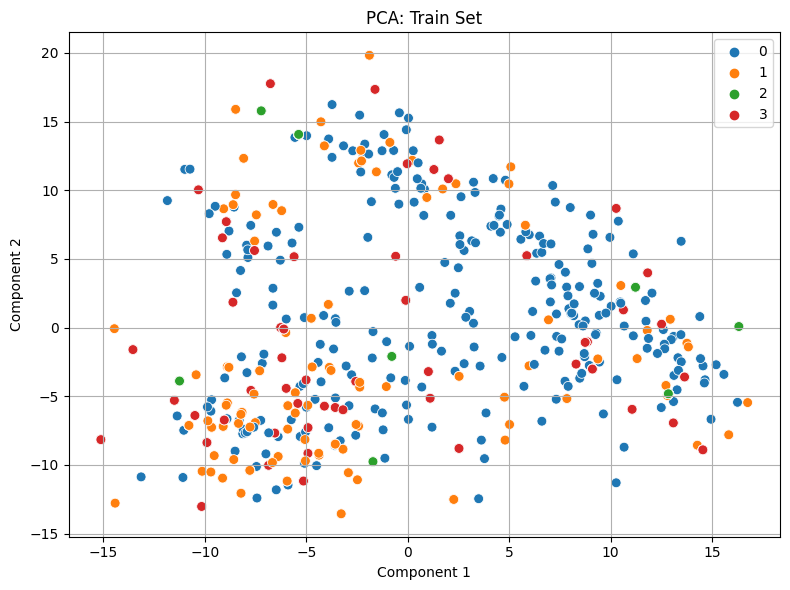

📁 Saved plot to /kaggle/working/phase3A/train_tsne.png


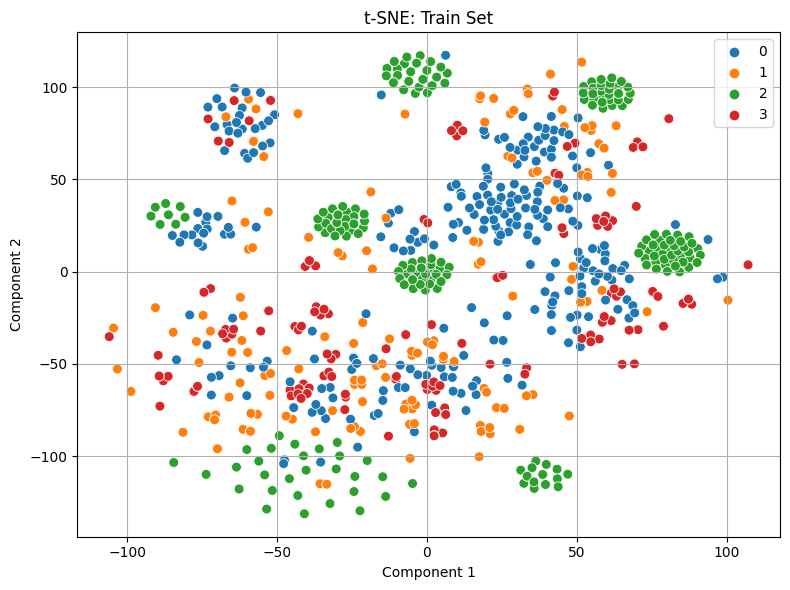

⚠️ Skipped /kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/Peking_1_TestRelease_phenotypic.csv: missing 'scandir_id' column
Combined feature_df shape before cleaning: (91, 583)
Shape after dropping all-NaN columns: (91, 566)
Shape after imputation: (91, 566)
📁 Saved plot to /kaggle/working/phase3A/val_pca.png


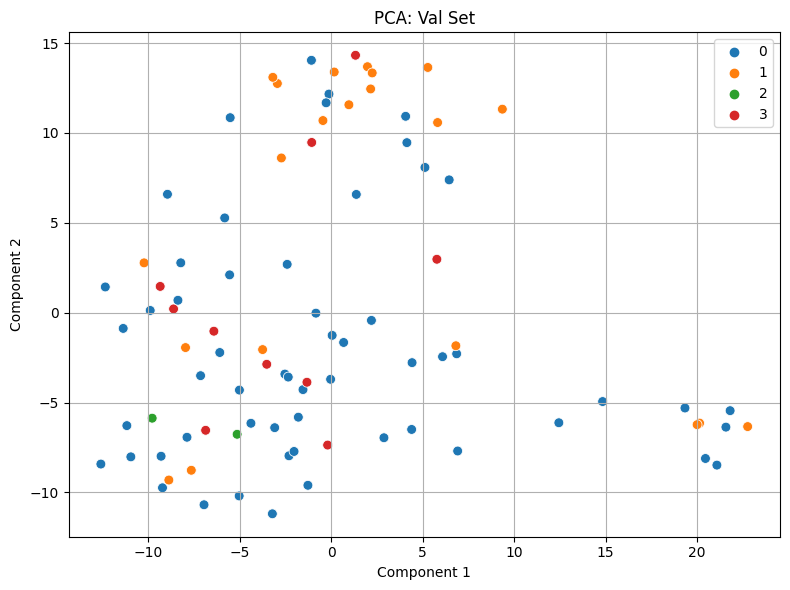

📁 Saved plot to /kaggle/working/phase3A/val_tsne.png


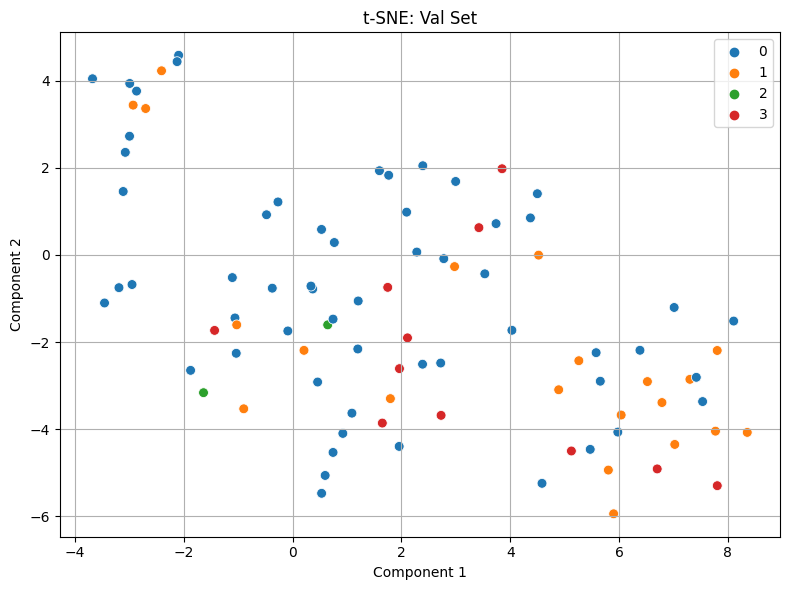

⚠️ Skipped /kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/Peking_1_TestRelease_phenotypic.csv: missing 'scandir_id' column
Combined feature_df shape before cleaning: (91, 583)
Shape after dropping all-NaN columns: (91, 566)
Shape after imputation: (91, 566)
📁 Saved plot to /kaggle/working/phase3A/test_pca.png


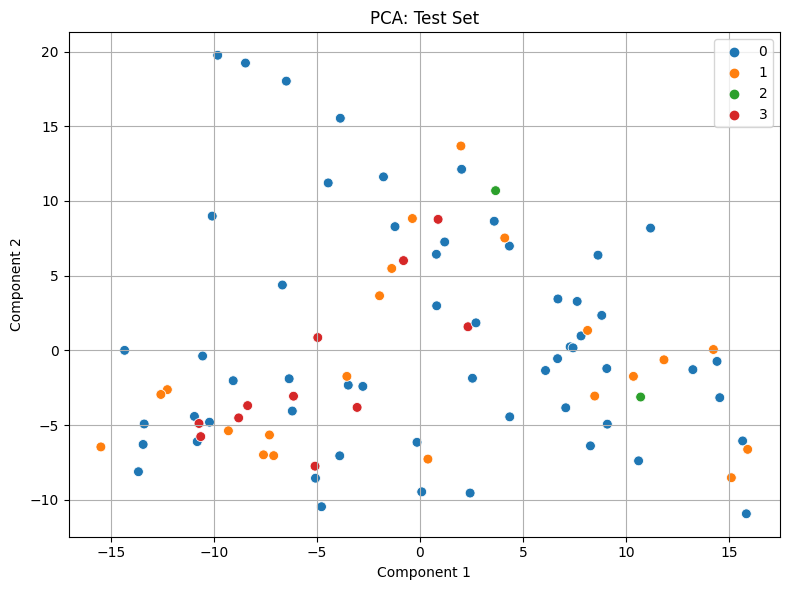

📁 Saved plot to /kaggle/working/phase3A/test_tsne.png


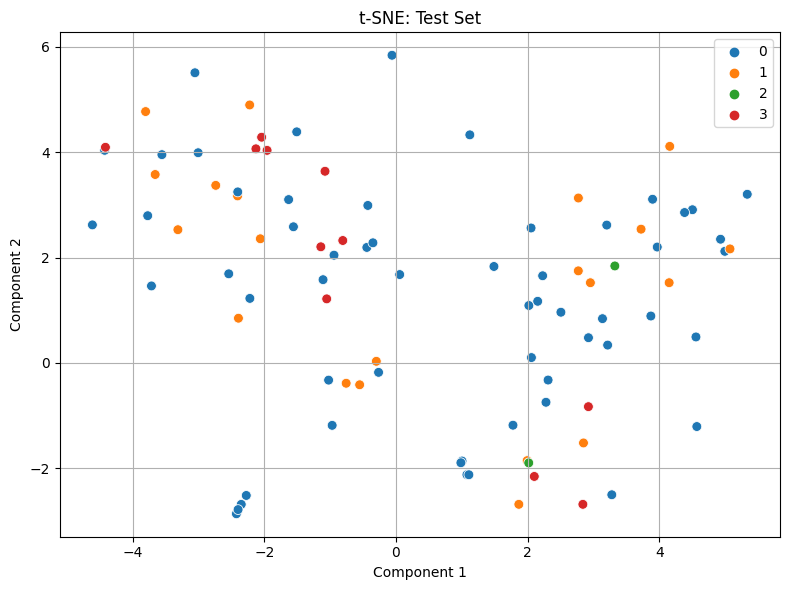

In [72]:
run_dimensionality_reduction("train")
run_dimensionality_reduction("val")
run_dimensionality_reduction("test")

In [23]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def run_radiomics_dimensionality_reduction(split="train"):
    # Load radiomics features
    radiomics_path = f"/kaggle/working/phase3B/{split}/radiomics_features.csv"
    
    df = pd.read_csv(radiomics_path)
    df.columns = df.columns.str.lower().str.strip()

    # Separate features and labels
    labels = df["label"].values
    features_df = df.drop(columns=["subject", "label", "site"], errors="ignore")

    # Drop columns that are entirely NaN
    features_df = features_df.dropna(axis=1, how="all")

    # Impute missing values
    imputer = SimpleImputer(strategy="mean")
    features_array = imputer.fit_transform(features_df)
    features_df = pd.DataFrame(features_array, columns=features_df.columns)

    # Normalize features
    features = StandardScaler().fit_transform(features_df.values)

    # Run dimensionality reduction
    #run_pca(features, labels, f"PCA: Radiomics ({split.capitalize()})")
    #run_tsne(features, labels, f"t-SNE: Radiomics ({split.capitalize()})")
    run_pca(features, labels, f"PCA: {split.capitalize()} Set", save_path=f"/kaggle/working/phase3B/{split}_pca.png")
    run_tsne(features, labels, f"t-SNE: {split.capitalize()} Set", save_path=f"/kaggle/working/phase3B/{split}_tsne.png")

📁 Saved plot to /kaggle/working/phase3B/train_pca.png


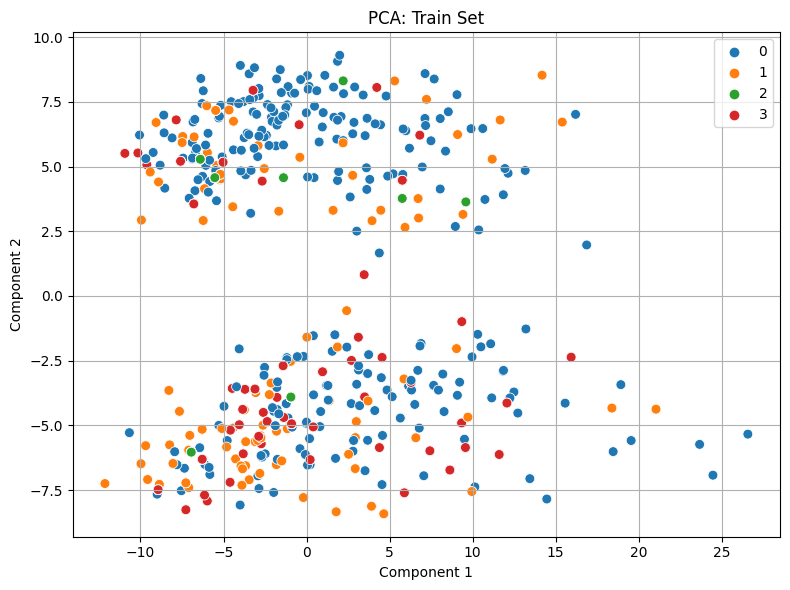

📁 Saved plot to /kaggle/working/phase3B/train_tsne.png


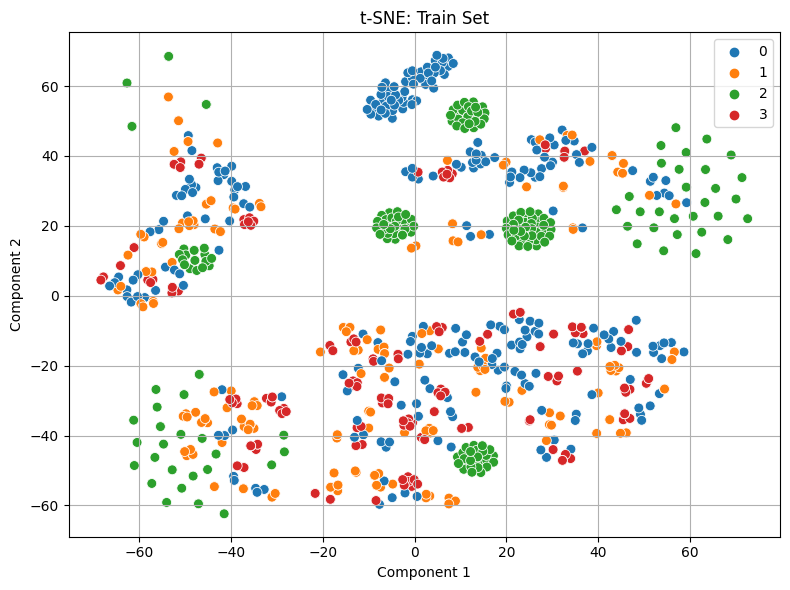

📁 Saved plot to /kaggle/working/phase3B/val_pca.png


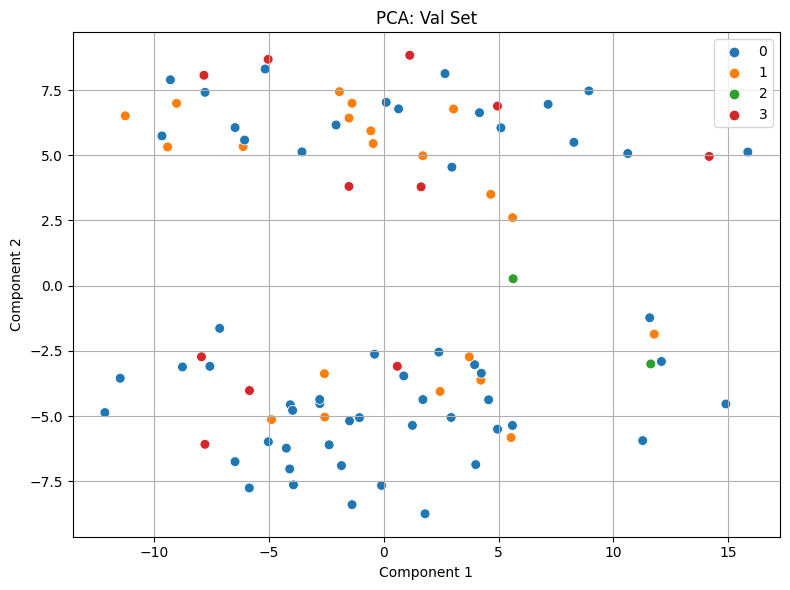

📁 Saved plot to /kaggle/working/phase3B/val_tsne.png


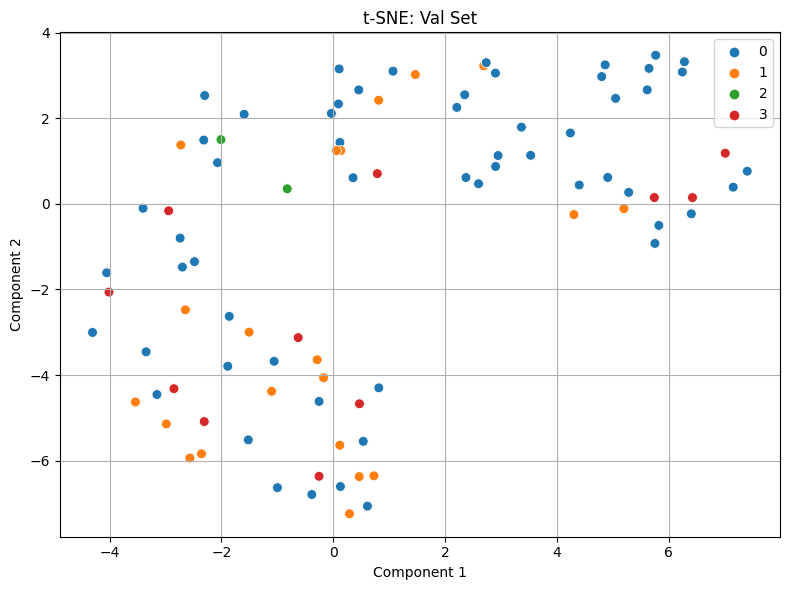

📁 Saved plot to /kaggle/working/phase3B/test_pca.png


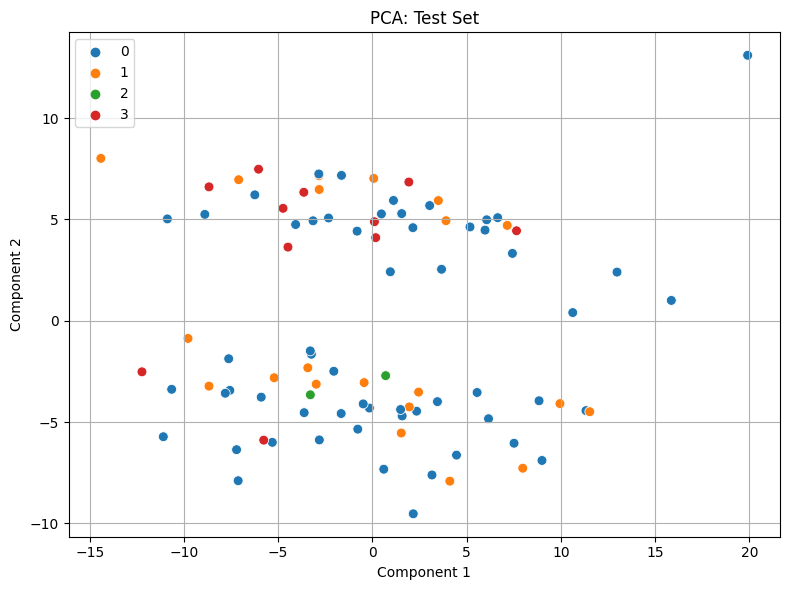

📁 Saved plot to /kaggle/working/phase3B/test_tsne.png


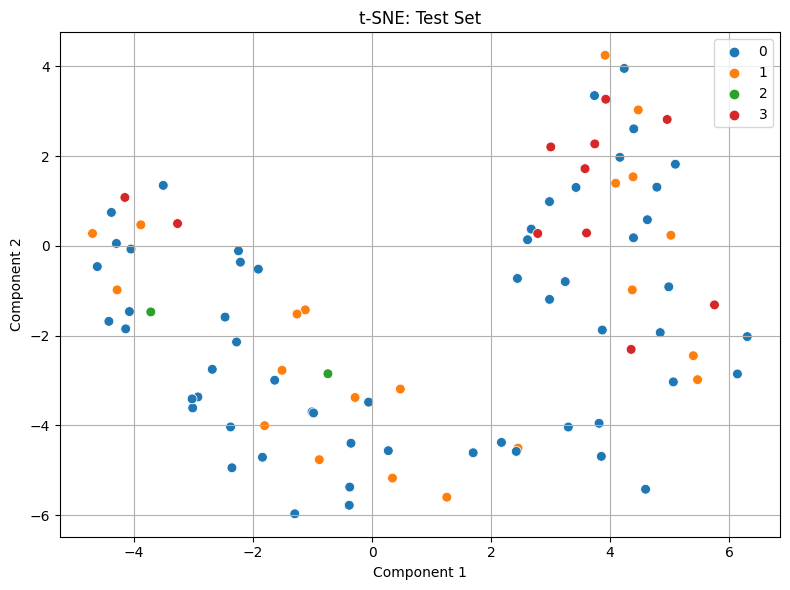

✅ Processed subject: 3310328_aug11
✅ Processed subject: 16056
✅ Processed subject: 4072305_aug3
✅ Processed subject: 10011
✅ Processed subject: 2697768_aug4
✅ Processed subject: 1918630_aug1
✅ Processed subject: 3684229
✅ Processed subject: 10041_aug18
✅ Processed subject: 16011
✅ Processed subject: 16086
✅ Processed subject: 1019436_aug3
✅ Processed subject: 10005_aug26
✅ Processed subject: 1391181
✅ Processed subject: 2773205
✅ Processed subject: 7129258
✅ Processed subject: 4072305_aug4
✅ Processed subject: 4919979
✅ Processed subject: 4091983
✅ Processed subject: 3108222_aug1
✅ Processed subject: 1187766_aug6
✅ Processed subject: 4154182
✅ Processed subject: 10041_aug26
✅ Processed subject: 10114
✅ Processed subject: 3310328_aug25
✅ Processed subject: 2367157_aug1
✅ Processed subject: 1779922
✅ Processed subject: 10098_aug2
✅ Processed subject: 2821683_aug3
✅ Processed subject: 4091983_aug1
✅ Processed subject: 1740607_aug3
✅ Processed subject: 16079
✅ Processed subject: 3519022_au

In [24]:
run_radiomics_dimensionality_reduction("train")
run_radiomics_dimensionality_reduction("val")
run_radiomics_dimensionality_reduction("test")

In [ ]:
df = pd.read_csv("/kaggle/input/phase3b/phase3B/train/radiomics_features.csv")
df.columns = df.columns.str.lower().str.strip()
print("Label distribution:", df["label"].value_counts())

In [60]:
# Load the full subject list with labels
full_df = pd.read_csv("/kaggle/input/phase1-2-output/finalized_outputs/phase2/val_subjects.csv")
full_df.columns = full_df.columns.str.lower().str.strip()

# Check label distribution in the full split
print("Full split label distribution:", full_df["label"].value_counts())

# Compare with radiomics
#radiomics_df = pd.read_csv("/kaggle/input/phase3b/phase3B/train/radiomics_features.csv")
#radiomics_df.columns = radiomics_df.columns.str.lower().str.strip()
#print("Radiomics label distribution:", radiomics_df["label"].value_counts())


Full split label distribution: label
2    61
1    57
0    57
3    52
Name: count, dtype: int64


In [ ]:
split_df = pd.read_csv("/kaggle/input/phase1-2/finalized_outputs/phase2/test_subjects.csv")
split_df.columns = split_df.columns.str.lower().str.strip()

radiomics_df = pd.read_csv("/kaggle/input/phase3b/phase3B/train/radiomics_features.csv")
radiomics_df.columns = radiomics_df.columns.str.lower().str.strip()

# Find label 2 subjects in split
label2_subjects = split_df.query("label == 2")["subject"]

# Find which ones are missing from radiomics
missing_subjects = label2_subjects[~label2_subjects.isin(radiomics_df["subject"])]
print("Missing label 2 subjects:", missing_subjects.tolist())


In [ ]:
for split in ["train", "val", "test"]:
    df = pd.read_csv(f"/kaggle/input/phase1-2/finalized_outputs/phase2/{split}_subjects.csv")
    print(f"\n📊 {split.capitalize()} Label Distribution:")
    print(df["label"].value_counts())


In [ ]:
# Load radiomics features
radiomics_df = pd.read_csv("/kaggle/input/phase3b/phase3B/train/radiomics_features.csv")
radiomics_df.columns = radiomics_df.columns.str.lower().str.strip()

# Load split subjects
split_df = pd.read_csv("/kaggle/input/phase1-2/finalized_outputs/phase2/train_subjects.csv")  # repeat for val/test
split_df.columns = split_df.columns.str.lower().str.strip()

# Check which subjects are missing
missing = split_df[~split_df["subject"].isin(radiomics_df["subject"])]
print("Missing subjects:", missing["subject"].tolist())
print("Missing label distribution:", missing["label"].value_counts())



In [1]:
import pandas as pd

# Load just the header
df = pd.read_csv("/kaggle/input/phase2/phase2/train_subjects.csv", nrows=0)

# Print column names
print("📋 Column titles:")
print(df.columns.tolist())


📋 Column titles:
['site', 'subject', 'anat_files', 'path', 'label', 'age_x', 'gender_x', 'handedness_x', 'full4_iq_x', 'subject_id', 'gender_y', 'age_y', 'handedness_y', 'dx', 'secondary_dx', 'adhd_measure', 'adhd_index', 'inattentive', 'hyper/impulsive', 'iq_measure', 'verbal_iq', 'performance_iq', 'full2_iq', 'full4_iq_y', 'med_status', 'qc_rest_1', 'qc_rest_2', 'qc_rest_3', 'qc_rest_4', 'qc_anatomical_1', 'qc_anatomical_2', 'source_file', 'id', 'is_augmented', 'aug_source_id']


# Phase 4A: Classical Model

In [2]:
CONFIG = {
    "classical_ml": {
        "svm": {
            "C": [0.1, 1, 10],
            "gamma": ['scale', 0.01, 0.1],
            "kernel": ["rbf"]
        },
        "rf": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    }
}
# add k mean cluster, it might perfrom very well for label 2
# reference, look at tSNE plot from phase 3A

In [3]:
MODEL_DIR = "/kaggle/working/models"
HISTORY_DIR = "/kaggle/working/history"
CHECKPOINTS_DIR = "/kaggle/working/checkpoints"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

In [4]:
import pandas as pd
import os

def extract_and_save_phenotypic_features(csv_path, split="train"):
    """
    Extract ADHD-relevant columns from a subject dataset and save to /kaggle/working/phase4a/.

    Parameters:
    - csv_path (str): Path to the input CSV file.
    - split (str): One of 'train', 'val', or 'test' to name the output file.
    """
    selected_columns = [
        'handedness_x', 'full4_iq_x', 'handedness_y', 'dx', 'secondary_dx',
        'adhd_measure', 'adhd_index', 'inattentive', 'hyper/impulsive',
        'iq_measure', 'verbal_iq', 'performance_iq', 'full2_iq', 'full4_iq_y',
        'med_status', 'qc_rest_1', 'qc_rest_2', 'qc_rest_3', 'qc_rest_4',
        'qc_anatomical_1', 'qc_anatomical_2'
    ]

    df = pd.read_csv(csv_path)

    if 'subject' in df.columns:
        selected_columns.insert(0, 'subject')

    filtered_df = df[selected_columns].copy()

    os.makedirs("/kaggle/working/phase4a", exist_ok=True)
    output_path = f"/kaggle/working/phase4a/phenotypic_features_{split}.csv"
    filtered_df.to_csv(output_path, index=False)

    print(f"✅ Saved ADHD features to: {output_path}")


In [5]:
def load_features(split, base_dir="/kaggle/input/phase3a-ver1/phase3A"):
    split_dir = os.path.join(base_dir, split)
    hist = joblib.load(os.path.join(split_dir, "hist_final.pkl"))
    texture = joblib.load(os.path.join(split_dir, "texture_final.pkl"))
    deep = joblib.load(os.path.join(split_dir, "deep_final.pkl"))
    meta = pd.read_csv(os.path.join(split_dir, "metadata.csv"))
    return hist, texture, deep, meta


In [6]:
import numpy as np
import pandas as pd

def combine_features(hist, texture, deep, meta, phenotypic_path):
    """
    Combine histogram, texture, deep features with phenotypic data.
    """
    # Convert lists to NumPy arrays
    hist = np.array(hist)
    texture = np.array(texture)
    deep = np.array(deep)

    # Load phenotypic features
    phenotypic_df = pd.read_csv(phenotypic_path)

    # Create feature DataFrames
    hist_df = pd.DataFrame(hist, columns=[f"hist_{i}" for i in range(hist.shape[1])])
    texture_df = pd.DataFrame(texture, columns=[f"texture_{i}" for i in range(texture.shape[1])])
    deep_df = pd.DataFrame(deep, columns=[f"deep_{i}" for i in range(deep.shape[1])])

    # Attach subject IDs
    hist_df['subject'] = meta['subject'].values
    texture_df['subject'] = meta['subject'].values
    deep_df['subject'] = meta['subject'].values

    # Merge all features
    features_df = hist_df.merge(texture_df, on='subject').merge(deep_df, on='subject')

    # Merge with phenotypic data
    combined_df = features_df.merge(phenotypic_df, on='subject')

    print(f"✅ Combined feature set shape: {combined_df.shape}")
    return combined_df


In [7]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

def clean_combined_features(df, missing_threshold=0.8, reference_columns=None):
    """
    Cleans a combined feature DataFrame by dropping high-missing columns and imputing the rest.
    If reference_columns is provided, aligns output to match those columns.
    """
    missing_ratio = df.isnull().mean()
    cols_to_drop = missing_ratio[missing_ratio > missing_threshold].index.tolist()
    df_clean = df.drop(columns=cols_to_drop)

    subject_ids = df_clean['subject']
    features = df_clean.drop(columns=['subject'], errors='ignore')

    # Impute missing values
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    features_imputed = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

    # Align columns if reference is provided
    if reference_columns is not None:
        for col in reference_columns:
            if col not in features_imputed.columns:
                features_imputed[col] = 0  # fill missing columns with zeros
        features_imputed = features_imputed[reference_columns]

    final_df = pd.concat([subject_ids.reset_index(drop=True), features_imputed], axis=1)
    return final_df


In [8]:
extract_and_save_phenotypic_features("/kaggle/input/phase2/phase2/train_subjects.csv", split="train")
hist, texture, deep, meta = load_features(split="train")
combined_df = combine_features(hist, texture, deep, meta, phenotypic_path="/kaggle/working/phase4a/phenotypic_features_train.csv")

print(combined_df.shape)
combined_df.head()


missing = combined_df.isnull().sum()
print("🧼 Missing values per column:")
print(missing[missing > 0])

cleaned_train_df = clean_combined_features(combined_df)

✅ Saved ADHD features to: /kaggle/working/phase4a/phenotypic_features_train.csv
✅ Combined feature set shape: (1056, 588)
(1056, 588)
🧼 Missing values per column:
handedness_x          3
full4_iq_x          130
handedness_y          3
secondary_dx        851
adhd_measure        215
adhd_index          390
inattentive         215
hyper/impulsive     215
iq_measure          130
verbal_iq           337
performance_iq      337
full2_iq           1003
full4_iq_y          130
med_status          215
qc_rest_1            16
qc_rest_2           551
qc_rest_3           849
qc_rest_4          1056
qc_anatomical_1       3
qc_anatomical_2     823
dtype: int64


In [9]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# ------------------ Model Training Functions ------------------

def train_random_forest(X, y):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X, y)
    return clf

def train_svm(X, y):
    clf = SVC(kernel='rbf', probability=True, random_state=42)
    clf.fit(X, y)
    return clf


In [10]:
# ------------------ Evaluation Function ------------------

from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

def evaluate_model(clf, X, y, split_name, model_name, output_dir="/kaggle/working/phase4a"):
    preds = clf.predict(X)
    report = classification_report(y, preds, output_dict=True, zero_division=0)

    # AUC calculation
    try:
        # Get predicted probabilities
        if hasattr(clf, "predict_proba"):
            probs = clf.predict_proba(X)
        elif hasattr(clf, "decision_function"):
            probs = clf.decision_function(X)
        else:
            probs = None

        # Binarize labels for multiclass AUC
        y_bin = label_binarize(y, classes=sorted(set(y)))
        if probs is not None and y_bin.shape[1] > 1:
            auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
        elif probs is not None:
            auc = roc_auc_score(y, probs[:, 1])
        else:
            auc = None
    except Exception as e:
        auc = None

    report_df = pd.DataFrame(report).transpose()
    os.makedirs(output_dir, exist_ok=True)

    filename = f"{split_name.lower()}_{model_name.lower()}_report.csv"
    output_path = os.path.join(output_dir, filename)
    report_df.to_csv(output_path)

    print(f"\n📊 {split_name} Results — {model_name}")
    print(report_df.round(2))
    if auc is not None:
        print(f"🧮 AUC Score: {auc:.4f}")
    else:
        print("⚠️ AUC could not be computed for this model.")
    print(f"✅ Saved report → {output_path}")


In [22]:
def save_predictions(clf, X, y, subjects, split_name, model_name, output_dir="/kaggle/working/phase4a"):
    # Get probabilities if available, else fall back
    if hasattr(clf, "predict_proba"):
        preds = clf.predict_proba(X)
    elif hasattr(clf, "decision_function"):
        preds = clf.decision_function(X)
        from sklearn.preprocessing import MinMaxScaler
        preds = MinMaxScaler().fit_transform(preds)
    else:
        preds = clf.predict(X).reshape(-1, 1)

    df = pd.DataFrame(preds, columns=[f"{model_name}_class{i}" for i in range(preds.shape[1])])
    df.insert(0, "subject", subjects)
    df["true_label"] = y

    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"{split_name}_{model_name}_preds.csv")
    df.to_csv(output_path, index=False)

    print(f"✅ Saved predictions → {output_path}")


In [25]:
def run_model_pipeline(split_name, base_dir="/kaggle/input/phase2/phase2", 
                       output_dir="/kaggle/working/phase4a", reference_columns=None):
    input_csv_path = os.path.join(base_dir, f"{split_name}_subjects.csv")
    phenotypic_path = os.path.join(output_dir, f"phenotypic_features_{split_name}.csv")
    extract_and_save_phenotypic_features(input_csv_path, split=split_name)

    hist, texture, deep, meta = load_features(split_name)
    combined_df = combine_features(hist, texture, deep, meta, phenotypic_path)
    cleaned_df = clean_combined_features(combined_df, reference_columns=reference_columns)

    # ✅ Remove label == 2 from meta only
    meta = meta[meta['label'] != 2].reset_index(drop=True)

    # ✅ Reindex labels to be contiguous and 0-based
    label_map = {label: idx for idx, label in enumerate(sorted(meta['label'].unique()))}
    meta['label'] = meta['label'].map(label_map)

    print(f"{split_name} labels:", sorted(meta['label'].unique()))

    # Align cleaned_df with filtered meta subjects
    cleaned_df = cleaned_df[cleaned_df['subject'].isin(meta['subject'])].reset_index(drop=True)

    X = cleaned_df.drop(columns=['subject'], errors='ignore')
    y = meta['label']

    # Train models only for train split
    rf, svm = None, None
    if split_name == "train":
        rf = train_random_forest(X, y)
        svm = train_svm(X, y)

    return rf, svm, X, y, meta, X.columns.tolist()


In [26]:
# Train only on train split
rf, svm, X_train, y_train, meta_train, train_columns = run_model_pipeline("train")

# Save train predictions
save_predictions(rf, X_train, y_train, meta_train['subject'], "train", "RandomForest", output_dir="/kaggle/working/phase4a")
save_predictions(svm, X_train, y_train, meta_train['subject'], "train", "SVM", output_dir="/kaggle/working/phase4a")

# Validation
_, _, X_val, y_val, meta_val, _ = run_model_pipeline("val", reference_columns=train_columns)

# Evaluate + Save predictions using models trained on train
for model, name in [(rf, "RandomForest"), (svm, "SVM")]:
    evaluate_model(model, X_val, y_val, "Validation", name)
    save_predictions(model, X_val, y_val, meta_val['subject'], "val", name, output_dir="/kaggle/working/phase4a")

# Test
_, _, X_test, y_test, meta_test, _ = run_model_pipeline("test", reference_columns=train_columns)

for model, name in [(rf, "RandomForest"), (svm, "SVM")]:
    evaluate_model(model, X_test, y_test, "Test", name)
    save_predictions(model, X_test, y_test, meta_test['subject'], "test", name, output_dir="/kaggle/working/phase4a")


✅ Saved ADHD features to: /kaggle/working/phase4a/phenotypic_features_train.csv
✅ Combined feature set shape: (1056, 588)
train labels: [0, 1, 2]
✅ Saved predictions → /kaggle/working/phase4a/train_RandomForest_preds.csv
✅ Saved predictions → /kaggle/working/phase4a/train_SVM_preds.csv
✅ Saved ADHD features to: /kaggle/working/phase4a/phenotypic_features_val.csv
✅ Combined feature set shape: (91, 588)
val labels: [0, 1, 2]

📊 Validation Results — RandomForest
              precision  recall  f1-score  support
0                  0.86    0.98      0.92    57.00
1                  0.74    0.81      0.77    21.00
2                  1.00    0.09      0.17    11.00
accuracy           0.83    0.83      0.83     0.83
macro avg          0.87    0.63      0.62    89.00
weighted avg       0.85    0.83      0.79    89.00
🧮 AUC Score: 0.9584
✅ Saved report → /kaggle/working/phase4b/validation_randomforest_report.csv
✅ Saved predictions → /kaggle/working/phase4a/val_RandomForest_preds.csv

📊 Validat

# Phase 4B: Classical Model Radiomic Features

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

def preprocess_features(X_train, X_val, X_test=None, scale=True, select_k=100):
    # Scale features
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        if X_test is not None:
            X_test = scaler.transform(X_test)

    # Feature selection
    if select_k:
        selector = SelectKBest(score_func=f_classif, k=min(select_k, X_train.shape[1]))
        X_train = selector.fit_transform(X_train, y_train)
        X_val = selector.transform(X_val)
        if X_test is not None:
            X_test = selector.transform(X_test)

    return X_train, X_val, X_test if X_test is not None else None


In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def train_random_forest(X, y):
    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    clf.fit(X, y)
    return clf

def train_svm(X, y):
    clf = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
    clf.fit(X, y)
    return clf


In [97]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import os

def evaluate_model(clf, X, y, split_name, model_name, output_dir="/kaggle/working/phase4b"):
    preds = clf.predict(X)
    report = classification_report(y, preds, output_dict=True, zero_division=0)

    try:
        if hasattr(clf, "predict_proba"):
            probs = clf.predict_proba(X)
        elif hasattr(clf, "decision_function"):
            probs = clf.decision_function(X)
        else:
            probs = None

        y_bin = label_binarize(y, classes=sorted(set(y)))
        if probs is not None and y_bin.shape[1] > 1:
            auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
        elif probs is not None:
            auc = roc_auc_score(y, probs[:, 1])
        else:
            auc = None
    except Exception:
        auc = None

    report_df = pd.DataFrame(report).transpose()
    os.makedirs(output_dir, exist_ok=True)

    filename = f"{split_name.lower()}_{model_name.lower()}_report.csv"
    output_path = os.path.join(output_dir, filename)
    report_df.to_csv(output_path)

    print(f"\n📊 {split_name} Results — {model_name}")
    print(report_df.round(2))
    if auc is not None:
        print(f"🧮 AUC Score: {auc:.4f}")
    else:
        print("⚠️ AUC could not be computed.")
    print(f"✅ Saved report → {output_path}")


In [98]:
def save_predictions(clf, X, y, subjects, split_name, model_name, output_dir="/kaggle/working/phase4a"):
    # Get probabilities if available, else fall back
    if hasattr(clf, "predict_proba"):
        preds = clf.predict_proba(X)
    elif hasattr(clf, "decision_function"):
        preds = clf.decision_function(X)
        from sklearn.preprocessing import MinMaxScaler
        preds = MinMaxScaler().fit_transform(preds)
    else:
        preds = clf.predict(X).reshape(-1, 1)

    df = pd.DataFrame(preds, columns=[f"{model_name}_class{i}" for i in range(preds.shape[1])])
    df.insert(0, "subject", subjects)
    df["true_label"] = y

    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f"{split_name}_{model_name}_preds.csv")
    df.to_csv(output_path, index=False)

    print(f"✅ Saved predictions → {output_path}")


In [99]:
def run_radiomic_pipeline(split_name, base_path="/kaggle/input/phase3b-ver1/phase3B"):
    import os
    import pandas as pd

    file_path = os.path.join(base_path, split_name, "radiomics_features.csv")
    df = pd.read_csv(file_path)

    # ✅ Remove label == 2
    df = df[df["label"] != 2].reset_index(drop=True)

    # ✅ Reindex labels to be contiguous and 0-based
    label_map = {label: idx for idx, label in enumerate(sorted(df["label"].unique()))}
    df["label"] = df["label"].map(label_map)

    print(f"{split_name} labels:", sorted(df["label"].unique()))

    subjects = df["subject"].values
    y = df["label"].values
    X = df.drop(columns=["subject", "label"], errors="ignore").select_dtypes(include=["number"])

    return X, y, subjects


In [101]:
# Load data
X_train, y_train, subjects_train = run_radiomic_pipeline("train")
X_val, y_val, subjects_val = run_radiomic_pipeline("val")
X_test, y_test, subjects_test = run_radiomic_pipeline("test")

# Preprocess
X_train_scaled, X_val_scaled, X_test_scaled = preprocess_features(
    X_train, X_val, X_test, scale=True, select_k=100
)

# Train models only on train split
rf = train_random_forest(X_train_scaled, y_train)
svm = train_svm(X_train_scaled, y_train)

# ✅ Train predictions (newly added)
"""
for model, name in [(rf, "RandomForest_Radiomic"), (svm, "SVM_Radiomic")]:
    evaluate_model(model, X_train_scaled, y_train, "Train", name)
    save_predictions(model, X_train_scaled, y_train, subjects_train,
                     "train", name, output_dir="/kaggle/working/phase4b")

"""

# Validation + Test predictions (already present)
for model, name in [(rf, "RandomForest_Radiomic"), (svm, "SVM_Radiomic")]:
    # Validation
    evaluate_model(model, X_val_scaled, y_val, "Validation", name)
    save_predictions(model, X_val_scaled, y_val, subjects_val,
                     "val", name, output_dir="/kaggle/working/phase4b")

    # Test
    evaluate_model(model, X_test_scaled, y_test, "Test", name)
    save_predictions(model, X_test_scaled, y_test, subjects_test,
                     "test", name, output_dir="/kaggle/working/phase4b")


train labels: [0, 1, 2]
val labels: [0, 1, 2]
test labels: [0, 1, 2]

📊 Validation Results — RandomForest_Radiomic
              precision  recall  f1-score  support
0                  0.72    0.81      0.76    57.00
1                  0.37    0.33      0.35    21.00
2                  0.33    0.18      0.24    11.00
accuracy           0.62    0.62      0.62     0.62
macro avg          0.47    0.44      0.45    89.00
weighted avg       0.59    0.62      0.60    89.00
🧮 AUC Score: 0.6296
✅ Saved report → /kaggle/working/phase4b/validation_randomforest_radiomic_report.csv
✅ Saved predictions → /kaggle/working/phase4b/val_RandomForest_Radiomic_preds.csv

📊 Test Results — RandomForest_Radiomic
              precision  recall  f1-score  support
0                  0.77    0.70      0.73    57.00
1                  0.37    0.48      0.42    21.00
2                  0.20    0.18      0.19    11.00
accuracy           0.58    0.58      0.58     0.58
macro avg          0.45    0.45      0.45    8

# Phase 4C: Deep Learning Model

In [2]:
import torch

# ✅ Device setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🧠 Using device: {device}")

# ✅ Training configuration for each model type

#"lr": 1.1405665645801372e-05
#"lr": 5e-5
CONFIG = {
    "deep_learning": {
        "2dcnn": {
            "lr": 1e-4,
            "dropout": 0.011358447997696974,
            "batch_size": 16,
            "weight_decay": 0.008017436210740692,
            "optimizer": "AdamW",
            "scheduler": "plateau",
            "use_pretrained": True,
            "epochs": 20,
            "patience": 10,
            "unfreeze_epoch": 7
       },
        "3dcnn": {
            "lr": 1e-5,
            "dropout": 0.0,
            "batch_size": 2,
            "epochs": 15,
            "patience": 10,
            "scheduler": "plateau",
            "weight_decay": 0.0
        },
        "convlstm": {
            "lr": 1e-5,
            "dropout": 0.0,
            "batch_size": 4,
            "epochs": 20,
            "patience": 10,
            "scheduler": "plateau",
            "weight_decay": 0.0
        },
        "vit": {
            "lr": 1e-5,
            "dropout": 0.0,
            "batch_size": 4,
            "epochs": 20,
            "patience": 10,
            "scheduler": "plateau",
            "weight_decay": 0.0
        }
    }
}


🧠 Using device: cuda


In [3]:
import pandas as pd
import os
from glob import glob

def load_raw_mri_dataframe(csv_path):
    df = pd.read_csv(csv_path)
    df['anat_files'] = df['anat_files'].apply(eval)
    df['anat_path'] = df.apply(lambda r: os.path.join(r['path'], r['anat_files'][0]), axis=1)
    df['binary_label'] = (df['label'] > 0).astype(int)
    return fix_paths(df)

def fix_paths(df):
    fixed_paths = []
    for p in df['anat_path']:
        if os.path.isdir(p):
            nii_files = glob(os.path.join(p, "*.nii"))
            fixed_paths.append(nii_files[0] if nii_files else None)
        else:
            fixed_paths.append(p)
    df['anat_path'] = fixed_paths
    df = df.dropna(subset=['anat_path']).reset_index(drop=True)
    return df


In [5]:
import numpy as np
import scipy.ndimage as ndi
import torchio as tio

class BrainPreprocessor:
    def __init__(self, clip_range=(-2, 2), resize_shape=(128, 128, 128), normalize=True):
        self.clip_range = clip_range
        self.resize_shape = resize_shape
        self.normalize = normalize

    def preprocess_volume(self, volume):
        # Clip intensities to reduce outliers
        volume = np.clip(volume, *self.clip_range)

        # Resize to target shape using linear interpolation
        if volume.shape != self.resize_shape:
            zoom_factors = [r / s for r, s in zip(self.resize_shape, volume.shape)]
            volume = ndi.zoom(volume, zoom_factors, order=1)

        # Normalize to [0, 1] range
        if self.normalize:
            volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)

        return volume

    def extract_slice(self, volume, axis=2, slice_index=None):
        # Use central slice if index not specified
        if slice_index is None:
            slice_index = volume.shape[axis] // 2

        # Extract and normalize 2D slice
        slice_2d = np.take(volume, slice_index, axis=axis)
        slice_2d = np.clip(slice_2d, *self.clip_range)
        slice_2d = (slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8)

        return slice_2d

def augment_3d(volume):
    # Wrap volume in TorchIO Subject
    subject = tio.Subject(mri=tio.ScalarImage(tensor=volume[np.newaxis, ...]))

    # Define augmentation pipeline
    transform = tio.Compose([
        tio.RandomFlip(axes=(0, 1, 2), flip_probability=0.3),
        tio.RandomElasticDeformation(num_control_points=7, max_displacement=7, locked_borders=2, p=0.3),
        tio.RandomAffine(scales=0.1, degrees=10, translation=5, p=0.3),
        tio.RescaleIntensity(out_min_max=(0, 1))
    ])

    # Apply augmentation and return volume
    augmented = transform(subject)
    return augmented.mri.tensor.squeeze(0).numpy()


In [6]:
from torch.utils.data import Dataset
import torch
import nibabel as nib
import numpy as np
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights
import scipy.ndimage as ndi

class RawImageDataset(Dataset):
    def __init__(self, df, mode='3d', use_preprocessor=True, include_metadata=False, label_map=None):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.use_preprocessor = use_preprocessor
        self.include_metadata = include_metadata
        self.label_map = label_map
        self.preprocessor = BrainPreprocessor() if use_preprocessor else None

        self.augment_2d = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0))

        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['anat_path']
        img = nib.load(img_path).get_fdata().astype(np.float32)

        # --- Preprocessing ---
        if self.use_preprocessor:
            img = self.preprocessor.preprocess_volume(img)
        else:
            img = (img - img.mean()) / (img.std() + 1e-5)
            img = np.clip(img, -5, 5)

        # --- Mode-specific handling ---
        if self.mode == '2d':
            slice_indices = np.linspace(0, img.shape[2] - 1, 3, dtype=int)
            slices = [img[:, :, i] for i in slice_indices]
            slices = [np.stack([s]*3, axis=-1) for s in slices]
            tensors = [self.augment_2d(s) for s in slices]
            img_tensor = torch.stack(tensors)  # [3, 3, 224, 224]

        elif self.mode == '3d':
            img = augment_3d(img)
            if img.shape != (64, 128, 128):
                zoom_factors = [64 / img.shape[0], 128 / img.shape[1], 128 / img.shape[2]]
                img = ndi.zoom(img, zoom_factors, order=1)
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # [1, D, H, W]

        elif self.mode == 'convlstm':
            slices = [self.preprocessor.extract_slice(img, axis=0, slice_index=z)
                      for z in np.linspace(0, img.shape[0] - 1, 16, dtype=int)]
            img_tensor = torch.tensor(np.stack(slices), dtype=torch.float32).unsqueeze(1)  # [16, 1, H, W]

        elif self.mode == 'vit':
            img = augment_3d(img)
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # [1, D, H, W]

        else:
            raise ValueError(f"Invalid mode: {self.mode}")

        # --- Multiclass label with optional remapping ---
        raw_label = row['label']
        if self.label_map:
            label = torch.tensor(self.label_map[raw_label], dtype=torch.long)
        else:
            label = torch.tensor(int(raw_label), dtype=torch.long)

        assert label >= 0, f"Invalid label: {label.item()}"

        # --- Metadata (optional) ---
        if self.include_metadata:
            site_map = {s: i for i, s in enumerate(sorted(self.df['site'].unique()))}
            site_tensor = torch.eye(len(site_map))[self.df['site'].map(site_map).iloc[idx]]

            age = (row['age'] - self.df['age'].mean()) / (self.df['age'].std() + 1e-8)
            gender = float(row['gender'])
            meta_tensor = torch.tensor([
                age if not np.isnan(age) else 0.0,
                gender if not np.isnan(gender) else 0.0
            ], dtype=torch.float32)

            return img_tensor, label, site_tensor, meta_tensor

        return img_tensor, label


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3, meta_dim=2, site_dim=6,
                 use_metadata=False, fine_tune=False):
        super().__init__()
        self.use_metadata = use_metadata
        self.fine_tune = fine_tune

        weights = EfficientNet_B0_Weights.DEFAULT
        self.backbone = efficientnet_b0(weights=weights)
        self.feature_dim = self.backbone.classifier[1].in_features

        # Remove original classifier
        self.backbone.classifier = nn.Identity()

        # Freeze backbone if not fine-tuning
        if not fine_tune:
            for param in self.backbone.parameters():
                param.requires_grad = False

        input_dim = self.feature_dim
        if use_metadata:
            input_dim += meta_dim + site_dim

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, site_tensor=None, meta_tensor=None):
        # Handle multi-slice input: [B, S, C, H, W]
        if x.dim() == 5:
            B, S, C, H, W = x.shape
            x = x.view(B * S, C, H, W)
            x = F.interpolate(x, size=(224, 224), mode='bilinear')
            x = self.backbone(x)
            x = x.view(B, S, -1).mean(dim=1)  # Average features across slices
        else:
            # Single image input: [B, C, H, W]
            if x.size(1) == 1:
                x = x.repeat(1, 3, 1, 1)
            x = F.interpolate(x, size=(224, 224), mode='bilinear')
            x = self.backbone(x)

        if self.use_metadata:
            if site_tensor is None or meta_tensor is None:
                raise ValueError("Model expects metadata but site_tensor or meta_tensor is missing.")
            x = torch.cat([x, site_tensor, meta_tensor], dim=1)

        return self.classifier(x)


**MedicalNet**
MedicalNet provides 3D ResNet variants pretrained on diverse medical datasets, making them ideal for transfer learning in tasks like brain MRI classification. These models outperform generic video models like r3d_18 in medical contexts.

In [8]:
import importlib.util
import types
import sys
import os
import torch

# === Step 1: Load resnet.py manually ===
resnet_path = "/kaggle/working/phase4c/MedicalNet/models/resnet.py"
resnet_spec = importlib.util.spec_from_file_location("resnet", resnet_path)
resnet_module = importlib.util.module_from_spec(resnet_spec)
resnet_spec.loader.exec_module(resnet_module)

# Inject into sys.modules so model.py can find it
sys.modules["models"] = types.SimpleNamespace(resnet=resnet_module)


In [9]:
import os
import types
import importlib.util
import torch
import torch.nn as nn
import torch.nn.functional as F

def _unwrap_dataparallel(module):
    return module.module if isinstance(module, nn.DataParallel) else module

def _find_first_conv_like(module):
    for child in module.children():
        if isinstance(child, (nn.Conv3d, nn.ConvTranspose3d)):
            return child
        found = _find_first_conv_like(child)
        if found is not None:
            return found
    return None

class MedicalNet3D(nn.Module):
    def __init__(self, num_classes=4, meta_dim=2, site_dim=6, use_metadata=False, fine_tune=False, debug=False):
        super().__init__()
        self.use_metadata = use_metadata
        self.fine_tune = fine_tune
        self.debug = debug

        # === Load MedicalNet's generate_model dynamically ===
        medicalnet_model_path = "/kaggle/working/phase4c/MedicalNet/model.py"
        spec = importlib.util.spec_from_file_location("medicalnet_model", medicalnet_model_path)
        medicalnet_model = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(medicalnet_model)
        generate_model = medicalnet_model.generate_model

        # === Define MedicalNet options (CPU creation) ===
        opt = types.SimpleNamespace()
        opt.model = 'resnet'
        opt.model_depth = 10
        opt.input_W = 128
        opt.input_H = 128
        opt.input_D = 64
        opt.resnet_shortcut = 'B'
        opt.no_cuda = not torch.cuda.is_available()
        opt.gpu_id = [0] if torch.cuda.is_available() else []
        opt.n_seg_classes = num_classes
        opt.phase = 'train'
        opt.pretrain_path = ''

        # === Create backbone (on CPU) ===
        backbone, _ = generate_model(opt)
        backbone = _unwrap_dataparallel(backbone)

        if self.debug:
            print("Backbone conv_seg:", backbone.conv_seg)

        # === Robustly detect the incoming feature channels for conv_seg ===
        feature_in_channels = None
        # Try first child (covers ConvTranspose3d at index 0)
        try:
            first_child = next(iter(backbone.conv_seg.children()))
        except Exception:
            first_child = None

        if isinstance(first_child, (nn.Conv3d, nn.ConvTranspose3d)):
            feature_in_channels = first_child.in_channels
            if self.debug:
                print("Detected first child conv-like:", first_child)
        else:
            conv_like = _find_first_conv_like(backbone.conv_seg)
            if conv_like is not None:
                feature_in_channels = conv_like.in_channels
                if self.debug:
                    print("Detected conv-like (recursive):", conv_like)

        if feature_in_channels is None:
            raise ValueError("Unable to detect conv input channels in backbone.conv_seg")

        if self.debug:
            print("Using feature_in_channels =", feature_in_channels)

        # === Load pretrained weights (CPU) ===
        checkpoint_path = "/kaggle/working/phase4c/resnet_10_23dataset.pth"
        if os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location='cpu')
            state_dict = checkpoint.get('state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint
            clean_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
            backbone.load_state_dict(clean_state_dict, strict=False)
            if self.debug:
                print("Loaded checkpoint into backbone (strict=False).")
        else:
            if self.debug:
                print(f"Warning: checkpoint not found at {checkpoint_path}")

        # === Freeze backbone if requested ===
        if not fine_tune:
            for param in backbone.parameters():
                param.requires_grad = False

        # === Replace final conv_seg with a 1x1 conv matching the real incoming channels ===
        backbone.conv_seg = nn.Sequential(
            nn.Conv3d(feature_in_channels, num_classes, kernel_size=1)
        )

        self.backbone = backbone

        # === Classifier head ===
        input_dim = num_classes
        if use_metadata:
            input_dim += meta_dim + site_dim

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, site_tensor=None, meta_tensor=None):
        # Ensure input shape matches expected D,H,W
        x = F.interpolate(x, size=(64, 128, 128), mode='trilinear', align_corners=False)
        features = self.backbone(x)  # expected [B, C, D, H, W]

        if features.dim() == 5:
            features = features.mean(dim=[2, 3, 4])  # global pool to [B, C]

        if self.use_metadata:
            if site_tensor is None or meta_tensor is None:
                raise ValueError("Metadata expected but missing site_tensor or meta_tensor.")
            features = torch.cat([features, site_tensor, meta_tensor], dim=1)

        return self.classifier(features)


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

def _unwrap_dataparallel(module):
    return module.module if isinstance(module, nn.DataParallel) else module

def _find_last_conv2d_out_channels(module):
    # preorder traversal: return out_channels of the last Conv2d encountered
    last = None
    for child in module.children():
        if isinstance(child, nn.Conv2d):
            last = child.out_channels
        else:
            nested = _find_last_conv2d_out_channels(child)
            if nested is not None:
                last = nested
    return last

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size // 2
        self.bias = bias
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=self.padding, bias=bias)

    def forward(self, x, h_cur, c_cur):
        combined = torch.cat([x, h_cur], dim=1)
        conv_out = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(conv_out, self.hidden_dim, dim=1)
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class ConvLSTM(nn.Module):
    def __init__(
        self,
        input_dim=1,
        hidden_dim=32,
        kernel_size=3,
        num_layers=1,
        num_classes=3,
        use_pretrained=True,
        fine_tune=False,
        meta_dim=2,
        site_dim=6,
        dropout=0.3,
        use_metadata=True,
        debug=False
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.use_pretrained = use_pretrained
        self.fine_tune = fine_tune
        self.use_metadata = use_metadata
        self.debug = debug

        if use_pretrained:
            # Load resnet and use feature extractor up to last conv block (exclude avgpool & fc)
            resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            slice_encoder = nn.Sequential(*list(resnet.children())[:-2])
            slice_encoder = _unwrap_dataparallel(slice_encoder)

            # Detect encoder output channels robustly
            encoder_out_channels = _find_last_conv2d_out_channels(slice_encoder)
            if encoder_out_channels is None:
                # fallback to known resnet18 channel
                encoder_out_channels = 512
            self.slice_encoder = slice_encoder
            self.encoder_out_channels = encoder_out_channels

            # Freeze or unfreeze encoder parameters based on fine_tune flag
            for param in self.slice_encoder.parameters():
                param.requires_grad = bool(self.fine_tune)
            if self.debug:
                print("Using pretrained ResNet slice_encoder, out_channels =", self.encoder_out_channels)
        else:
            # simple conv encoder for single-channel input
            self.slice_encoder = nn.Conv2d(input_dim, hidden_dim, kernel_size=3, padding=1)
            self.encoder_out_channels = hidden_dim
            if self.debug:
                print("Using simple Conv2d slice_encoder, out_channels =", self.encoder_out_channels)

        # ConvLSTM cell expects input_dim == encoder_out_channels
        self.cell = ConvLSTMCell(self.encoder_out_channels, hidden_dim, kernel_size)
        self.pool = nn.AdaptiveAvgPool2d(1)

        input_dim_fc = hidden_dim
        if self.use_metadata:
            input_dim_fc += meta_dim + site_dim

        self.fc = nn.Sequential(
            nn.Linear(input_dim_fc, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, site_tensor=None, meta_tensor=None):
        # x expected shape [B, C, T, H, W]
        B, C, T, H, W = x.size()
        device = x.device

        # initialize hidden/cell on same device and with proper spatial dims
        # Use spatial size of encoder output after first pass to avoid shape mismatch
        h = torch.zeros(B, self.hidden_dim, H, W, device=device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=device)

        for t in range(T):
            xt = x[:, :, t, :, :]  # [B, C, H, W]

            if self.use_pretrained:
                # Rescale to ResNet expected input
                xt = F.interpolate(xt, size=(224, 224), mode='bilinear', align_corners=False)
                if xt.size(1) == 1:
                    xt = xt.repeat(1, 3, 1, 1)
                xt = self.slice_encoder(xt)  # [B, encoder_out_channels, h', w']

                # If hidden spatial size doesn't match encoder output, resize h & c
                if h.size(2) != xt.size(2) or h.size(3) != xt.size(3):
                    h = F.interpolate(h, size=xt.shape[2:], mode='bilinear', align_corners=False)
                    c = F.interpolate(c, size=xt.shape[2:], mode='bilinear', align_corners=False)
            else:
                # simple conv path preserves H,W
                xt = self.slice_encoder(xt)  # [B, encoder_out_channels, H, W]

            # Ensure xt has expected channel count for ConvLSTMCell
            if xt.size(1) != self.encoder_out_channels:
                raise RuntimeError(f"Encoder output channels {xt.size(1)} != expected {self.encoder_out_channels}")

            h, c = self.cell(xt, h, c)

        h = self.pool(h).view(B, -1)

        if self.use_metadata:
            if site_tensor is None or meta_tensor is None:
                raise ValueError("Metadata expected but missing site_tensor or meta_tensor.")
            h = torch.cat([h, site_tensor, meta_tensor], dim=1)

        return self.fc(h)


In [11]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

class ViT3D(nn.Module):
    def __init__(
        self,
        input_shape=(128, 128, 128),
        patch_size=16,
        embed_dim=768,
        num_heads=12,
        num_layers=12,
        num_classes=3,
        dropout=0.3,
        freeze_transformer=True,
        use_pretrained=True,
        debug=False
    ):
        super().__init__()
        self.D, self.H, self.W = input_shape
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.freeze_transformer = freeze_transformer
        self.use_pretrained = use_pretrained
        self.debug = debug

        # instantiate 2D ViT backbone as a feature extractor
        # num_classes=0 makes timm return features rather than class logits for many versions
        self.transformer = timm.create_model("vit_base_patch16_224", pretrained=use_pretrained, num_classes=0)

        # Try to detect expected per-slice feature dim from backbone
        backbone_feat_dim = getattr(self.transformer, "num_features", None)
        if backbone_feat_dim is None:
            backbone_feat_dim = getattr(self.transformer, "embed_dim", embed_dim)
        self.backbone_feat_dim = backbone_feat_dim

        if self.debug:
            print("ViT backbone feature dim (detected):", self.backbone_feat_dim)

        # classifier head maps pooled tokens -> final logits
        self.fc = nn.Sequential(
            nn.Linear(self.backbone_feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        if self.freeze_transformer:
            for param in self.transformer.parameters():
                param.requires_grad = False

    def _slice_features(self, x):
        """
        Run the 2D transformer on batch of slices x [N, 3, H, W].
        Return a tensor [N, feat_dim] - per-slice embedding.
        Handles different timm behaviors:
          - backbone.forward_features returns [N, feat_dim] (ideal)
          - backbone.forward_features or forward returns [N, seq_len*feat_dim] (flattened tokens)
          - backbone returns [N, seq_len, feat_dim] or [N, seq_len+1, feat_dim] (tokens incl. cls)
        Strategy:
          - call forward_features if exists, else call transformer(x)
          - inspect dims and reduce tokens -> single vector:
            * if 2D and size==feat_dim -> keep
            * if 2D and size > feat_dim -> reshape into (N, seq_len, feat_dim) using known feat_dim then take cls if seq_len==num_patches+1 else mean
            * if 3D -> if second dim is seq_len and last dim==feat_dim -> take cls at index 0 if present (commonly tokens[0]) else mean across tokens
        """
        if hasattr(self.transformer, "forward_features"):
            feats = self.transformer.forward_features(x)
        else:
            feats = self.transformer(x)

        # If feats is 4D like [N, C, 1, 1], flatten to [N, C]
        if feats.dim() == 4:
            feats = feats.view(feats.size(0), -1)

        # Case A: already in desired shape [N, feat_dim]
        if feats.dim() == 2 and feats.size(1) == self.backbone_feat_dim:
            return feats

        # Case B: flattened tokens [N, seq_len * feat_dim]
        if feats.dim() == 2 and feats.size(1) > self.backbone_feat_dim:
            N = feats.size(0)
            total = feats.size(1)
            if total % self.backbone_feat_dim == 0:
                seq_len = total // self.backbone_feat_dim
                try:
                    feats = feats.view(N, seq_len, self.backbone_feat_dim)
                    # Many ViT implementations place CLS token at index 0; choose it if seq_len == num_patches + 1
                    # We can't reliably know num_patches here, so choose: if seq_len > 1 use mean, else take the single token.
                    if seq_len == 1:
                        return feats.view(N, self.backbone_feat_dim)
                    # prefer CLS if it looks like CLS exists (seq_len > 1 and first token magnitude is notable)
                    cls_candidate = feats[:, 0, :]
                    # Use mean pooling for stability
                    pooled = feats.mean(dim=1)
                    if self.debug:
                        print(f"_slice_features: flattened->reshaped (N={N}, seq_len={seq_len}, feat_dim={self.backbone_feat_dim}), using mean pooling.")
                    return pooled
                except Exception:
                    # fallback to linear projection of flattened features
                    if self.debug:
                        print("_slice_features: could not reshape flattened tokens into (N, seq_len, feat_dim); applying adaptive pooling.")
                    pooled = feats.mean(dim=1, keepdim=False)
                    return pooled

        # Case C: sequence-like [N, seq_len, feat_dim] or [N, seq_len+1, feat_dim]
        if feats.dim() == 3:
            seq_len = feats.size(1)
            if seq_len == 1:
                return feats.view(feats.size(0), feats.size(2))
            # choose CLS token if common pattern (seq_len > 1) otherwise mean-pool
            # many ViT variants use CLS token at index 0
            cls_token = feats[:, 0, :]
            pooled = feats.mean(dim=1)
            if self.debug:
                print(f"_slice_features: token sequence detected seq_len={seq_len}, using mean pooling.")
            return pooled

        # Catch-all: flatten and reduce
        if self.debug:
            print(f"_slice_features: unexpected feats shape {feats.shape}, applying mean over dims.")
        return feats.view(feats.size(0), -1).mean(dim=1, keepdim=True).expand(-1, self.backbone_feat_dim)

    def forward(self, x):
        """
        x: tensor [B, C, D, H, W]  (C = 1 or 3)
        Process:
          - convert to 3-channel if necessary
          - reshape to (B*D, 3, H, W)
          - resize to ViT input (224,224)
          - run through 2D ViT backbone to get per-slice features [B*D, feat_dim]
          - reshape to [B, D, feat_dim], pool across D -> [B, feat_dim]
          - classifier -> [B, num_classes]
        """
        B, C, D, H, W = x.shape
        device = x.device

        # ensure channel dim is 3 for ViT
        if C == 1:
            x = x.repeat(1, 3, 1, 1, 1)  # [B,3,D,H,W]

        # Move depth into batch: (B*D, 3, H, W)
        x = x.permute(0, 2, 1, 3, 4).reshape(-1, 3, H, W)

        # Resize each slice to transformer expected input
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        # Get per-slice features robustly
        feats = self._slice_features(x)  # [B*D, feat_dim]

        # Ensure feats flattened shape is correct
        if feats.dim() != 2 or feats.size(1) != self.backbone_feat_dim:
            if self.debug:
                print("After _slice_features: feats.shape =", feats.shape, "expected feat_dim =", self.backbone_feat_dim)
            # try to reduce to desired dim via linear projection
            feats = feats.view(feats.size(0), -1)
            if feats.size(1) != self.backbone_feat_dim:
                # linear projection to backbone_feat_dim
                proj = nn.Linear(feats.size(1), self.backbone_feat_dim).to(feats.device)
                feats = proj(feats)

        # reshape back to [B, D, feat_dim]
        feats = feats.view(B, D, -1)

        # pool across depth -> [B, feat_dim]
        pooled = feats.mean(dim=1)

        if self.debug:
            print("feats shape:", feats.shape, "pooled shape:", pooled.shape)

        return self.fc(pooled)


The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from torch.amp import autocast, GradScaler
from torch.cuda.amp import autocast, GradScaler


def train_model(model, train_df, val_df, config, mode="2d", model_name="model", checkpoint=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    use_amp = torch.cuda.is_available()
    scaler = GradScaler(enabled=torch.cuda.is_available())

    
    save_dir = "/kaggle/working/phase4c"
    os.makedirs(save_dir, exist_ok=True)

    checkpoint_dir = os.path.join(save_dir, "checkpoints")
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(checkpoint_dir, exist_ok=True)


    print(f"\n🚀 Training {model_name.upper()} ({mode}) on {device}")

    include_metadata = getattr(model, "use_metadata", False)
    train_ds = RawImageDataset(train_df, mode=mode, use_preprocessor=True, include_metadata=include_metadata)
    val_ds   = RawImageDataset(val_df,   mode=mode, use_preprocessor=True, include_metadata=include_metadata)

    # === Class weights ===
    classes = np.unique(train_df['label'])
    weights = compute_class_weight('balanced', classes=classes, y=train_df['label'])
    weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
    print("📊 Class Weights:", dict(zip(classes, weights_tensor.cpu().numpy())))

    # === Oversampling ===
    class_counts = train_df['label'].value_counts().sort_index()
    sample_weights = train_df['label'].map(lambda x: 1.0 / class_counts[x]).values
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_dl = DataLoader(train_ds, batch_size=config["batch_size"], sampler=sampler, num_workers=2)
    val_dl   = DataLoader(val_ds,   batch_size=config["batch_size"], shuffle=False, num_workers=2)

    # === Model, optimizer, scheduler, criterion ===
    model = model.to(device)

    # Optimizer selection (supports AdamW if requested in config)
    optim_name = config.get("optimizer", "Adam")
    if optim_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config["lr"],
            weight_decay=config.get("weight_decay", 0.0)
        )
    else:
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config["lr"],
            weight_decay=config.get("weight_decay", 0.0)
        )

    scheduler_name = config.get("scheduler", "none")
    scheduler = None
    if scheduler_name == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    elif scheduler_name == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, config["epochs"]))

    
    scaler = GradScaler()

    # Label smoothing added here
    label_smoothing = config.get("label_smoothing", 0.0)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=float(label_smoothing))

    start_epoch = 0
    best_acc = 0.0
    wait = 0
    patience = config.get("patience", 5)
    log_rows = []

    # === Resume from checkpoint (stateful) ===
    if checkpoint and os.path.exists(checkpoint):
        print(f"🔁 Loading checkpoint: {checkpoint}")
        ck = torch.load(checkpoint, map_location=device, weights_only=False)
        # try to load model state
        if "model_state" in ck:
            model.load_state_dict(ck["model_state"])
        else:
            model.load_state_dict(ck)
        # load optimizer / scheduler / metadata if present
        if "optimizer_state" in ck:
            optimizer.load_state_dict(ck["optimizer_state"])
        if "scheduler_state" in ck and scheduler is not None:
            try:
                scheduler.load_state_dict(ck["scheduler_state"])
            except Exception:
                pass
        start_epoch = ck.get("epoch", 0)
        best_acc = ck.get("best_acc", 0.0)
        wait = ck.get("wait", 0)
        # if training log exists in checkpoint, restore
        log_rows = ck.get("log_rows", [])

    # === Training loop ===
    for epoch in range(start_epoch, config["epochs"]):
        if hasattr(model, "fine_tune") and epoch == config.get("unfreeze_epoch", -1):
            model.fine_tune = True
            print(f"🔓 Fine-tuning enabled at epoch {epoch+1}")

        model.train()
        total, correct, running_loss = 0, 0, 0.0
        loop = tqdm(train_dl, desc=f"Epoch {epoch+1}/{config['epochs']}")
        for batch in loop:
            if len(batch) == 4:
                imgs, labels, site_tensor, meta_tensor = batch
            else:
                imgs, labels = batch
                site_tensor = meta_tensor = None

            imgs, labels = imgs.to(device), labels.to(device).long().view(-1)
            assert labels.numel() > 0, "Empty label tensor in batch"
            # label range check (useful when classes were removed)
            assert labels.max().item() < len(classes), f"Label {labels.max().item()} exceeds num_classes={len(classes)}"

            if site_tensor is not None: site_tensor = site_tensor.to(device)
            if meta_tensor is not None: meta_tensor = meta_tensor.to(device)

            if mode == 'convlstm':
                imgs = imgs.permute(0, 2, 1, 3, 4) if imgs.ndim == 5 else imgs.unsqueeze(1)
            elif mode == 'vit' and imgs.ndim == 4:
                imgs = imgs.unsqueeze(1)

            optimizer.zero_grad()

            use_amp = torch.cuda.is_available()
            scaler = GradScaler(enabled=use_amp)

            with autocast(enabled=use_amp):
                out = model(imgs, site_tensor, meta_tensor) if include_metadata else model(imgs)
                out = torch.clamp(out, min=-10, max=10)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()


            pred = torch.argmax(out, dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item() * labels.size(0)

        train_acc = correct / total if total > 0 else 0.0
        avg_loss = running_loss / total if total > 0 else 0.0

        # Log current LR (works for all schedulers)
        if scheduler is not None:
            try:
                current_lr = scheduler.get_last_lr()[0]
            except Exception:
                current_lr = optimizer.param_groups[0]['lr']
        else:
            current_lr = optimizer.param_groups[0]['lr']
        print(f"📉 Learning Rate: {current_lr:.6f}")

        # === Validation ===
        model.eval()
        val_correct, val_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_dl:
                if len(batch) == 4:
                    imgs, labels, site_tensor, meta_tensor = batch
                else:
                    imgs, labels = batch
                    site_tensor = meta_tensor = None

                imgs, labels = imgs.to(device), labels.to(device).long().view(-1)
                if site_tensor is not None: site_tensor = site_tensor.to(device)
                if meta_tensor is not None: meta_tensor = meta_tensor.to(device)

                if mode == 'convlstm':
                    imgs = imgs.permute(0, 2, 1, 3, 4) if imgs.ndim == 5 else imgs.unsqueeze(1)
                elif mode == 'vit' and imgs.ndim == 4:
                    imgs = imgs.unsqueeze(1)

                out = model(imgs, site_tensor, meta_tensor) if include_metadata else model(imgs)
                pred = torch.argmax(out, dim=1)

                val_correct += (pred == labels).sum().item()
                val_total += labels.size(0)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        if val_total == 0:
            print("⚠️ Warning: Validation set is empty. Skipping metrics.")
            # attempt scheduler.step with training metric fallback
            if scheduler_name == "plateau":
                scheduler.step(train_acc)
            elif scheduler_name == "cosine":
                scheduler.step()
            continue

        val_acc = val_correct / val_total
        precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        recall    = recall_score(all_labels, all_preds, average="macro", zero_division=0)
        f1        = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        try:
            y_true_bin = label_binarize(all_labels, classes=list(range(len(classes))))
            y_pred_bin = label_binarize(all_preds, classes=list(range(len(classes))))
            auc = roc_auc_score(y_true_bin, y_pred_bin, average="macro", multi_class="ovr")
        except Exception:
            auc = 0.0

        print(f"Epoch {epoch+1}/{config['epochs']} — Loss: {avg_loss:.4f} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")

        log_rows.append({
            "epoch": epoch + 1,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "loss": avg_loss,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "auc": auc,
            "best_model": val_acc > best_acc
        })
        
        # === Save best model and training log ===
        is_best = False
        if val_acc > best_acc:
            best_acc = val_acc
            wait = 0
            is_best = True
            torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}_best.pth"))
            pd.DataFrame(log_rows).to_csv(os.path.join(save_dir, f"{model_name}_train_log.csv"), index=False)
        else:
            wait += 1
            if wait >= patience:
                print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
                # Save resume checkpoint before breaking
                ckpt = {
                    "epoch": epoch + 1,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
                    "best_acc": best_acc,
                    "wait": wait,
                    "log_rows": log_rows,
                    "scaler_state": scaler.state_dict()  # ✅ Include AMP scaler state
                }
                torch.save(ckpt, os.path.join(checkpoint_dir, f"{model_name}_resume.pth"))
                break
        
        # === Scheduler step ===
        if scheduler_name == "plateau":
            scheduler.step(val_acc)
        elif scheduler_name == "cosine":
            scheduler.step()
        
        # === Save resume checkpoint every epoch ===
        ckpt = {
            "epoch": epoch + 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
            "best_acc": best_acc,
            "wait": wait,
            "log_rows": log_rows,
            "scaler_state": scaler.state_dict()  # ✅ Include AMP scaler state
        }
        torch.save(ckpt, os.path.join(checkpoint_dir, f"{model_name}_resume.pth"))
        


    # === Final save and report ===
    torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}_final.pth"))
    pd.DataFrame(log_rows).to_csv(os.path.join(save_dir, f"{model_name}_train_log.csv"), index=False)
    print(f"📄 Training log saved → {os.path.join(save_dir, f'{model_name}_train_log.csv')}")

    # Plot accuracy curve if we have logs
    if len(log_rows) > 0:
        log_df = pd.DataFrame(log_rows)
        plt.figure(figsize=(10, 5))
        plt.plot(log_df["epoch"], log_df["train_acc"], label="Train Acc")
        plt.plot(log_df["epoch"], log_df["val_acc"], label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"{model_name} Accuracy Over Epochs")
        plt.legend()
        plt.savefig(os.path.join(save_dir, f"{model_name}_accuracy_curve.png"))

    return model


In [13]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import os

def evaluate_model(model, test_df, mode="2d", batch_size=8, include_metadata=False, model_name="model"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    save_dir = "/kaggle/working/phase4c"
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n🧪 Evaluating {model_name.upper()} on test set using {device}")

    # === Dataset & DataLoader ===
    test_ds = RawImageDataset(test_df, mode=mode, use_preprocessor=True, include_metadata=include_metadata)
    test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    model = model.to(device)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_dl:
            if len(batch) == 4:
                imgs, labels, site_tensor, meta_tensor = batch
                site_tensor = site_tensor.to(device)
                meta_tensor = meta_tensor.to(device)
            else:
                imgs, labels = batch
                site_tensor = meta_tensor = None

            imgs = imgs.to(device)
            labels = labels.to(device).long().view(-1)

            # === Mode-specific reshaping ===
            if mode == 'convlstm':
                imgs = imgs.permute(0, 2, 1, 3, 4) if imgs.ndim == 5 else imgs.unsqueeze(1)
            elif mode == 'vit' and imgs.ndim == 4:
                imgs = imgs.unsqueeze(1)

            # === Forward pass ===
            out = model(imgs, site_tensor, meta_tensor) if include_metadata else model(imgs)
            preds = torch.argmax(out, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    if len(all_labels) == 0:
        print("⚠️ No test samples found. Evaluation skipped.")
        return pd.DataFrame()

    # === Metrics ===
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    try:
        classes = sorted(set(all_labels))
        y_true_bin = label_binarize(all_labels, classes=classes)
        y_pred_bin = label_binarize(all_preds, classes=classes)
        auc = roc_auc_score(y_true_bin, y_pred_bin, average="macro", multi_class="ovr")
    except Exception as e:
        print(f"⚠️ AUC computation failed: {e}")
        auc = 0.0

    print(f"\n📊 Test Results — {model_name}")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print(f"AUC Score: {auc:.3f}")

    # === Save report ===
    report = pd.DataFrame([{
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }])
    report_path = os.path.join(save_dir, f"{model_name}_test_report.csv")
    report.to_csv(report_path, index=False)

    print(f"✅ Saved report → {report_path}")
    return report


In [15]:
train_df = load_raw_mri_dataframe("/kaggle/input/phase2/phase2/train_subjects.csv")
val_df = load_raw_mri_dataframe("/kaggle/input/phase2/phase2/val_subjects.csv")
test_df = load_raw_mri_dataframe("/kaggle/input/phase2/phase2/test_subjects.csv")

# ✅ Remove all rows with label == 2
train_df = train_df[train_df['label'] != 2].reset_index(drop=True)
val_df   = val_df[val_df['label'] != 2].reset_index(drop=True)
test_df  = test_df[test_df['label'] != 2].reset_index(drop=True)

    ########
# ✅ Reindex labels to be 0-based and contiguous
label_map = {label: idx for idx, label in enumerate(sorted(train_df['label'].unique()))}
train_df['label'] = train_df['label'].map(label_map)
val_df['label'] = val_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)


print("Train labels:", sorted(train_df['label'].unique()))
print("Val labels:", sorted(val_df['label'].unique()))
print("Test labels:", sorted(test_df['label'].unique()))
    
    ##########
    
num_classes = train_df['label'].nunique()
print("num_classes:", num_classes)

Train labels: [0, 1, 2]
Val labels: [0, 1, 2]
Test labels: [0, 1, 2]
num_classes: 3


In [ ]:
study = optuna.create_study(
    direction="maximize",
    study_name="optuna_2dcnn",
    storage="sqlite:///kaggle/working/phase4c/optuna_2dcnn.db",
    load_if_exists=True
)


In [ ]:
df_trials = study.trials_dataframe()
df_trials.to_csv("/kaggle/working/phase4c/optuna_2dcnn_trials.csv", index=False)


In [ ]:
study.optimize(optuna_objective, n_trials=10)

# Save trial log for inspection
df = study.trials_dataframe()
df.to_csv("/kaggle/working/phase4c/optuna_2dcnn_train_log.csv", index=False)

print("🎯 Best trial config:")
print(study.best_trial.params)


[I 2025-11-09 12:05:31,853] A new study created in memory with name: no-name-c1fc0c74-d710-46fa-b921-d725e7e7dd62
/tmp/ipykernel_39/4206035097.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "lr": trial.suggest_loguniform("lr", 1e-5, 1e-3),
/tmp/ipykernel_39/4206035097.py:7: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  "dropout": trial.suggest_uniform("dropout", 0.0, 0.5),
/tmp/ipykernel_39/4206035097.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  "weight_decay": trial.suggest_loguniform("weight_decay", 1e-6, 1e-2),
/us


🚀 Training OPTUNA_2DCNN (2d) on cpu
📊 Class Weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


Epoch 1/20: 100%|██████████| 264/264 [04:27<00:00,  1.01s/it]


Epoch 1/20 — Loss: 1.3565 | Train Acc: 0.322 | Val Acc: 0.198 | Precision: 0.228 | Recall: 0.365 | F1: 0.149 | AUC: 0.560


Epoch 2/20: 100%|██████████| 264/264 [04:10<00:00,  1.06it/s]


...

Epoch 12/20 — Loss: 1.2353 | Train Acc: 0.408 | Val Acc: 0.264 | Precision: 0.276 | Recall: 0.392 | F1: 0.193 | AUC: 0.586


Epoch 13/20: 100%|██████████| 264/264 [04:42<00:00,  1.07s/it]


Epoch 13/20 — Loss: 1.2555 | Train Acc: 0.402 | Val Acc: 0.286 | Precision: 0.275 | Recall: 0.408 | F1: 0.206 | AUC: 0.594
⏹️ Early stopping triggered at epoch 13
📄 Training log saved → /kaggle/working/phase4c/optuna_2dcnn_train_log.csv


[I 2025-11-09 20:19:45,616] Trial 9 finished with value: 0.3076923076923077 and parameters: {'lr': 0.00019113643671825738, 'dropout': 0.2399929135746683, 'batch_size': 4, 'weight_decay': 0.00027224634180774695, 'optimizer': 'AdamW', 'scheduler': 'cosine', 'use_pretrained': False, 'unfreeze_epoch': 1}. Best is trial 4 with value: 0.5494505494505495.


🎯 Best trial config:
{'lr': 1.1405665645801372e-05, 'dropout': 0.011358447997696974, 'batch_size': 16, 'weight_decay': 0.008017436210740692, 'optimizer': 'AdamW', 'scheduler': 'plateau', 'use_pretrained': True, 'unfreeze_epoch': 7}


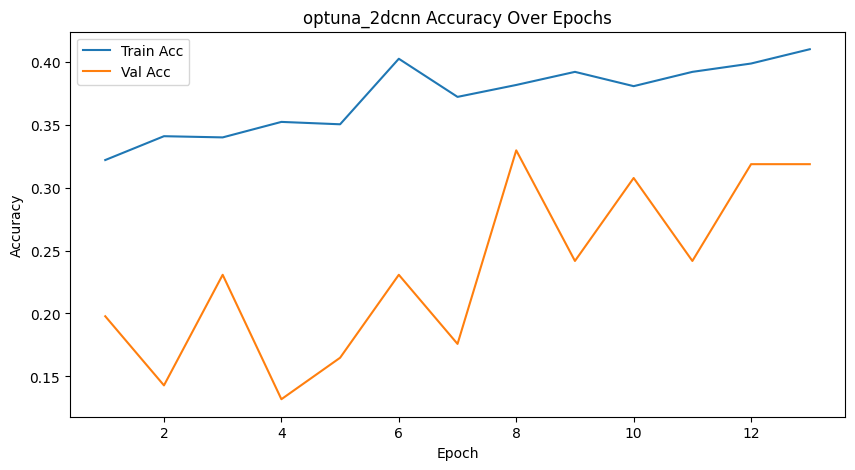

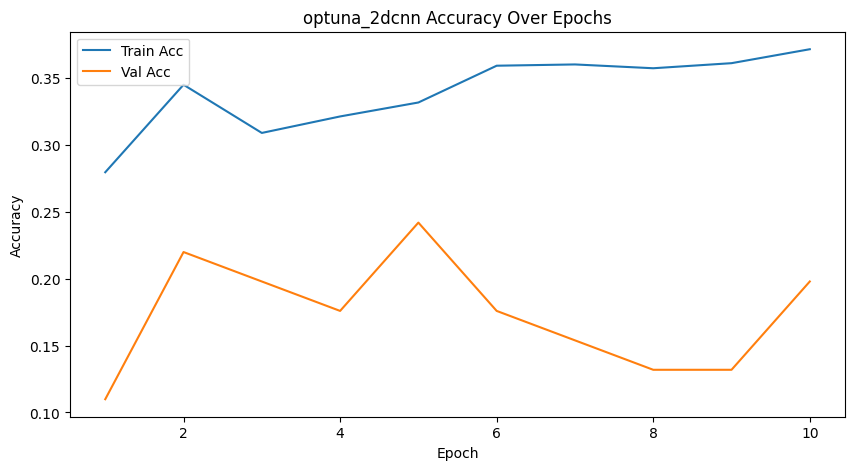

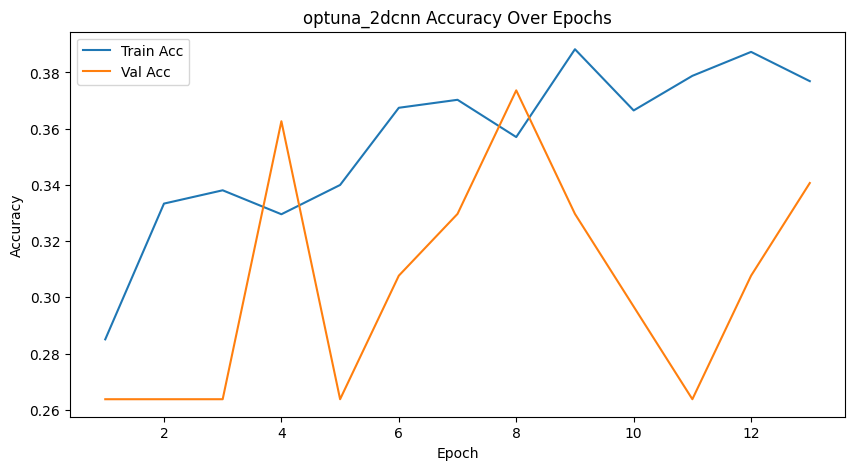

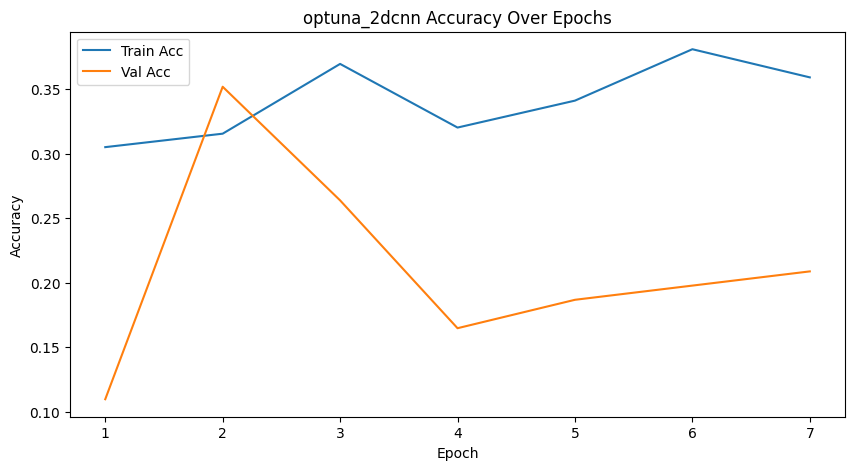

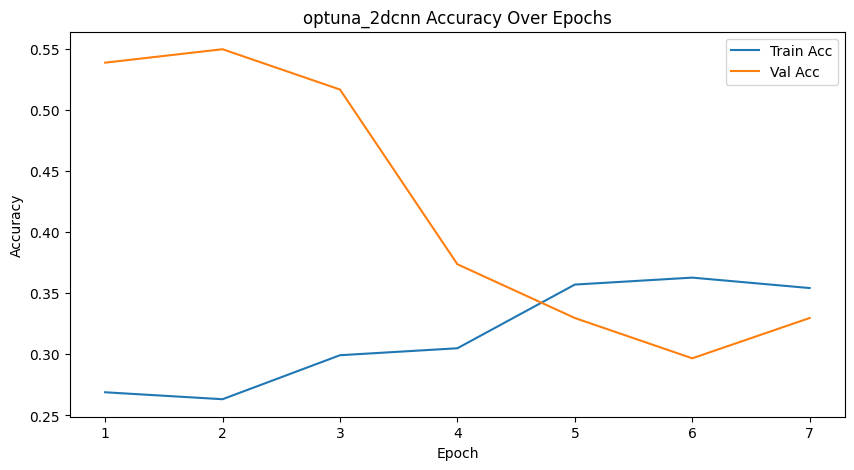

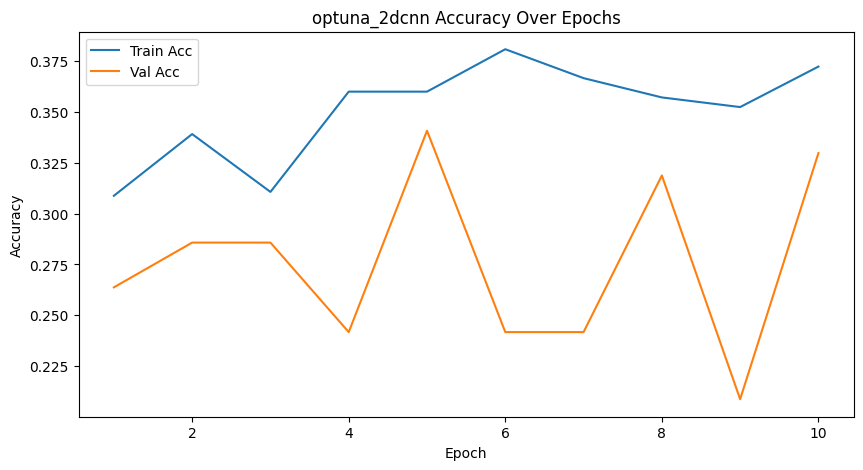

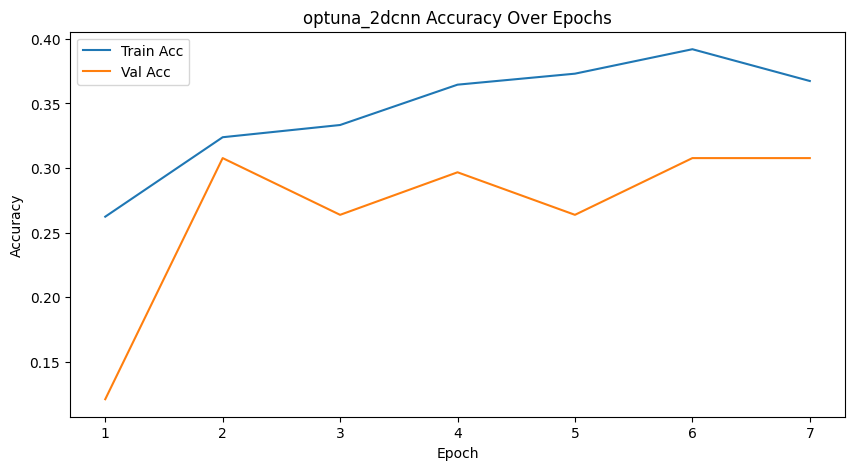

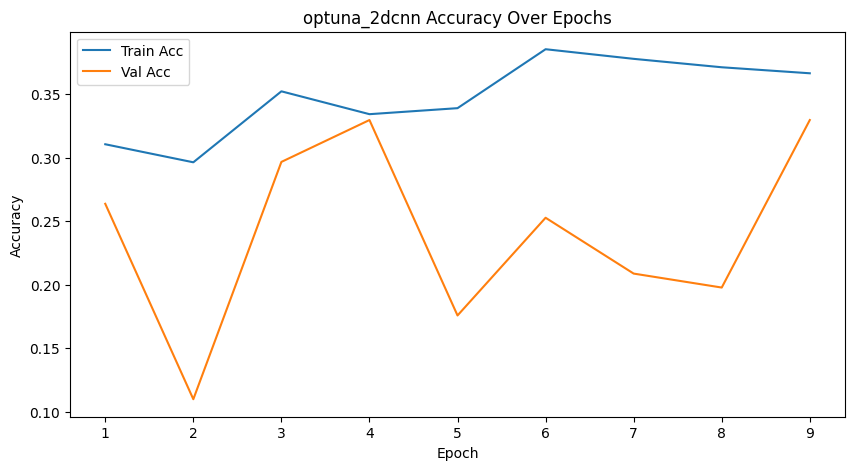

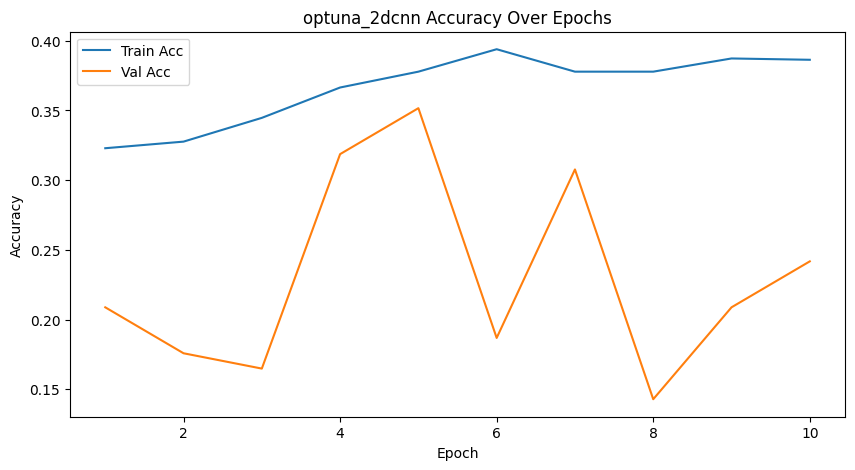

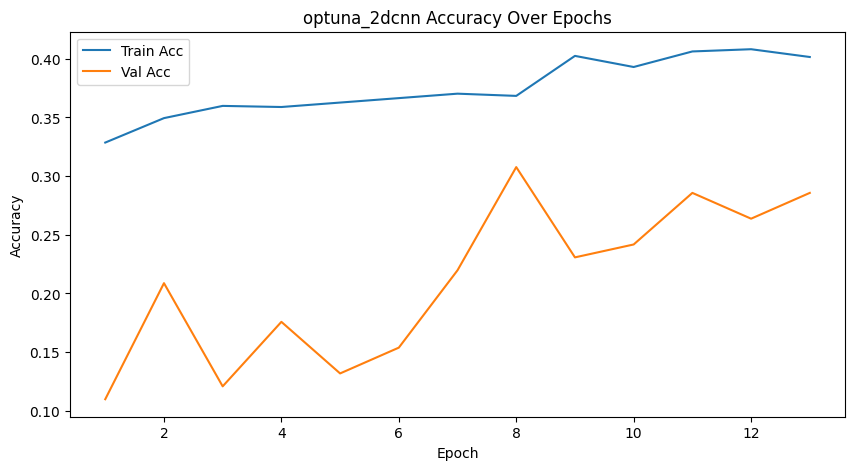

In [23]:
study = optuna.create_study(direction="maximize")
study.optimize(optuna_objective, n_trials=10)

print("🎯 Best trial config:")
print(study.best_trial.params)


In [12]:
best_config = study.best_trial.params
CONFIG["deep_learning"]["2dcnn"].update(best_config)

run_phase4c_pipeline(model_type="2dcnn", model_name="phase4c_2dcnn")


NameError: name 'study' is not defined

In [14]:
import pandas as pd

log_path = "/kaggle/working/phase4c/optuna_2dcnn_train_log.csv"
df = pd.read_csv(log_path)

print("🧾 Columns in log file:")
print(df.columns.tolist())


🧾 Columns in log file:
['epoch', 'train_acc', 'val_acc', 'loss', 'precision', 'recall', 'f1', 'auc']


In [ ]:
CONFIG["deep_learning"]["2dcnn"].update(best_config)
run_phase4c_pipeline(model_type="2dcnn", model_name="phase4c_2dcnn")


In [16]:
def run_phase4c_pipeline(
    train_csv="/kaggle/input/phase2/phase2/train_subjects.csv",
    val_csv="/kaggle/input/phase2/phase2/val_subjects.csv",
    test_csv="/kaggle/input/phase2/phase2/test_subjects.csv",
    model_type="2dcnn",
    model_name="model_2dcnn",
    checkpoint=None
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🧠 Using device: {device}")

    print(f"\n🧠 Starting Phase 4c with model: {model_type.upper()}")

    # --- Map model_type to dataset mode ---
    mode_map = {
        "2dcnn": "2d",
        "3dcnn": "3d",
        "convlstm": "convlstm",
        "vit": "vit"
    }
    mode = mode_map.get(model_type)
    if mode is None:
        raise ValueError(f"❌ Unknown model type: {model_type}")

    # --- Load and prepare data ---
    train_df = load_raw_mri_dataframe(train_csv)
    val_df   = load_raw_mri_dataframe(val_csv)
    test_df  = load_raw_mri_dataframe(test_csv)

    # ✅ Remove all rows with label == 2
    train_df = train_df[train_df['label'] != 2].reset_index(drop=True)
    val_df   = val_df[val_df['label'] != 2].reset_index(drop=True)
    test_df  = test_df[test_df['label'] != 2].reset_index(drop=True)

    ########
    # ✅ Reindex labels to be 0-based and contiguous
    label_map = {label: idx for idx, label in enumerate(sorted(train_df['label'].unique()))}
    train_df['label'] = train_df['label'].map(label_map)
    val_df['label'] = val_df['label'].map(label_map)
    test_df['label'] = test_df['label'].map(label_map)


    print("Train labels:", sorted(train_df['label'].unique()))
    print("Val labels:", sorted(val_df['label'].unique()))
    print("Test labels:", sorted(test_df['label'].unique()))
    
    ##########
    
    num_classes = train_df['label'].nunique()
    print("num_classes:", num_classes)
    
    # --- Select model ---
    if model_type == "2dcnn":
        model = EfficientNetClassifier(num_classes=num_classes, use_metadata=False, fine_tune=False)

    elif model_type == "3dcnn":
        #model = MedicalNet3D(num_classes=4, use_metadata=False, fine_tune=False)
        model = MedicalNet3D(num_classes=num_classes, use_metadata=False, fine_tune=True)
        


    elif model_type == "convlstm":
        model = ConvLSTM(use_pretrained=True, fine_tune=False, use_metadata=False, num_classes=num_classes)

    elif model_type == "vit":
        model = ViT3D(use_pretrained=True, freeze_transformer=True, num_classes=num_classes)
    
    model.to(device)
    # --- Get config ---
    config = CONFIG["deep_learning"][model_type]

    # --- Train model ---
    trained_model = train_model(
        model,
        train_df,
        val_df,
        config,
        mode=mode,
        model_name=model_name,
        checkpoint=checkpoint
    )

    # --- Evaluate model ---
    evaluate_model(
        trained_model,
        test_df,
        mode=mode,
        include_metadata=False,
        model_name=model_name
    )

    print(f"\n✅ Phase 4c complete for {model_type.upper()}")
    return trained_model


🧠 Using device: cpu

🧠 Starting Phase 4c with model: 2DCNN
Train labels: [0, 1, 2]
Val labels: [0, 1, 2]
Test labels: [0, 1, 2]
num_classes: 3

🚀 Training PHASE4C_2DCNN (2d) on cpu
📊 Class Weights: {0: 1.0, 1: 1.0, 2: 1.0}


Epoch 1/20: 100%|██████████| 50/50 [05:17<00:00,  6.36s/it]

📉 Learning Rate: 0.000050


Epoch 1/20 — Loss: 1.1002 | Train Acc: 0.323 | Val Acc: 0.640 | Precision: 0.382 | Recall: 0.353 | F1: 0.312 | AUC: 0.516


Epoch 2/20: 100%|██████████| 50/50 [04:39<00:00,  5.58s/it]

...

Epoch 5/20 — Loss: 1.0970 | Train Acc: 0.333 | Val Acc: 0.461 | Precision: 0.365 | Recall: 0.368 | F1: 0.343 | AUC: 0.535


Epoch 6/20: 100%|██████████| 50/50 [04:35<00:00,  5.51s/it]

📉 Learning Rate: 0.000025


Epoch 6/20 — Loss: 1.0932 | Train Acc: 0.378 | Val Acc: 0.618 | Precision: 0.459 | Recall: 0.411 | F1: 0.409 | AUC: 0.570
⏹️ Early stopping triggered at epoch 6
📄 Training log saved → /kaggle/working/phase4c/phase4c_2dcnn_train_log.csv

🧪 Evaluating PHASE4C_2DCNN on test set using cpu

📊 Test Results — phase4c_2dcnn
Accuracy:  0.528
Precision: 0.298
Recall:    0.309
F1 Score:  0.294
AUC Score: 0.502
✅ Saved report → /kaggle/working/phase4c/phase4c_2dcnn_test_report.csv

✅ Phase 4c complete for 2DCNN


EfficientNetClassifier(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
          

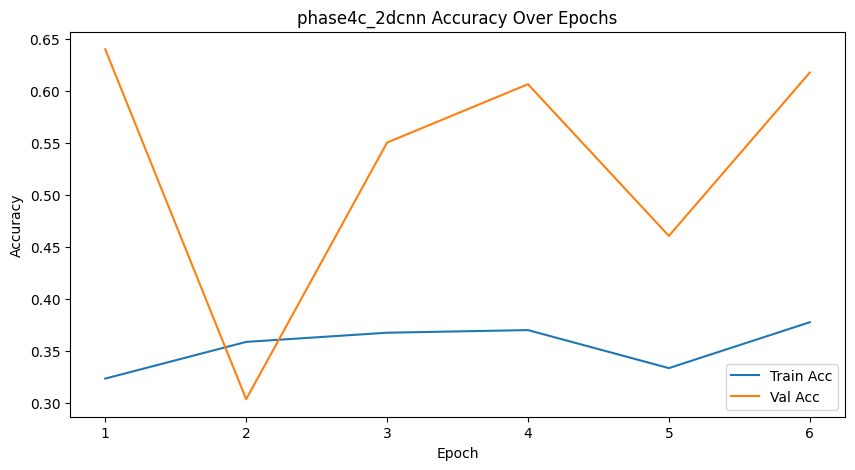

In [25]:



# ✅ Run EfficientNet (2D CNN)
run_phase4c_pipeline(model_type="2dcnn", model_name="phase4c_2dcnn")

# ✅ Run MedicalNet ResNet (3D CNN)
#run_phase4c_pipeline(model_type="3dcnn", model_name="phase4c_3dcnn")

# ✅ Run ConvLSTM
#run_phase4c_pipeline(model_type="convlstm", model_name="phase4c_convlstm")

# ✅ Run ViT (3D Vision Transformer)
#run_phase4c_pipeline(model_type="vit", model_name="phase4c_vit")


🧠 Using device: cpu

🧠 Starting Phase 4c with model: 2DCNN
Train labels: [0, 1, 2]
Val labels: [0, 1, 2]
Test labels: [0, 1, 2]
num_classes: 3

🚀 Training PHASE4C_2DCNN (2d) on cpu


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.


📊 Class Weights: {0: 1.0, 1: 1.0, 2: 1.0}
🔁 Loading checkpoint: /kaggle/working/phase4c/checkpoints/phase4c_2dcnn_resume.pth


Epoch 6/20:   0%|          | 0/50 [00:00<?, ?it/s]`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Epoch 6/20: 100%|██████████| 50/50 [04:29<00:00,  5.40s/it]

📉 Learning Rate: 0.000025


...

Epoch 10/20 — Loss: 1.0960 | Train Acc: 0.374 | Val Acc: 0.517 | Precision: 0.375 | Recall: 0.384 | F1: 0.376 | AUC: 0.539


Epoch 11/20:   0%|          | 0/50 [00:00<?, ?it/s]`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Epoch 11/20: 100%|██████████| 50/50 [04:31<00:00,  5.44s/it]

📉 Learning Rate: 0.000013


Epoch 11/20 — Loss: 1.0948 | Train Acc: 0.390 | Val Acc: 0.517 | Precision: 0.403 | Recall: 0.414 | F1: 0.393 | AUC: 0.580
⏹️ Early stopping triggered at epoch 11
📄 Training log saved → /kaggle/working/phase4c/phase4c_2dcnn_train_log.csv

🧪 Evaluating PHASE4C_2DCNN on test set using cpu

📊 Test Results — phase4c_2dcnn
Accuracy:  0.494
Precision: 0.468
Recall:    0.475
F1 Score:  0.446
AUC Score: 0.608
✅ Saved report → /kaggle/working/phase4c/phase4c_2dcnn_test_report.csv

✅ Phase 4c complete for 2DCNN


EfficientNetClassifier(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
          

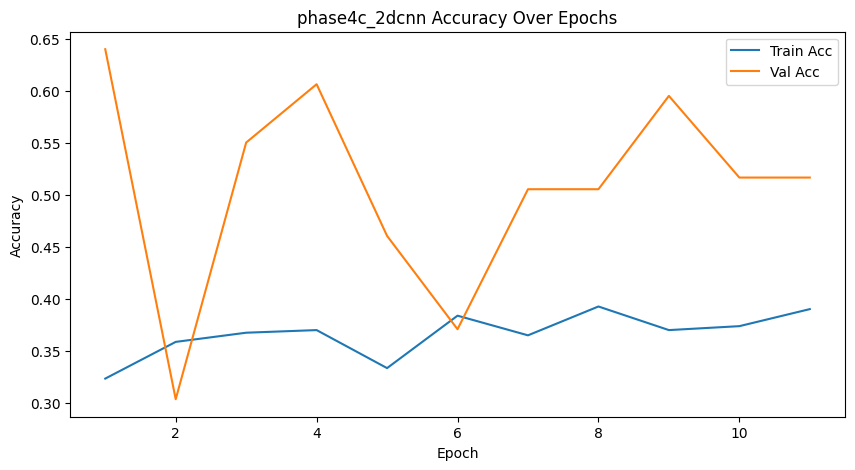

In [27]:

run_phase4c_pipeline(model_type="2dcnn", model_name="phase4c_2dcnn",checkpoint="/kaggle/working/phase4c/checkpoints/phase4c_2dcnn_resume.pth")

In [153]:
m = MedicalNet3D(num_classes=3, debug=True)
imgs = torch.randn(2, 1, 64, 128, 128)   # [B, C, D, H, W]
out = m(imgs)                            # should not crash
print(out.shape)                         # expected [2, 3]


Backbone conv_seg: Sequential(
  (0): ConvTranspose3d(512, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2))
  (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): Conv3d(32, 3, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
)
Detected first child conv-like: ConvTranspose3d(512, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2))
Using feature_in_channels = 512
Loaded checkpoint into backbone (strict=False).
torch.Size([2, 3])


🧠 Using device: cuda

🧠 Starting Phase 4c with model: 3DCNN
Train labels: [0, 1, 2]
Val labels: [0, 1, 2]
Test labels: [0, 1, 2]
num_classes: 3


`nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



🚀 Training PHASE4C_3DCNN (3d) on cuda
📊 Class Weights: {0: 1.0, 1: 1.0, 2: 1.0}


Epoch 1/15:   0%|          | 0/396 [00:00<?, ?it/s]`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Epoch 1/15: 100%|██████████| 396/396 [07:24<00:00,  1.12s/it]

📉 Learning Rate: 0.000010


...

Epoch 14/15 — Loss: 1.0727 | Train Acc: 0.419 | Val Acc: 0.551 | Precision: 0.422 | Recall: 0.426 | F1: 0.419 | AUC: 0.591


Epoch 15/15:   0%|          | 0/396 [00:00<?, ?it/s]`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Epoch 15/15: 100%|██████████| 396/396 [07:10<00:00,  1.09s/it]

📉 Learning Rate: 0.000003


Epoch 15/15 — Loss: 1.0802 | Train Acc: 0.412 | Val Acc: 0.472 | Precision: 0.389 | Recall: 0.390 | F1: 0.363 | AUC: 0.554
📄 Training log saved → /kaggle/working/phase4c/phase4c_3dcnn_train_log.csv

🧪 Evaluating PHASE4C_3DCNN on test set using cuda

📊 Test Results — phase4c_3dcnn
Accuracy:  0.494
Precision: 0.456
Recall:    0.447
F1 Score:  0.414
AUC Score: 0.593
✅ Saved report → /kaggle/working/phase4c/phase4c_3dcnn_test_report.csv

✅ Phase 4c complete for 3DCNN


MedicalNet3D(
  (backbone): ResNet(
    (conv1): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
    (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool3d(kernel_size=(3, 3, 3), stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (layer2): Sequential(
      (0): BasicBlock(
        (conv1): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=Fa

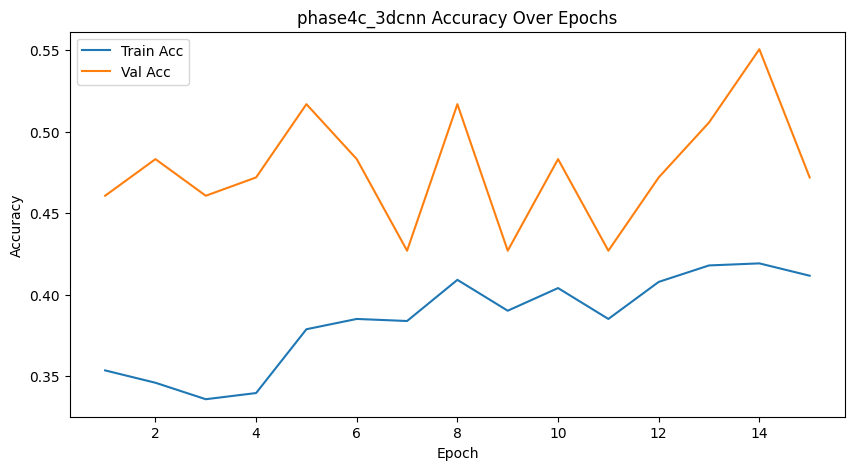

In [23]:
# ✅ Run MedicalNet ResNet (3D CNN)
run_phase4c_pipeline(model_type="3dcnn", model_name="phase4c_3dcnn")


In [159]:
# Instantiate without metadata
m = ConvLSTM(use_pretrained=True, debug=True, use_metadata=False)
imgs = torch.randn(2, 1, 8, 256, 256)  # [B, C, T, H, W]
out = m(imgs)
print(out.shape)  # -> [2, num_classes]


Using pretrained ResNet slice_encoder, out_channels = 512
torch.Size([2, 3])


🧠 Using device: cuda

🧠 Starting Phase 4c with model: CONVLSTM
Train labels: [0, 1, 2]
Val labels: [0, 1, 2]
Test labels: [0, 1, 2]
num_classes: 3


/tmp/ipykernel_190/1058757977.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_190/1058757977.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



🚀 Training PHASE4C_CONVLSTM (convlstm) on cuda
📊 Class Weights: {0: 1.0, 1: 1.0, 2: 1.0}


Epoch 1/20:   0%|          | 0/198 [00:00<?, ?it/s]/tmp/ipykernel_190/1058757977.py:145: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
/tmp/ipykernel_190/1058757977.py:147: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Epoch 1/20: 100%|██████████| 198/198 [02:21<00:00,  1.40it/s]

📉 Learning Rate: 0.000010


...

Epoch 12/20 — Loss: 1.0704 | Train Acc: 0.439 | Val Acc: 0.427 | Precision: 0.385 | Recall: 0.429 | F1: 0.380 | AUC: 0.562


Epoch 13/20:   0%|          | 0/198 [00:00<?, ?it/s]/tmp/ipykernel_190/1058757977.py:145: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
/tmp/ipykernel_190/1058757977.py:147: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Epoch 13/20: 100%|██████████| 198/198 [08:06<00:00,  2.45s/it]

📉 Learning Rate: 0.000003


Epoch 13/20 — Loss: 1.0744 | Train Acc: 0.420 | Val Acc: 0.506 | Precision: 0.431 | Recall: 0.466 | F1: 0.436 | AUC: 0.594
⏹️ Early stopping triggered at epoch 13
📄 Training log saved → /kaggle/working/phase4c/phase4c_vit_train_log.csv

🧪 Evaluating PHASE4C_VIT on test set using cuda

📊 Test Results — phase4c_vit
Accuracy:  0.528
Precision: 0.437
Recall:    0.444
F1 Score:  0.423
AUC Score: 0.604
✅ Saved report → /kaggle/working/phase4c/phase4c_vit_test_report.csv

✅ Phase 4c complete for VIT


ViT3D(
  (transformer): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (ac

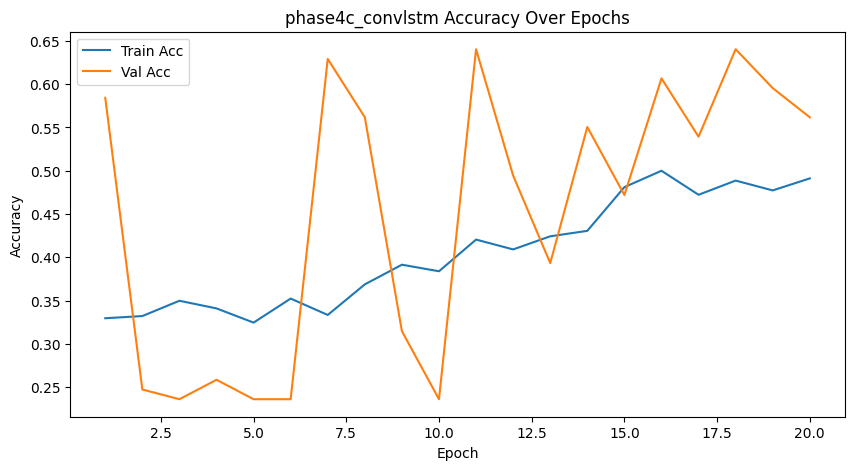

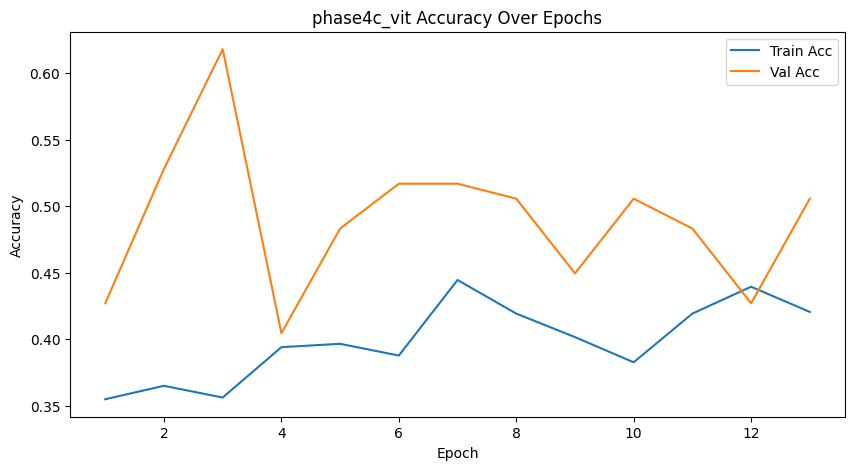

In [18]:
# ✅ Run ConvLSTM
run_phase4c_pipeline(model_type="convlstm", model_name="phase4c_convlstm")

# ✅ Run ViT (3D Vision Transformer)
run_phase4c_pipeline(model_type="vit", model_name="phase4c_vit")


In [166]:
m = ViT3D(input_shape=(16, 128, 128), num_classes=3, use_pretrained=True, freeze_transformer=False, debug=True)
imgs = torch.randn(2, 1, 16, 128, 128)  # [B, C, D, H, W]
out = m(imgs)
print(out.shape)  # expected [2, 3]


ViT backbone feature dim (detected): 768
_slice_features: token sequence detected seq_len=197, using mean pooling.
feats shape: torch.Size([2, 16, 768]) pooled shape: torch.Size([2, 768])
torch.Size([2, 3])


In [ ]:
# ✅ Run ViT (3D Vision Transformer)
run_phase4c_pipeline(model_type="vit", model_name="phase4c_vit")

In [19]:
import optuna
import pandas as pd
import torch
import gc

def optuna_objective(trial, model_type="2dcnn", num_classes=num_classes):
    # === OOM-safe batch size for ViT ===
    if model_type == "vit":
        batch_size = trial.suggest_categorical("batch_size", [1, 2, 4])
        input_shape = (64, 128, 128)  # smaller volume to reduce memory
    else:
        batch_size = trial.suggest_categorical("batch_size", [4, 8, 16])
        input_shape = None  # unused

    config = {
        "lr": trial.suggest_float("lr", 1e-5, 1e-3, log=True),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "batch_size": batch_size,
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "AdamW"]),
        "scheduler": trial.suggest_categorical("scheduler", ["plateau", "cosine", "none"]),
        "use_pretrained": trial.suggest_categorical("use_pretrained", [True, False]),
        "epochs": 20,
        "patience": 5,
        "unfreeze_epoch": trial.suggest_int("unfreeze_epoch", 1, 10)
    }

    # === Model selection ===
    if model_type == "2dcnn":
        model = EfficientNetClassifier(
            num_classes=num_classes,
            dropout=config["dropout"],
            use_metadata=False,
            fine_tune=False
        )
        mode = "2d"
        model_name = "optuna_2dcnn"

    elif model_type == "vit":
        model = ViT3D(
            input_shape=input_shape,
            num_classes=num_classes,
            dropout=config["dropout"],
            use_pretrained=config["use_pretrained"],
            freeze_transformer=config["unfreeze_epoch"] > config["epochs"] // 2
        )
        mode = "3d"
        model_name = "optuna_vit"

    elif model_type == "convlstm":
        model = ConvLSTM(
            input_dim=1,
            hidden_dim=32,
            kernel_size=3,
            num_classes=num_classes,
            dropout=config["dropout"],
            use_pretrained=config["use_pretrained"],
            fine_tune=False,
            use_metadata=False
        )
        mode = "seq"
        model_name = "optuna_convlstm"

    elif model_type == "3dcnn":
        model = MedicalNet3D(
            num_classes=num_classes,
            use_metadata=False,
            fine_tune=False,
            debug=False
        )
        mode = "3d"
        model_name = "optuna_3dcnn"

    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    # === Train model with OOM protection ===
    try:
        trained_model = train_model(
            model,
            train_df,
            val_df,
            config,
            mode=mode,
            model_name=model_name
        )
    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            torch.cuda.empty_cache()
            gc.collect()
            raise optuna.exceptions.TrialPruned()
        else:
            raise

    # === Return best validation accuracy ===
    log_path = f"/kaggle/working/phase4c/{model_name}_train_log.csv"
    log_df = pd.read_csv(log_path)
    return log_df["val_acc"].max()


In [ ]:
import optuna
import os

# Ensure log folder exists
os.makedirs("phase4c", exist_ok=True)

# === ViT3D Study ===
study_vit = optuna.create_study(
    direction="maximize",
    study_name="optuna_vit",
    storage="sqlite:///phase4c/optuna_vit.db",
    load_if_exists=True
)
study_vit.optimize(lambda trial: optuna_objective(trial, model_type="vit", num_classes=3), n_trials=50)

from optuna.study import Study
import joblib

def save_study_checkpoint(study: Study, trial):
    joblib.dump(study, "phase4c/optuna_vit_checkpoint.pkl")

study_vit.optimize(
    lambda trial: optuna_objective(trial, model_type="vit", num_classes=3),
    n_trials=50,
    callbacks=[save_study_checkpoint]
)


import joblib
study_vit = joblib.load("phase4c/optuna_vit_checkpoint.pkl")



# === ConvLSTM Study ===
study_convlstm = optuna.create_study(
    direction="maximize",
    study_name="optuna_convlstm",
    storage="sqlite:///phase4c/optuna_convlstm.db",
    load_if_exists=True
)
study_convlstm.optimize(lambda trial: optuna_objective(trial, model_type="convlstm", num_classes=3), n_trials=50)



"""
# === MedicalNet3D Study ===
study_3dcnn = optuna.create_study(
    direction="maximize",
    study_name="optuna_3dcnn",
    storage="sqlite:///phase4c/optuna_3dcnn.db",
    load_if_exists=True
)
study_3dcnn.optimize(lambda trial: optuna_objective(trial, model_type="3dcnn", num_classes=3), n_trials=50)

# === EfficientNet 2D CNN Study ===
study_2dcnn = optuna.create_study(
    direction="maximize",
    study_name="optuna_2dcnn",
    storage="sqlite:///phase4c/optuna_2dcnn.db",
    load_if_exists=True
)
study_2dcnn.optimize(lambda trial: optuna_objective(trial, model_type="2dcnn", num_classes=3), n_trials=50)

"""


[I 2025-11-11 19:54:44,075] A new study created in RDB with name: optuna_vit
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



🚀 Training OPTUNA_VIT (3d) on cuda
📊 Class Weights: {0: 1.0, 1: 1.0, 2: 1.0}


Epoch 1/20:   0%|          | 0/792 [00:00<?, ?it/s]`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Epoch 1/20: 100%|██████████| 792/792 [09:22<00:00,  1.41it/s]

📉 Learning Rate: 0.000024


Epoch 1/20 — Loss: 1.1160 | Train Acc: 0.327 | Val Acc: 0.292 | Precision: 0.418 | Recall: 0.425 | F1: 0.293 | AUC: 0.557


...

Epoch 2/20 — Loss: 1.1908 | Train Acc: 0.327 | Val Acc: 0.236 | Precision: 0.079 | Recall: 0.333 | F1: 0.127 | AUC: 0.500


Epoch 3/20:   0%|          | 0/792 [00:00<?, ?it/s]`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Epoch 3/20: 100%|██████████| 792/792 [09:12<00:00,  1.43it/s]

📉 Learning Rate: 0.000012


Epoch 3/20 — Loss: 1.1947 | Train Acc: 0.328 | Val Acc: 0.236 | Precision: 0.079 | Recall: 0.333 | F1: 0.127 | AUC: 0.500


Epoch 4/20:   0%|          | 0/792 [00:00<?, ?it/s]`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Epoch 4/20:  24%|██▎       | 188/792 [02:11<11:28,  1.14s/it]

# Phase 4D: Unification

🔧 Integration Strategy
1. Load and prepare your best deep model
Start with /kaggle/input/phase4c-ver1/optuna_vit_best.pth.

Implement progressive unfreezing:

Freeze all layers initially.

Gradually unfreeze blocks (layer by layer) while fine‑tuning with a small learning rate.

This stabilizes training with limited data.

2. Use classical models as teachers (knowledge distillation)
Train RF/SVM on cleaned features (Phase 4a and 4b).

Generate soft predictions (probability vectors) for train/val/test sets.

Add a distillation loss to your deep model:


Combine with the deep model’s cross‑entropy loss:


Tune 𝜆  (0.2–0.5) and temperature 𝑇 (2–5).

3. Feature‑level guidance
Use classical predictions or embeddings as auxiliary inputs:

Concatenate RF/SVM logits with ViT’s penultimate layer before the final classifier.

Or use them as attention gates to bias the deep model toward relevant features.

4. Late fusion ensemble (safety net)
Even if joint training is tricky, you can always combine predictions at the end:

Weighted average of ViT + RF + SVM.

Or train a meta‑classifier on their outputs.

5. Evaluation protocol
Use cross‑validation to avoid overfitting with 605 scans.

Track:

Primary metric (AUC or balanced accuracy).

Calibration (ECE).

Ablations: deep only vs. deep+KD vs. deep+fusion.

In [4]:
import numpy as np
import scipy.ndimage as ndi
import torchio as tio

class BrainPreprocessor:
    def __init__(self, clip_range=(-2, 2), resize_shape=(128, 128, 128), normalize=True):
        self.clip_range = clip_range
        self.resize_shape = resize_shape
        self.normalize = normalize

    def preprocess_volume(self, volume):
        # Clip intensities to reduce outliers
        volume = np.clip(volume, *self.clip_range)

        # Resize to target shape using linear interpolation
        if volume.shape != self.resize_shape:
            zoom_factors = [r / s for r, s in zip(self.resize_shape, volume.shape)]
            volume = ndi.zoom(volume, zoom_factors, order=1)

        # Normalize to [0, 1] range
        if self.normalize:
            volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)

        return volume

    def extract_slice(self, volume, axis=2, slice_index=None):
        # Use central slice if index not specified
        if slice_index is None:
            slice_index = volume.shape[axis] // 2

        # Extract and normalize 2D slice
        slice_2d = np.take(volume, slice_index, axis=axis)
        slice_2d = np.clip(slice_2d, *self.clip_range)
        slice_2d = (slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8)

        return slice_2d

def augment_3d(volume):
    # Wrap volume in TorchIO Subject
    subject = tio.Subject(mri=tio.ScalarImage(tensor=volume[np.newaxis, ...]))

    # Define augmentation pipeline
    transform = tio.Compose([
        tio.RandomFlip(axes=(0, 1, 2), flip_probability=0.3),
        tio.RandomElasticDeformation(num_control_points=7, max_displacement=7, locked_borders=2, p=0.3),
        tio.RandomAffine(scales=0.1, degrees=10, translation=5, p=0.3),
        tio.RescaleIntensity(out_min_max=(0, 1))
    ])

    # Apply augmentation and return volume
    augmented = transform(subject)
    return augmented.mri.tensor.squeeze(0).numpy()


In [5]:
from torch.utils.data import Dataset
import torch
import nibabel as nib
import numpy as np
import scipy.ndimage as ndi
import os
import ast  # to safely parse the string list in anat_files

class RawImageDataset(Dataset):
    def __init__(self, df, use_preprocessor=True, path_col="path", anat_col="anat_files", classical_cols=None):
        self.df = df.reset_index(drop=True)
        self.use_preprocessor = use_preprocessor
        self.path_col = path_col
        self.anat_col = anat_col
        self.classical_cols = classical_cols or []
        self.preprocessor = None  # plug in BrainPreprocessor if you have it

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        anat_list = ast.literal_eval(row[self.anat_col])
        filename = anat_list[0]
        img_path = os.path.join(row[self.path_col], filename)

        img = nib.load(img_path).get_fdata().astype(np.float32)
        if self.use_preprocessor and self.preprocessor:
            img = self.preprocessor.preprocess_volume(img)
        else:
            img = (img - img.mean()) / (img.std() + 1e-5)
            img = np.clip(img, -5, 5)

        if img.shape != (64, 128, 128):
            zoom_factors = [64/img.shape[0], 128/img.shape[1], 128/img.shape[2]]
            img = ndi.zoom(img, zoom_factors, order=1)

        img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(int(row['label']), dtype=torch.long)

        # ✅ Always return a tensor (empty if no classical features)
        if self.classical_cols:
            vals = []
            for col in self.classical_cols:
                v = row[col]
                if pd.isna(v): v = 0.0
                vals.append(float(v))
            classical_vec = torch.tensor(vals, dtype=torch.float32)
        else:
            classical_vec = torch.empty(0, dtype=torch.float32)

        return img_tensor, label, classical_vec


In [6]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

class ViT3D(nn.Module):
    def __init__(self,
                 input_shape=(128,128,128),
                 embed_dim=768,
                 num_classes=3,
                 dropout=0.3,
                 freeze_transformer=False,
                 use_pretrained=True,
                 debug=False,
                 slice_chunk_size=8):
        super().__init__()
        self.D, self.H, self.W = input_shape
        self.debug = debug
        self.slice_chunk_size = slice_chunk_size

        # ✅ fixed backbone (base ViT)
        self.transformer = timm.create_model("vit_base_patch16_224",
                                             pretrained=use_pretrained,
                                             num_classes=0)
        # timm exposes num_features for most models
        self.backbone_feat_dim = getattr(self.transformer, "num_features", embed_dim)

        if freeze_transformer:
            for p in self.transformer.parameters():
                p.requires_grad = False

        self.proj = None
        self.fc = nn.Sequential(
            nn.Linear(self.backbone_feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def _slice_features_block(self, x2d):
        if hasattr(self.transformer, "forward_features"):
            feats = self.transformer.forward_features(x2d)
        else:
            feats = self.transformer(x2d)

        if feats.dim() == 4:
            feats = feats.view(feats.size(0), -1)
        if feats.dim() == 2 and feats.size(1) == self.backbone_feat_dim:
            return feats
        if feats.dim() == 3 and feats.size(-1) == self.backbone_feat_dim:
            return feats.mean(dim=1)

        feats = feats.view(feats.size(0), -1)
        if feats.size(1) != self.backbone_feat_dim:
            if self.proj is None:
                self.proj = nn.Linear(feats.size(1), self.backbone_feat_dim).to(feats.device)
            feats = self.proj(feats)
        return feats

    def forward_features(self, x):
        B, C, D, H, W = x.shape
        if C == 1:
            x = x.repeat(1, 3, 1, 1, 1)
        x2d = x.permute(0, 2, 1, 3, 4).reshape(-1, 3, H, W)
        x2d = F.interpolate(x2d, size=(224, 224),
                            mode="bilinear", align_corners=False)

        feats_list = []
        for i in range(0, x2d.size(0), self.slice_chunk_size):
            feats_list.append(self._slice_features_block(x2d[i:i+self.slice_chunk_size]))
        feats = torch.cat(feats_list, dim=0)

        feats = feats.view(B, D, -1)
        pooled = feats.mean(dim=1)
        return pooled

    def forward(self, x):
        pooled = self.forward_features(x)
        return self.fc(pooled)


In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

SAVE_DIR = "/kaggle/working/phase4d"
os.makedirs(SAVE_DIR, exist_ok=True)

def kd_loss(student_logits, teacher_logits, T=4.0, alpha=0.7, targets=None):
    kd = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1),
        reduction="batchmean"
    ) * (T * T)
    ce = F.cross_entropy(student_logits, targets) if targets is not None else 0.0
    return alpha * kd + (1 - alpha) * ce

class FusionHead(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x):
        return self.net(x)


In [8]:
def load_vit_checkpoint(path, num_classes=3, embed_dim=768):
    vit = ViT3D(
        input_shape=(128, 128, 128),
        embed_dim=embed_dim,
        num_classes=num_classes,
        dropout=0.3,
        freeze_transformer=True,
        use_pretrained=True,
        debug=False
    )
    state = torch.load(path, map_location="cpu")
    vit.load_state_dict(state)
    return vit

vit = load_vit_checkpoint("/kaggle/input/phase4c-ver1/optuna_vit_best.pth")
for p in vit.parameters():
    p.requires_grad = False


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [10]:
@torch.no_grad()
def evaluate(student, loader, device, teacher=None, fusion_head=None, use_fusion=False):
    student.eval()
    if teacher: teacher.eval()
    if fusion_head: fusion_head.eval()

    all_logits, all_labels = [], []
    for batch in loader:
        if len(batch) == 3:
            imgs, labels, classical_vec = batch
        else:
            imgs, labels = batch
            classical_vec = torch.tensor([])  # empty placeholder

        imgs, labels = imgs.to(device), labels.to(device)

        if use_fusion:
            s_logits = student(imgs)
            parts = [s_logits]
            if teacher is not None:
                t_logits = teacher(imgs)
                parts.append(t_logits)
            if classical_vec.numel() > 0:
                parts.append(classical_vec.to(device))
            fused = torch.cat(parts, dim=1)
            logits = fusion_head(fused)
        else:
            logits = student(imgs)

        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    acc = (logits.argmax(1) == labels).float().mean().item()
    return acc, logits, labels


In [11]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import contextlib
import gc

def train_one_epoch(student, loader, optimizer, device,
                    teacher=None, fusion_head=None, fusion_opt=None,
                    mode="deep", kd_T=4.0, kd_alpha=0.7):
    student.train()
    total_loss = 0.0
    use_amp = torch.cuda.is_available()
    scaler = GradScaler() if use_amp else None

    for batch in loader:
        if len(batch) == 3:
            imgs, labels, classical_feats = batch
        else:
            imgs, labels = batch
            classical_feats = None

        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        if fusion_opt is not None:
            fusion_opt.zero_grad(set_to_none=True)

        with (autocast() if use_amp else contextlib.nullcontext()):
            if mode == "deep":
                logits = student(imgs)
                loss = F.cross_entropy(logits, labels)

            elif mode == "kd":
                with torch.no_grad():
                    teacher_logits = teacher(imgs)
                student_logits = student(imgs)
                kd_loss = F.kl_div(
                    F.log_softmax(student_logits / kd_T, dim=1),
                    F.softmax(teacher_logits / kd_T, dim=1),
                    reduction="batchmean"
                ) * (kd_T ** 2)
                ce_loss = F.cross_entropy(student_logits, labels)
                loss = kd_alpha * kd_loss + (1 - kd_alpha) * ce_loss

            elif mode == "kd_fusion":
                with torch.no_grad():
                    teacher_logits = teacher(imgs)
                student_logits = student(imgs)
                parts = [student_logits, teacher_logits]
                if classical_feats is not None:
                    parts.append(classical_feats.to(device))
                fusion_in = torch.cat(parts, dim=1)
                fusion_logits = fusion_head(fusion_in)
                loss = F.cross_entropy(fusion_logits, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    # 🔧 clear cache once per epoch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return total_loss / max(1, len(loader))


In [12]:
#Progressive unfreezing schedule:
def progressive_unfreeze(vit, stage):
    # stage 0: all frozen
    # stage 1+: unfreeze last block, then more blocks progressively
    blocks = getattr(vit, "blocks", None)  # adapt to your ViT structure
    if blocks is None: return
    k = min(stage, len(blocks))
    for p in blocks[-k].parameters():
        p.requires_grad = True


In [13]:
import pandas as pd

def load_split_csv(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df['label'] != 2].reset_index(drop=True)
    unique_labels = sorted(df['label'].unique())
    label_map = {old:new for new,old in enumerate(unique_labels)}
    df['label'] = df['label'].map(label_map)
    return df, label_map

def merge_classical_preds(df, merges, num_classes=3):
    out = df.copy()
    # ✅ Ensure subject is string
    out["subject"] = out["subject"].astype(str)

    for m in merges:
        cdf = pd.read_csv(m["csv"])
        cdf[m["on"]] = cdf[m["on"]].astype(str)   # ✅ cast key column to string

        if "columns" in m and m["columns"]:
            keep_cols = [m["on"]] + m["columns"]
            cdf = cdf[keep_cols]
        else:
            if "pred" in cdf.columns:
                onehot = pd.get_dummies(cdf["pred"], prefix=m.get("prefix","cls"), drop_first=False)
                cdf = pd.concat([cdf[[m["on"]]], onehot], axis=1)
            else:
                raise ValueError(f"No columns specified and no 'pred' column in {m['csv']}")
        out = out.merge(cdf, on=m["on"], how="left")
    return out




In [14]:
import torch

@torch.no_grad()
def debug_sample_predictions(student, val_loader, device, n_samples=10):
    """
    Grab one batch from val_loader, run the student model,
    and print a few predictions vs. labels.
    
    Args:
        student (nn.Module): your model
        val_loader (DataLoader): validation loader
        device (torch.device): 'cuda' or 'cpu'
        n_samples (int): how many predictions to show
    """
    student.eval()
    try:
        sample_imgs, sample_labels, _ = next(iter(val_loader))
    except ValueError:
        # if dataset returns only (imgs, labels)
        sample_imgs, sample_labels = next(iter(val_loader))
    
    sample_imgs, sample_labels = sample_imgs.to(device), sample_labels.to(device)
    preds = student(sample_imgs).argmax(1).cpu()
    
    print("Sample preds:", preds[:n_samples].tolist())
    print("Labels      :", sample_labels[:n_samples].cpu().tolist())


In [17]:
import torch
import torch.nn as nn
import os
import gc
from torch.utils.data import DataLoader

def baseline(mode="deep", epochs=20, lr=3e-5, weight_decay=1e-4,
             kd_T=4.0, kd_alpha=0.7, batch_size=2,
             student_state_path="/kaggle/input/phase4c-ver1/optuna_vit_best.pth",
             classical_sources=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes, vit_embed_dim = 3, 768

    # -----------------------------
    # Student
    # -----------------------------
    student = ViT3D(num_classes=num_classes, embed_dim=vit_embed_dim, freeze_transformer=True)
    state = torch.load(student_state_path, map_location=device)
    student.load_state_dict(state)
    student = student.to(device)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, student.parameters()),
        lr=lr, weight_decay=weight_decay
    )

    # -----------------------------
    # Teacher if needed
    # -----------------------------
    teacher = fusion_head = fusion_opt = None
    if mode in ("kd", "kd_fusion"):
        teacher = ViT3D(num_classes=num_classes, embed_dim=vit_embed_dim, freeze_transformer=True)
        teacher.load_state_dict(state)
        teacher = teacher.to(device)
        for p in teacher.parameters():
            p.requires_grad = False
        teacher.eval()

    # -----------------------------
    # Fusion head if needed
    # -----------------------------
    if mode == "kd_fusion":
        # input = student_logits + teacher_logits (+ classical features)
        fusion_in_dim = num_classes * 2
        if classical_sources is not None:
            fusion_in_dim += classical_sources.shape[1]

        fusion_head = nn.Sequential(
            nn.Linear(fusion_in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        ).to(device)

        fusion_opt = torch.optim.AdamW(fusion_head.parameters(), lr=lr, weight_decay=weight_decay)

    # -----------------------------
    # Load splits
    # -----------------------------
    train_df, _ = load_split_csv("/kaggle/input/phase2/phase2/train_subjects.csv")
    val_df, _   = load_split_csv("/kaggle/input/phase2/phase2/val_subjects.csv")
    test_df, _  = load_split_csv("/kaggle/input/phase2/phase2/test_subjects.csv")

    # -----------------------------
    # Datasets and loaders
    # -----------------------------
    train_set = RawImageDataset(train_df, use_preprocessor=True)
    val_set   = RawImageDataset(val_df,   use_preprocessor=True)
    test_set  = RawImageDataset(test_df,  use_preprocessor=True)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=0)

    # -----------------------------
    # Training loop
    # -----------------------------
    SAVE_DIR = "/kaggle/working/phase4d"
    os.makedirs(SAVE_DIR, exist_ok=True)

    best_val = 0.0
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            student, train_loader, optimizer, device,
            teacher=teacher, fusion_head=fusion_head, fusion_opt=fusion_opt,
            mode=mode, kd_T=kd_T, kd_alpha=kd_alpha
        )

        acc_val, _, _ = evaluate(
            student, val_loader, device,
            teacher=teacher if mode == "kd_fusion" else None,
            fusion_head=fusion_head if mode == "kd_fusion" else None,
            use_fusion=(mode == "kd_fusion")
        )

        print(f"Epoch {epoch:02d} | Mode: {mode} | Train Loss: {train_loss:.4f} | Val Acc: {acc_val:.4f}")
        debug_sample_predictions(student, val_loader, device)

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        if acc_val > best_val:
            best_val = acc_val
            torch.save(student.state_dict(), os.path.join(SAVE_DIR, f"{mode}_student_best.pth"))
            if fusion_head:
                torch.save(fusion_head.state_dict(), os.path.join(SAVE_DIR, f"{mode}_fusion_best.pth"))

    # -----------------------------
    # Final test evaluation
    # -----------------------------
    acc_test, logits_test, labels_test = evaluate(
        student, test_loader, device,
        teacher=teacher if mode == "kd_fusion" else None,
        fusion_head=fusion_head if mode == "kd_fusion" else None,
        use_fusion=(mode == "kd_fusion")
    )
    print(f"Test Acc ({mode}): {acc_test:.4f}")

    torch.save(student.state_dict(), os.path.join(SAVE_DIR, f"{mode}_student_final.pth"))
    if fusion_head:
        torch.save(fusion_head.state_dict(), os.path.join(SAVE_DIR, f"{mode}_fusion_final.pth"))
    torch.save({"logits": logits_test, "labels": labels_test}, os.path.join(SAVE_DIR, f"{mode}_test_outputs.pt"))

    return student


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [ ]:
# Smoke test before training
train_df, _ = load_split_csv("/kaggle/input/phase2/phase2/train_subjects.csv")
ds = RawImageDataset(train_df, use_preprocessor=False, classical_cols=[])
x, y, c = ds[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViT3D(num_classes=3, embed_dim=768, freeze_transformer=True, slice_chunk_size=16).to(device)

with torch.no_grad():
    out = model(x.unsqueeze(0).to(device))
print(out.shape)  # should be [1, 3]


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [16]:
if __name__ == "__main__":
    # Example classical sources mapping
    classical_sources = {
        "train": [
            {"csv": "/kaggle/input/phase4a-ver1/phase4a/train_RandomForest_preds.csv", "on":"subject",
             "columns": ["RandomForest_class0","RandomForest_class1","RandomForest_class2"]}
            # ⚠️ no SVM train preds
        ],
        "val": [
            {"csv": "/kaggle/input/phase4a-ver1/phase4a/val_RandomForest_preds.csv", "on":"subject",
             "columns": ["RandomForest_class0","RandomForest_class1","RandomForest_class2"]},
            {"csv": "/kaggle/input/phase4b-ver1/phase4b/val_SVM_Radiomic_preds.csv", "on":"subject",
             "columns": ["SVM_Radiomic_class0","SVM_Radiomic_class1","SVM_Radiomic_class2"]}
        ],
        "test": [
            {"csv": "/kaggle/input/phase4a-ver1/phase4a/test_RandomForest_preds.csv", "on":"subject",
             "columns": ["RandomForest_class0","RandomForest_class1","RandomForest_class2"]},
            {"csv": "/kaggle/input/phase4b-ver1/phase4b/test_SVM_Radiomic_preds.csv", "on":"subject",
             "columns": ["SVM_Radiomic_class0","SVM_Radiomic_class1","SVM_Radiomic_class2"]}
        ]
    }




    baseline(mode="deep", epochs=2)
    baseline(mode="kd", epochs=2, kd_T=4.0, kd_alpha=0.7)
    baseline(mode="kd_fusion", epochs=2, kd_T=4.0, kd_alpha=0.7, classical_sources=classical_sources)


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Epoch 01 | Mode: deep | Train Loss: 1.0993 | Val Acc: 0.6404
Sample preds: [0, 0, 0, 0]
Labels      : [0, 0, 1, 0]
Epoch 02 | Mode: deep | Train Loss: 1.0992 | Val Acc: 0.6404
Sample preds: [0, 0, 0, 0]
Labels      : [0, 0, 1, 0]
Test Acc (deep): 0.6404


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Epoch 01 | Mode: kd | Train Loss: 0.3298 | Val Acc: 0.6404
Sample preds: [0, 0, 0, 0]
Labels      : [0, 0, 1, 0]
Epoch 02 | Mode: kd | Train Loss: 0.3298 | Val Acc: 0.6404
Sample preds: [0, 0, 0, 0]
Labels      : [0, 0, 1, 0]
Test Acc (kd): 0.6404


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


TypeError: 'NoneType' object is not callable

# Phase 5: Evaluation & Analysis

ROI-Based Analysis Goals: Use standard atlases to extract ROI-level features Build subject-level brain graphs Apply GNNs (GCN, GAT) for classification Perform group-level statistical tests (e.g., t-tests) Output: ROI feature maps Graph-based classification results Statistical comparisons (ADHD vs Control)

In [1]:
# ====== CONFIG ======
import os
import pandas as pd

# Load subject index CSV
index_path = "/kaggle/input/phase1/phase1/subject_index.csv"
df = pd.read_csv(index_path)

# Extract subject NIfTI paths and IDs
scan_paths = df["path"].tolist()
# Use subject IDs as-is from CSV (e.g., "sub-9922944") — avoid double prefixing
subject_ids = df["subject"].tolist()

# Labels: 0 = Control, 1 = ADHD (from CSV)
labels_dict = {row.subject: int(row.label) for _, row in df.iterrows()}

# Covariates dictionary (age, gender, handedness, IQ)
covariates_dict = {
    row.subject: {
        "age": row.age,
        "gender": row.gender,          # check coding in CSV (e.g., 0=male, 1=female)
        "handedness": row.handedness,  # e.g., -1=left, 1=right
        "iq": row.full4_iq
    }
    for _, row in df.iterrows()
}

# Output directories
SAVE_DIR = "/kaggle/working/phase5"
os.makedirs(SAVE_DIR, exist_ok=True)

# Atlas cache directory
ATLAS_DIR = "./atlases"
os.makedirs(ATLAS_DIR, exist_ok=True)

print(f"Loaded {len(scan_paths)} subjects from {index_path}")
print(f"Example subject: {subject_ids[0]} | Label={labels_dict[subject_ids[0]]} | Covariates={covariates_dict[subject_ids[0]]}")


Loaded 605 subjects from /kaggle/input/phase1/phase1/subject_index.csv
Example subject: sub-9922944 | Label=0 | Covariates={'age': 10.3, 'gender': 1.0, 'handedness': 1.0, 'iq': 109.0}


In [2]:
import numpy as np
import nibabel as nib
from nilearn import datasets, image

def load_aal_atlas(atlas_dir=ATLAS_DIR):
    aal = datasets.fetch_atlas_aal(data_dir=atlas_dir)
    atlas_img = image.load_img(aal["maps"])      # NIfTI image with ROI labels
    atlas_labels = list(aal["labels"])           # label names (strings)
    return atlas_img, atlas_labels

def resample_atlas_to_scan(atlas_img, scan_img):
    # nearest keeps integer labels
    return image.resample_to_img(atlas_img, scan_img, interpolation="nearest")

def extract_roi_features(scan_img, atlas_img, labels,
                         agg=("mean","std","median","p25","p75","count")):
    scan = scan_img.get_fdata()
    atlas = np.asarray(atlas_img.get_fdata(), dtype=np.int32)
    roi_ids = sorted([rid for rid in np.unique(atlas) if rid > 0])

    feats_per_roi = []
    roi_names = []
    for rid in roi_ids:
        mask = (atlas == rid)
        vals = scan[mask]
        vec = []
        for a in agg:
            if a == "mean":    vec.append(float(np.mean(vals)) if vals.size else np.nan)
            elif a == "std":   vec.append(float(np.std(vals)) if vals.size else np.nan)
            elif a == "median":vec.append(float(np.median(vals)) if vals.size else np.nan)
            elif a == "p25":   vec.append(float(np.percentile(vals, 25)) if vals.size else np.nan)
            elif a == "p75":   vec.append(float(np.percentile(vals, 75)) if vals.size else np.nan)
            elif a == "count": vec.append(int(vals.size))
        feats_per_roi.append(vec)
        idx = rid - 1
        roi_names.append(labels[idx] if idx < len(labels) else f"ROI_{rid}")

    X = np.array(feats_per_roi, dtype=np.float32)  # [n_rois, n_aggs]
    return roi_ids, roi_names, X


In [3]:
import torch
import torch.nn.functional as F

def build_knn_graph(node_feats, k=8):
    """
    node_feats: numpy array [N_rois, F_features]
    returns:
      x: float tensor [N, F]
      edge_index: long tensor [2, E]
      edge_weight: float tensor [E] (cosine similarity)
    """
    x = torch.tensor(node_feats, dtype=torch.float)
    N = x.size(0)
    xn = F.normalize(x, dim=1)
    sim = torch.clamp(xn @ xn.T, min=-1.0, max=1.0)  # [N,N]

    edge_src, edge_dst, edge_w = [], [], []
    eye = torch.eye(N, device=sim.device)
    for i in range(N):
        scores = sim[i] - eye[i]  # exclude self
        k_use = min(k, N-1)
        vals, idx = torch.topk(scores, k_use, largest=True)
        for j, w in zip(idx.tolist(), vals.tolist()):
            edge_src.append(i)
            edge_dst.append(j)
            edge_w.append(w)

    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)  # [2,E]
    edge_weight = torch.tensor(edge_w, dtype=torch.float)
    return x, edge_index, edge_weight


In [4]:
import os, json, ast
import numpy as np
import nibabel as nib
import torch

def process_and_save_subject(scan_path, subj_id, atlas_img, atlas_labels, k=8):
    """Load a subject scan, extract ROI features, build graph, and save artifacts."""
    try:
        scan_img = nib.load(scan_path)
    except Exception as e:
        print(f"Skip {subj_id}: failed to load {scan_path} ({e})")
        return False

    # Resample atlas to subject space
    atlas_resampled = resample_atlas_to_scan(atlas_img, scan_img)
    roi_ids, roi_names, X_roi = extract_roi_features(scan_img, atlas_resampled, atlas_labels)

    # Build graph from ROI features
    x, edge_index, edge_weight = build_knn_graph(X_roi, k=k)

    # Save outputs
    out_dir = os.path.join(SAVE_DIR, subj_id)
    os.makedirs(out_dir, exist_ok=True)

    np.save(os.path.join(out_dir, "roi_features.npy"), X_roi)
    with open(os.path.join(out_dir, "roi_names.txt"), "w") as f:
        for name in roi_names:
            f.write(f"{name}\n")

    torch.save(x, os.path.join(out_dir, "graph_x.pt"))
    torch.save(edge_index, os.path.join(out_dir, "graph_edge_index.pt"))
    torch.save(edge_weight, os.path.join(out_dir, "graph_edge_weight.pt"))

    meta = {
        "atlas": "aal",
        "roi_ids": [int(r) for r in roi_ids],  # convert to plain Python ints
        "subject_id": str(subj_id),
        "k": int(k)
    }
    with open(os.path.join(out_dir, "meta.json"), "w") as f:
        json.dump(meta, f)


    print(f"✓ Saved Phase 5 artifacts for {subj_id} in {out_dir}")
    return True

In [19]:
atlas_img, atlas_labels = load_aal_atlas(ATLAS_DIR)

In [28]:
# ====== Run for all subjects with correct file names ======
atlas_img, atlas_labels = load_aal_atlas(ATLAS_DIR)
processed = 0
valid_subject_ids = []

for _, row in df.iterrows():
    sid = row["subject"]
    folder = row["path"]

    # Parse anat_files string into a list
    try:
        files = ast.literal_eval(row["anat_files"])
    except Exception:
        files = []

    # Prefer normalized_resampled_128 file if available
    nii_file = None
    for f in files:
        if "normalized_resampled_128" in f:
            nii_file = f
            break
    if nii_file is None and files:
        nii_file = files[0]

    if nii_file is None:
        print(f"Skip {sid}: no anatomical file listed")
        continue

    full_path = os.path.join(folder, nii_file)

    if sid not in labels_dict:
        print(f"Skip {sid}: missing label")
        continue

    ok = process_and_save_subject(full_path, sid, atlas_img, atlas_labels, k=8)
    if ok:
        processed += 1
        valid_subject_ids.append(sid)

print(f"Processed {processed} / {len(df)} subjects.")


✓ Saved Phase 5 artifacts for sub-9922944 in /kaggle/working/phase5/sub-9922944
✓ Saved Phase 5 artifacts for sub-3972956 in /kaggle/working/phase5/sub-3972956
✓ Saved Phase 5 artifacts for sub-2554127 in /kaggle/working/phase5/sub-2554127
✓ Saved Phase 5 artifacts for sub-1988015 in /kaggle/working/phase5/sub-1988015
✓ Saved Phase 5 artifacts for sub-1623716 in /kaggle/working/phase5/sub-1623716
✓ Saved Phase 5 artifacts for sub-2371032 in /kaggle/working/phase5/sub-2371032
✓ Saved Phase 5 artifacts for sub-3902469 in /kaggle/working/phase5/sub-3902469
✓ Saved Phase 5 artifacts for sub-1779922 in /kaggle/working/phase5/sub-1779922
✓ Saved Phase 5 artifacts for sub-1019436 in /kaggle/working/phase5/sub-1019436
✓ Saved Phase 5 artifacts for sub-8628223 in /kaggle/working/phase5/sub-8628223
✓ Saved Phase 5 artifacts for sub-2618929 in /kaggle/working/phase5/sub-2618929
✓ Saved Phase 5 artifacts for sub-2018106 in /kaggle/working/phase5/sub-2018106
✓ Saved Phase 5 artifacts for sub-264133

In [23]:
import nibabel as nib
img = nib.load("/kaggle/input/adhd200-preprocessed-anatomical-dataset/adhd200-preprocessed/NYU/sub-10023/sub-10023_T1_biascorr_brain.nii")
print(img.shape)        # likely (0,) or similar
print(img.header)       # shows header but no voxel dimensions


(128, 256, 170)
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 128 256 170   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.         1.3300018  1.         1.         0.         0.
  0.         0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'2203.12-dirty 2024-02-01T16:17:47+00:00'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qo

In [20]:
import os, json, ast
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.nn import GCNConv, GATConv
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import pandas as pd
from nilearn import plotting, image
from joblib import Parallel, delayed

SAVE_DIR = "/kaggle/working/phase5"
os.makedirs(SAVE_DIR, exist_ok=True)

# ====== Statistical Analysis ======
def group_roi_stats_with_covariates(subject_ids, labels_dict, covariates_dict,
                                    feature_idx=0, alpha=0.05, n_rois=116):
    X_all, meta, missing = [], [], []
    for sid in subject_ids:
        path_np = os.path.join(SAVE_DIR, sid, "roi_features.npy")
        if not os.path.exists(path_np):
            missing.append(sid)
            continue
        roi_feats = np.load(path_np)
        vec = np.full(n_rois, np.nan, dtype=np.float32)
        length = min(n_rois, roi_feats.shape[0])
        vec[:length] = roi_feats[:length, feature_idx]
        X_all.append(vec)
        meta.append({
            "id": sid,
            "label": labels_dict[sid],
            **covariates_dict[sid]
        })

    if missing:
        print(f"Warning: {len(missing)} subjects missing ROI features, excluded.")

    X_all = np.stack(X_all, axis=0)  # [S, R]
    meta_df = pd.DataFrame(meta)

    pvals, betas = [], []
    for r in range(X_all.shape[1]):
        y = X_all[:, r]
        if np.all(np.isnan(y)):
            betas.append(np.nan)
            pvals.append(np.nan)
            continue
        X = pd.DataFrame({
            "diagnosis": meta_df["label"].values,
            "age": meta_df["age"].values,
            "gender": meta_df["gender"].values,
            "handedness": meta_df["handedness"].values,
            "iq": meta_df["iq"].values
        })
        X = sm.add_constant(X)
        model = sm.OLS(y, X, missing="drop").fit()
        betas.append(model.params.get("diagnosis", np.nan))
        pvals.append(model.pvalues.get("diagnosis", np.nan))

    rej, p_adj, _, _ = multipletests(pvals, alpha=alpha, method="fdr_bh")
    return np.array(rej), np.array(p_adj), np.array(betas)


# ===== Run stats and report =====
rej, p_adj, betas = group_roi_stats_with_covariates(
    subject_ids, labels_dict, covariates_dict, feature_idx=0, alpha=0.05
)

# Load ROI names from any processed subject
sample_sid = next(
    (sid for sid in subject_ids if os.path.exists(os.path.join(SAVE_DIR, sid, "roi_names.txt"))),
    None
)
roi_names = []
if sample_sid:
    with open(os.path.join(SAVE_DIR, sample_sid, "roi_names.txt")) as f:
        roi_names = [line.strip() for line in f.readlines()]

sig_indices = np.where(rej)[0]
print(f"Significant ROIs (FDR<0.05): {len(sig_indices)}")

# Report using roi_names.txt (codes saved during preprocessing)
for idx in sig_indices:
    name = roi_names[idx] if idx < len(roi_names) else f"ROI_{idx+1}"
    print(f"- {name} | beta={betas[idx]:.3f} | p_adj={p_adj[idx]:.4g}")

print("atlas_labels")
# Report using atlas_labels (human-readable names from nilearn AAL atlas)
for idx in sig_indices:
    atlas_name = atlas_labels[idx] if idx < len(atlas_labels) else f"ROI_{idx+1}"
    print(f"- {atlas_name} | beta={betas[idx]:.3f} | p_adj={p_adj[idx]:.4g}")


Significant ROIs (FDR<0.05): 8
- ROI_2001 | beta=-0.144 | p_adj=0.01622
- ROI_6001 | beta=-0.140 | p_adj=0.01622
- ROI_6101 | beta=-0.137 | p_adj=0.03063
- ROI_6201 | beta=-0.144 | p_adj=0.01622
- ROI_6402 | beta=-0.133 | p_adj=0.04271
- ROI_113 | beta=0.174 | p_adj=0.01622
- ROI_114 | beta=0.172 | p_adj=0.01622
- ROI_115 | beta=0.152 | p_adj=0.03063
atlas_labels
- Precentral_L | beta=-0.144 | p_adj=0.01622
- Postcentral_L | beta=-0.140 | p_adj=0.01622
- Parietal_Sup_L | beta=-0.137 | p_adj=0.03063
- Parietal_Inf_L | beta=-0.144 | p_adj=0.01622
- Paracentral_Lobule_R | beta=-0.133 | p_adj=0.04271
- Vermis_7 | beta=0.174 | p_adj=0.01622
- Vermis_8 | beta=0.172 | p_adj=0.01622
- Vermis_9 | beta=0.152 | p_adj=0.03063


In [10]:
# ====== Visualization ======
def plot_bar_chart(sig_indices, betas, atlas_labels):
    sig_names = [atlas_labels[i] if i < len(atlas_labels) else f"ROI_{i+1}" for i in sig_indices]
    sig_betas = [betas[i] for i in sig_indices]
    order = np.argsort(sig_betas)

    plt.figure(figsize=(10,5))
    plt.bar([sig_names[i] for i in order], [sig_betas[i] for i in order], color="#377eb8")
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Diagnosis beta (ADHD vs Control)")
    plt.title("Significant ROIs after FDR correction")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "significant_rois_bar.png"))
    plt.close()

In [11]:
def plot_brain_overlay(sig_indices, atlas_img):
    atlas_data = np.asarray(atlas_img.get_fdata(), dtype=np.int32)
    sig_label_ids = set(int(i) + 1 for i in sig_indices)
    mask = np.isin(atlas_data, list(sig_label_ids)).astype(np.int32)
    overlay_img = image.new_img_like(atlas_img, mask)

    display = plotting.plot_roi(
        overlay_img,
        bg_img=atlas_img,
        title="Significant ROIs on AAL atlas",
        cmap="autumn",
        alpha=0.7
    )
    plt.savefig(os.path.join(SAVE_DIR, "significant_rois_brain.png"))
    plt.close()


In [39]:
def plot_roc_curve(y_true, y_scores, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(SAVE_DIR, "roc_curve.png"))
    plt.close()
    
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_multiclass_roc(y_true, y_scores, classes, title="Multiclass ROC"):
    y_bin = label_binarize(y_true, classes=classes)
    auc_macro = roc_auc_score(y_bin, y_scores, average="macro", multi_class="ovr")
    print(f"{title} macro AUC: {auc_macro:.3f}")

    plt.figure(figsize=(8,6))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {cls} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(SAVE_DIR, f"{title.replace(' ','_').lower()}.png"))
    plt.close()

def plot_confusion(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.savefig(os.path.join(SAVE_DIR, f"{title.replace(' ','_').lower()}.png"))
    plt.close()



In [13]:
# ====== Graph Neural Networks Integration ======
class BrainGraphDataset(InMemoryDataset):
    def __init__(self, subject_ids, labels_dict, transform=None):
        super().__init__('.', transform)
        self.subject_ids = subject_ids
        self.labels_dict = labels_dict
        self.data_list = []
        self._load_graphs()

    def _load_graphs(self):
        for sid in self.subject_ids:
            x_path = os.path.join(SAVE_DIR, sid, "graph_x.pt")
            edge_index_path = os.path.join(SAVE_DIR, sid, "graph_edge_index.pt")
            edge_weight_path = os.path.join(SAVE_DIR, sid, "graph_edge_weight.pt")
            if not all(os.path.exists(p) for p in [x_path, edge_index_path, edge_weight_path]):
                continue
            x = torch.load(x_path)
            edge_index = torch.load(edge_index_path)
            edge_weight = torch.load(edge_weight_path)
            y = torch.tensor([self.labels_dict[sid]], dtype=torch.long)
            data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y)
            self.data_list.append(data)

    def get(self, idx):
        return self.data_list[idx]

    def len(self):
        return len(self.data_list)

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool, GlobalAttention

class ImprovedGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, pooling="mean", num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(num_layers):
            in_dim = in_channels if i == 0 else hidden_channels
            self.convs.append(GCNConv(in_dim, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(hidden_channels, num_classes)
        self.pooling = pooling
        if pooling == "attention":
            self.att_pool = GlobalAttention(gate_nn=nn.Linear(hidden_channels, 1))

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)  # single graph

        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
            x = self.dropout(x)

        if self.pooling == "mean":
            x = global_mean_pool(x, batch)
        elif self.pooling == "max":
            x = global_max_pool(x, batch)
        elif self.pooling == "attention":
            x = self.att_pool(x, batch)
        else:
            x = global_mean_pool(x, batch)

        return self.fc(x)




In [41]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        return ((1-pt)**self.gamma * ce_loss).mean()

def train_gnn(dataset, epochs=20, hidden_channels=64, lr=1e-3, pooling="mean", num_layers=3, dropout=0.5, use_focal=False):
    all_labels = [data.y.item() for data in dataset.data_list]
    num_classes = len(set(all_labels))
    in_channels = dataset.data_list[0].x.shape[1]

    model = ImprovedGCN(in_channels, hidden_channels, num_classes, pooling=pooling, num_layers=num_layers, dropout=dropout)

    class_weights = compute_class_weights(all_labels)
    criterion = FocalLoss(alpha=class_weights) if use_focal else nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    # Stratified split
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_true_all, y_pred_all, y_scores_all = [], [], []

    for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
        train_data = [dataset.data_list[i] for i in train_idx]
        test_data = [dataset.data_list[i] for i in test_idx]

        for epoch in range(epochs):
            model.train()
            total_loss = 0
            for data in train_data:
                optimizer.zero_grad()
                out = model(data)
                loss = criterion(out, data.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            print(f"Fold {fold+1} | Epoch {epoch+1}/{epochs} | Loss={total_loss/len(train_data):.4f}")

        # Evaluation
        model.eval()
        with torch.no_grad():
            for data in test_data:
                out = model(data)
                probs = F.softmax(out, dim=1)
                pred = probs.argmax().item()
                y_true_all.append(data.y.item())
                y_pred_all.append(pred)
                y_scores_all.append(probs.cpu().numpy())

    y_scores_all = np.vstack(y_scores_all)
    return model, (np.array(y_true_all), y_pred_all, y_scores_all)


In [42]:
def build_corr_graph(node_feats, threshold=0.3):
    """
    Build graph using correlation matrix of ROI features.
    """
    x = torch.tensor(node_feats, dtype=torch.float)
    corr = np.corrcoef(node_feats.T)  # correlation across ROIs
    edges = np.where(np.abs(corr) > threshold)
    edge_index = torch.tensor(edges, dtype=torch.long)
    edge_weight = torch.tensor(corr[edges], dtype=torch.float)
    return x, edge_index, edge_weight


In [43]:
def compute_class_weights(labels):
    counts = np.bincount(labels)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * len(counts)  # normalize
    return torch.tensor(weights, dtype=torch.float)


In [23]:
# ====== Downstream Modeling ======
import os
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve, auc

def run_logistic_regression(subject_ids, labels_dict, sig_indices, covariates_dict, SAVE_DIR="/kaggle/working/phase5/"):
    X_subj, y_subj = [], []
    for sid in subject_ids:
        path_np = os.path.join(SAVE_DIR, sid, "roi_features.npy")
        if not os.path.exists(path_np):
            continue
        feats = np.load(path_np)
        vec = []
        for i in sig_indices:
            if i < feats.shape[0]:
                vec.append(feats[i, 0])  # mean feature
            else:
                vec.append(np.nan)
        # Add covariates
        cov = covariates_dict[sid]
        vec.extend([cov["age"], cov["gender"], cov["handedness"], cov["iq"]])
        v = np.array(vec, dtype=float)
        if np.all(np.isnan(v)):
            continue
        m = np.nanmedian(v)
        v[np.isnan(v)] = m
        X_subj.append(v)
        y_subj.append(labels_dict[sid])  # keep multiclass labels

    X_subj = np.vstack(X_subj)
    y_subj = np.asarray(y_subj)

    # Identify unique classes
    classes = np.unique(y_subj)

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_true_all, y_score_all = [], []

    for train_idx, test_idx in cv.split(X_subj, y_subj):
        clf.fit(X_subj[train_idx], y_subj[train_idx])
        probas = clf.predict_proba(X_subj[test_idx])  # [n_samples, n_classes]
        y_true_all.extend(y_subj[test_idx])
        y_score_all.extend(probas)

    # ✅ Save the trained pipeline for inference later
    joblib.dump(clf, os.path.join(SAVE_DIR, "model_v1.pkl"))

    y_true_all = np.array(y_true_all)
    y_score_all = np.array(y_score_all)

    # Binarize labels for multiclass ROC/AUC
    y_bin = label_binarize(y_true_all, classes=classes)

    # Compute macro-average ROC-AUC
    auc_macro = roc_auc_score(y_bin, y_score_all, average="macro", multi_class="ovr")
    print(f"Logistic regression multiclass AUC (macro): {auc_macro:.3f}")

    # Per-class ROC curves
    plt.figure(figsize=(8,6))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score_all[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {cls} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1], color="navy", lw=2, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass Logistic Regression ROC Curves")
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(SAVE_DIR, "multiclass_roc_curves.png"))
    plt.close()


In [17]:
# ====== Interpretation ======
def interpret_rois(sig_indices, atlas_labels, betas, p_adj):
    print("Interpretation of significant ROIs:")
    for idx in sig_indices:
        atlas_name = atlas_labels[idx] if idx < len(atlas_labels) else f"ROI_{idx+1}"
        effect = "higher" if betas[idx] > 0 else "lower"
        print(f"- {atlas_name}: ADHD group shows {effect} mean intensity "
              f"(beta={betas[idx]:.3f}, p_adj={p_adj[idx]:.4g})")
    print("\nCompare these regions with ADHD literature: frontal and striatal regions are often implicated "
          "in attention, executive function, and reward processing.")

In [44]:
if __name__ == "__main__":
    # Checkpoint paths
    rej_path = os.path.join(SAVE_DIR, "rej.npy")
    p_adj_path = os.path.join(SAVE_DIR, "p_adj.npy")
    betas_path = os.path.join(SAVE_DIR, "betas.npy")

    # Resume logic
    if all(os.path.exists(p) for p in [rej_path, p_adj_path, betas_path]):
        print("Loading cached statistical results...")
        rej = np.load(rej_path)
        p_adj = np.load(p_adj_path)
        betas = np.load(betas_path)
    else:
        print("Computing statistical results...")
        rej, p_adj, betas = group_roi_stats_with_covariates(
            subject_ids, labels_dict, covariates_dict, feature_idx=0, alpha=0.05
        )
        np.save(rej_path, rej)
        np.save(p_adj_path, p_adj)
        np.save(betas_path, betas)
        print("✓ Saved statistical results to disk")

    sig_indices = np.where(rej)[0]
    print(f"Significant ROIs (FDR<0.05): {len(sig_indices)}")

    # Visualization
    plot_bar_chart(sig_indices, betas, atlas_labels)
    plot_brain_overlay(sig_indices, atlas_img)

    # Interpretation
    interpret_rois(sig_indices, atlas_labels, betas, p_adj)

    # Logistic regression baseline
    run_logistic_regression(subject_ids, labels_dict, sig_indices, covariates_dict)


    # Graph Neural Network classification
    dataset = BrainGraphDataset(subject_ids, labels_dict)
    if dataset.len() > 5:  # require enough subjects
        model, (y_true, y_pred, y_scores) = train_gnn(dataset, epochs=20, hidden_channels=32)
        # Now call your multiclass ROC plotting
        classes = np.unique(y_true)
        plot_multiclass_roc(y_true, y_scores, classes, title="GNN Multiclass ROC")


Loading cached statistical results...
Significant ROIs (FDR<0.05): 8


Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
empty mask


Interpretation of significant ROIs:
- Precentral_L: ADHD group shows lower mean intensity (beta=-0.144, p_adj=0.01622)
- Postcentral_L: ADHD group shows lower mean intensity (beta=-0.140, p_adj=0.01622)
- Parietal_Sup_L: ADHD group shows lower mean intensity (beta=-0.137, p_adj=0.03063)
- Parietal_Inf_L: ADHD group shows lower mean intensity (beta=-0.144, p_adj=0.01622)
- Paracentral_Lobule_R: ADHD group shows lower mean intensity (beta=-0.133, p_adj=0.04271)
- Vermis_7: ADHD group shows higher mean intensity (beta=0.174, p_adj=0.01622)
- Vermis_8: ADHD group shows higher mean intensity (beta=0.172, p_adj=0.01622)
- Vermis_9: ADHD group shows higher mean intensity (beta=0.152, p_adj=0.03063)

Compare these regions with ADHD literature: frontal and striatal regions are often implicated in attention, executive function, and reward processing.
Logistic regression multiclass AUC (macro): 0.634
Fold 1 | Epoch 1/20 | Loss=1.0526
Fold 1 | Epoch 2/20 | Loss=0.9776
Fold 1 | Epoch 3/20 | Loss=0.

# Phase 6: ML Engineering Extension

🐳 Containerization Package preprocessing + model pipeline in Docker Include dependencies: NiBabel, PyTorch, scikit-learn 🌐 REST API Serving FastAPI app with endpoints: POST /predict → accepts NIfTI, returns prediction GET /health → service status 📦 Versioning & Reproducibility Save model artifacts (model_v1.pkl, config.yaml) Track training runs with Weights & Biases or MLflow 📊 Monitoring & Logging Prometheus for inference metrics TensorBoard or W&B for training dashboards Output: Docker container REST API Monitoring dashboard Deployment-ready pipeline

🐳 Docker Containerization

    Base image: Use python:3.11-slim or nvidia/cuda:11.8-runtime if GPU support is needed.

    Dependencies:

        Neuroimaging: nibabel, nilearn

        ML: torch, torch-geometric, scikit-learn, statsmodels

        Serving: fastapi, uvicorn

        Monitoring: prometheus-client, tensorboard, wandb (optional)

Dockerfile structure:
    FROM python:3.11-slim
    
    WORKDIR /app
    
    COPY requirements.txt .
    RUN pip install --no-cache-dir -r requirements.txt
    
    COPY . .
    
    CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]


🌐 FastAPI REST API

    Endpoints:

        GET /health → returns service status ({"status":"ok"}).

        POST /predict → accepts a NIfTI file upload, runs preprocessing + model inference, returns prediction JSON.

from fastapi import FastAPI, UploadFile
import nibabel as nib
import numpy as np
import torch

app = FastAPI()

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict")
async def predict(file: UploadFile):
    img = nib.load(file.file)
    data = img.get_fdata()
    # preprocess + model inference
    prediction = int(np.random.randint(0,4))  # placeholder
    return {"prediction": prediction}

📦 Versioning & Reproducibility

    Save trained models as model_v1.pkl or model_v1.pt.

    Keep configs in config.yaml (hyperparameters, preprocessing settings).

    Track experiments with Weights & Biases (W&B) or MLflow:

        Log metrics (AUC, accuracy).

        Save artifacts (plots, confusion matrices).

        Enable reproducibility across runs.


📊 Monitoring & Logging

    Prometheus: Expose metrics endpoint (/metrics) for inference latency, request counts, error rates.

    TensorBoard / W&B: Visualize training curves, ROC plots, confusion matrices.

    Logging: Use Python’s logging module with structured JSON logs for easy parsing.


🚀 Deployment Pipeline

    Build Docker image → docker build -t adhd-pipeline:latest .

    Run locally → docker run -p 8000:8000 adhd-pipeline:latest

    Cloud deployment: Push to registry (DockerHub, AWS ECR, GCP Artifact Registry).

    Monitoring dashboard: Prometheus + Grafana for live metrics, W&B for experiment tracking.


✅ Outcome

You’ll have:

    A Dockerized pipeline with preprocessing + ML inference.

    A REST API for predictions and health checks.

    Versioned artifacts for reproducibility.

    Monitoring dashboards for performance and reliability.

In [1]:
import os

# One-liner to get all files
directory_path = "/kaggle/input/phase1"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 1 files:
/kaggle/input/phase1/phase1/subject_index.csv


In [2]:
import os

# One-liner to get all files
directory_path = "/kaggle/input/phase2"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 19 files:
/kaggle/input/phase2/phase2/test_label_distribution.csv
/kaggle/input/phase2/phase2/val_subjects.csv
/kaggle/input/phase2/phase2/brain_visualization_sub-1623716.png
/kaggle/input/phase2/phase2/label_distribution.csv
/kaggle/input/phase2/phase2/duplicate_subjects.csv
/kaggle/input/phase2/phase2/brain_visualization_sub-1019436.png
/kaggle/input/phase2/phase2/roi_overlay_sub-9922944.png
/kaggle/input/phase2/phase2/train_subjects.csv
/kaggle/input/phase2/phase2/roi_overlay_sub-3310328.png
/kaggle/input/phase2/phase2/train_label_distribution.csv
/kaggle/input/phase2/phase2/brain_visualization_sub-9922944.png
/kaggle/input/phase2/phase2/test_subjects.csv
/kaggle/input/phase2/phase2/brain_visualization_sub-3310328.png
/kaggle/input/phase2/phase2/site_distribution.csv
/kaggle/input/phase2/phase2/roi_overlay_unknown.png
/kaggle/input/phase2/phase2/roi_overlay_sub-1623716.png
/kaggle/input/phase2/phase2/unique_subject_ids.csv
/kaggle/input/phase2/phase2/roi_overlay_sub-1019436.pn

In [3]:
import os

# One-liner to get all files
directory_path = "/kaggle/input/phase3a-ver1"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 18 files:
/kaggle/input/phase3a-ver1/phase3A/test_pca.png
/kaggle/input/phase3a-ver1/phase3A/train_tsne.png
/kaggle/input/phase3a-ver1/phase3A/val_pca.png
/kaggle/input/phase3a-ver1/phase3A/train_pca.png
/kaggle/input/phase3a-ver1/phase3A/test_tsne.png
/kaggle/input/phase3a-ver1/phase3A/val_tsne.png
/kaggle/input/phase3a-ver1/phase3A/val/texture_final.pkl
/kaggle/input/phase3a-ver1/phase3A/val/metadata.csv
/kaggle/input/phase3a-ver1/phase3A/val/hist_final.pkl
/kaggle/input/phase3a-ver1/phase3A/val/deep_final.pkl
/kaggle/input/phase3a-ver1/phase3A/test/texture_final.pkl
/kaggle/input/phase3a-ver1/phase3A/test/metadata.csv
/kaggle/input/phase3a-ver1/phase3A/test/hist_final.pkl
/kaggle/input/phase3a-ver1/phase3A/test/deep_final.pkl
/kaggle/input/phase3a-ver1/phase3A/train/texture_final.pkl
/kaggle/input/phase3a-ver1/phase3A/train/metadata.csv
/kaggle/input/phase3a-ver1/phase3A/train/hist_final.pkl
/kaggle/input/phase3a-ver1/phase3A/train/deep_final.pkl


In [4]:
import os

# One-liner to get all files
directory_path = "/kaggle/input/phase3b-ver1"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 1260 files:
/kaggle/input/phase3b-ver1/phase3B/test_pca.png
/kaggle/input/phase3b-ver1/phase3B/train_tsne.png
/kaggle/input/phase3b-ver1/phase3B/val_pca.png
/kaggle/input/phase3b-ver1/phase3B/train_pca.png
/kaggle/input/phase3b-ver1/phase3B/test_tsne.png
/kaggle/input/phase3b-ver1/phase3B/radiomics_config.yaml
/kaggle/input/phase3b-ver1/phase3B/val_tsne.png
/kaggle/input/phase3b-ver1/phase3B/val/radiomics_partial_91.csv
/kaggle/input/phase3b-ver1/phase3B/val/radiomics_features.csv
/kaggle/input/phase3b-ver1/phase3B/val/completed_subjects.txt
/kaggle/input/phase3b-ver1/phase3B/masks/10001_aug3_mask.nii
/kaggle/input/phase3b-ver1/phase3B/masks/10123_mask.nii
/kaggle/input/phase3b-ver1/phase3B/masks/9956994_mask.nii
/kaggle/input/phase3b-ver1/phase3B/masks/16045_mask.nii
/kaggle/input/phase3b-ver1/phase3B/masks/1391181_mask.nii
/kaggle/input/phase3b-ver1/phase3B/masks/3466651_aug1_mask.nii
/kaggle/input/phase3b-ver1/phase3B/masks/10005_aug2_mask.nii
/kaggle/input/phase3b-ver1/phase3

In [7]:
import os

# One-liner to get all files
directory_path = "/kaggle/input/phase4a-ver1"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 15 files:
/kaggle/input/phase4a-ver1/phase4a/test_svm_report.csv
/kaggle/input/phase4a-ver1/phase4a/phenotypic_features_val.csv
/kaggle/input/phase4a-ver1/phase4a/validation_xgboost_report.csv
/kaggle/input/phase4a-ver1/phase4a/validation_randomforest_report.csv
/kaggle/input/phase4a-ver1/phase4a/train_SVM_preds.csv
/kaggle/input/phase4a-ver1/phase4a/val_SVM_preds.csv
/kaggle/input/phase4a-ver1/phase4a/val_RandomForest_preds.csv
/kaggle/input/phase4a-ver1/phase4a/test_RandomForest_preds.csv
/kaggle/input/phase4a-ver1/phase4a/phenotypic_features_train.csv
/kaggle/input/phase4a-ver1/phase4a/train_RandomForest_preds.csv
/kaggle/input/phase4a-ver1/phase4a/validation_svm_report.csv
/kaggle/input/phase4a-ver1/phase4a/test_xgboost_report.csv
/kaggle/input/phase4a-ver1/phase4a/test_randomforest_report.csv
/kaggle/input/phase4a-ver1/phase4a/phenotypic_features_test.csv
/kaggle/input/phase4a-ver1/phase4a/test_SVM_preds.csv


In [8]:
import os

# One-liner to get all files
directory_path = "/kaggle/input/phase4b-ver1"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 12 files:
/kaggle/input/phase4b-ver1/phase4b/test_SVM_Radiomic_preds.csv
/kaggle/input/phase4b-ver1/phase4b/test_RandomForest_Radiomic_preds.csv
/kaggle/input/phase4b-ver1/phase4b/test_svm_report.csv
/kaggle/input/phase4b-ver1/phase4b/validation_randomforest_report.csv
/kaggle/input/phase4b-ver1/phase4b/validation_randomforest_radiomic_report.csv
/kaggle/input/phase4b-ver1/phase4b/test_randomforest_radiomic_report.csv
/kaggle/input/phase4b-ver1/phase4b/val_SVM_Radiomic_preds.csv
/kaggle/input/phase4b-ver1/phase4b/validation_svm_report.csv
/kaggle/input/phase4b-ver1/phase4b/test_svm_radiomic_report.csv
/kaggle/input/phase4b-ver1/phase4b/val_RandomForest_Radiomic_preds.csv
/kaggle/input/phase4b-ver1/phase4b/validation_svm_radiomic_report.csv
/kaggle/input/phase4b-ver1/phase4b/test_randomforest_report.csv


In [11]:
import os

# One-liner to get all files
directory_path = "/kaggle/input/phase4c-ver1"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 4 files:
/kaggle/input/phase4c-ver1/resnet_10_23dataset.pth
/kaggle/input/phase4c-ver1/resnet.py
/kaggle/input/phase4c-ver1/optuna_vit_best.pth
/kaggle/input/phase4c-ver1/adhd200-preproceesed-1-phase4c.py


In [9]:
import os

# One-liner to get all files
directory_path = "/kaggle/working/phase4d"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 6 files:
/kaggle/working/phase4d/deep_student_final.pth
/kaggle/working/phase4d/deep_student_best.pth
/kaggle/working/phase4d/deep_test_outputs.pt
/kaggle/working/phase4d/kd_test_outputs.pt
/kaggle/working/phase4d/kd_student_final.pth
/kaggle/working/phase4d/kd_student_best.pth


In [10]:
import os

# One-liner to get all files
directory_path = "/kaggle/input/phase5-ver1"
all_files = [os.path.join(root, file) for root, dirs, files in os.walk(directory_path) for file in files]

print(f"Found {len(all_files)} files:")
for file in all_files[:20]:  # Show first 20 files
    print(file)

if len(all_files) > 20:
    print(f"... and {len(all_files) - 20} more files")

Found 3637 files:
/kaggle/input/phase5-ver1/phase5/significant_rois_bar.png
/kaggle/input/phase5-ver1/phase5/p_adj.npy
/kaggle/input/phase5-ver1/phase5/rej.npy
/kaggle/input/phase5-ver1/phase5/betas.npy
/kaggle/input/phase5-ver1/phase5/multiclass_roc_curves.png
/kaggle/input/phase5-ver1/phase5/gnn_multiclass_roc.png
/kaggle/input/phase5-ver1/phase5/significant_rois_brain.png
/kaggle/input/phase5-ver1/phase5/sub-3212536/graph_edge_index.pt
/kaggle/input/phase5-ver1/phase5/sub-3212536/graph_edge_weight.pt
/kaggle/input/phase5-ver1/phase5/sub-3212536/roi_names.txt
/kaggle/input/phase5-ver1/phase5/sub-3212536/roi_features.npy
/kaggle/input/phase5-ver1/phase5/sub-3212536/meta.json
/kaggle/input/phase5-ver1/phase5/sub-3212536/graph_x.pt
/kaggle/input/phase5-ver1/phase5/sub-10020/graph_edge_index.pt
/kaggle/input/phase5-ver1/phase5/sub-10020/graph_edge_weight.pt
/kaggle/input/phase5-ver1/phase5/sub-10020/roi_names.txt
/kaggle/input/phase5-ver1/phase5/sub-10020/roi_features.npy
/kaggle/input/p

That’s actually excellent progress, Shariq — what you’ve done is exactly what makes Phase 6 easier. By saving each phase’s outputs into Kaggle datasets, you’ve already created a modular artifact trail:

    Phase 1 → subject_index.csv (your master subject list with labels).

    Phase 2 → splits (train_subjects.csv, val_subjects.csv, test_subjects.csv) + visualizations.

    Phase 3A/3B → feature pickles (hist_final.pkl, texture_final.pkl, deep_final.pkl, radiomics_features.csv).

    Phase 4A/4B/4C/4D → trained model reports and checkpoints (.pkl, .pth).

    Phase 5 → evaluation artifacts (rej.npy, p_adj.npy, betas.npy, ROC plots, GNN graphs).

That directory listing shows you’ve got all intermediate data and trained models saved. This is exactly what you need for containerization: instead of re‑running 4,500 lines of preprocessing inside Docker, you can mount or copy these saved artifacts into the container and focus on inference serving.
🔑 What This Means for Phase 6

    Inputs to container: a new NIfTI scan (and optionally phenotypic CSV row).

    Inside container:

        Load saved models (model_v1.pkl, gnn_v1.pt, or ensemble from Phase 4D).

        Minimal preprocessing (ROI extraction or feature normalization).

        Run inference → return ADHD subtype prediction.

    Outputs from container: JSON response with prediction, plus optional metrics/logging.

✅ Next Step

Since you’ve confirmed all outputs are safely stored, you don’t need to replicate Phases 1–5 inside Docker. You can:

    Pick the model artifact you want to serve (e.g. logistic regression baseline, GNN, or unified ensemble).

    Write a small inference.py that:

        Loads the chosen model from your Kaggle dataset.

        Accepts a NIfTI file.

        Extracts the same features used in training.

        Returns the predicted class.

    Wrap that in FastAPI (POST /predict, GET /health).

    Build Dockerfile with dependencies (nibabel, torch, scikit-learn, fastapi, uvicorn).

👉 Since you’ve already got multiple models saved (Phase 4A–4D, Phase 5), do you want to start with the simplest inference container (logistic regression baseline from Phase 5), or go straight to the ensemble model from Phase 4D? That choice will determine which artifact we wire into the FastAPI app first.